<a href="https://colab.research.google.com/github/JoaoFrossardPestana/MVP-ML-Analytics_Joao_Frossard_Pestana/blob/main/MVP_ML%26Analytics_2026_JoaoLuizFrossardPestanaDaSilva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** João Luiz Frossard Pestana da Silva


**Matrícula:** RA4052026000320


**Data:** 30/06/2026


**Dataset:**  Brazilian Legal Proceedings


https://www.kaggle.com/datasets/felipepolo/brazilian-legal-proceedings/data

Arquivo: labeled.json


**Tipo de problema:** Classificação



📌 **OBS:** Sempre que o título de uma célula de texto contiver a palavra **COMENTÁRIOS** em caixa alta, significa que aquela seção apresenta a análise crítica do processamento executado na célula de código imediatamente anterior.

# 1 Definição do problema

## 1.1 Descrição do problema
1.1. Contexto e Motivação

No ordenamento jurídico, o ciclo de vida de um processo judicial é composto por uma sucessão de atos e etapas registrados cronologicamente como movimentações processuais. Em termos operacionais, um processo assume diferentes estados ao longo de sua tramitação: permanece ativo enquanto desenvolve suas fases regulares; pode tornar-se suspenso quando o seu andamento depende de uma decisão prejudicial ou do julgamento de outra ação correlata; e, finalmente, é arquivado após o trânsito em julgado ou resolução definitiva.

O registro dessas movimentações ocorre de forma textual em sistemas de processo eletrônico. Para o desenvolvimento deste trabalho, utilizou-se um conjunto de dados público hospedado na plataforma Kaggle, que reúne os históricos textuais dessas atualizações processuais.

1.2. Descrição do Problema Técnico

O problema central deste MVP consiste na classificação supervisionada de texto (Processamento de Linguagem Natural - PLN) para prever o status atual de um processo. O desafio analítico reside em extrair padrões semânticos e termos-chave a partir das descrições textuais das movimentações históricas de modo a rotular cada processo de forma precisa em uma de três classes mutuamente exclusivas: Ativo, Suspenso ou Arquivado.

1.3. Justificativa e Relevância (Impacto na Jurimetria)

A classificação manual e individual de grandes volumes de processos em andamento gera um gargalo operacional que limita o escopo de estudos analíticos no setor legal. No campo da jurimetria, este projeto resolve o problema da triagem de dados em larga escala. A automação mecânica desse rótulo permite segmentar, filtrar e isolar rapidamente as massas de processos que são de fato relevantes para as análises estatísticas, modelagens preditivas ou auditorias em consideração na área de estudo.

## 1.2. Objetivo do MVP
Construir, avaliar e comparar modelos de Machine Learning capazes de prever a situação atual de processos judiciais (`H:Ativo`, `H:Suspenso` ou `H:Arquivado`) a partir da descrição textual de suas movimentações históricas. O foco do projeto está em determinar a janela temporal ideal de movimentações e identificar o algoritmo de classificação mais robusto para lidar com o desbalanceamento das classes.


## 1.3 Tipo de problema

* **Tipo escolhido:** Classificação Multiclasse com Processamento de Linguagem Natural (PLN).
* **Justificativa:** O objetivo do projeto é categorizar uma ação judicial em um dos três estados possíveis (`H:Ativo`, `H:Suspenso` ou `H:Arquivado`) a partir de dados não estruturados. Como a variável dependente possui três categorias mutuamente exclusivas associadas a um histórico cronológico de descrições textuais, a abordagem caracteriza-se classicamente como um problema de classificação supervisionada multiclasse baseado em texto.

## 1.4 Premissas, hipóteses e critérios de sucesso

**a. Hipóteses iniciais:**

**Hipótese 1 (Foco Temporal):** O sinal preditivo mais forte para a determinação do status atual de um processo judicial reside no histórico textual recente (movimentações finais), sendo desnecessário processar toda a linha do tempo cronológica desde a origem da ação. Uma janela temporal restrita aos últimos andamentos é capaz de reter a assinatura semântica decisiva sem perda de desempenho preditivo.

**Hipótese 2 (Capacidade Algorítmica):** Devido à alta dimensionalidade e à esparsidade da matriz de termos gerada pelo TF-IDF, algoritmos baseados em conjuntos de árvores de decisão com boosting nativo superarão modelos lineares clássicos de referência e redes neurais densas (Multilayer Perceptron), que sofrem para convergir eficientemente neste tipo de topologia de dados.
<br><br>
**b. Critérios de sucesso:**

**Métrica principal:** F1-Score Macro (acompanhada pelo Recall específico da classe crítica H:Suspenso).

**Justificativa:** Por se tratar de um problema multiclasse com desbalanceamento entre as categorias, a acurácia simples mascararia os erros nas classes minoritárias. O F1-Score Macro garante que o modelo seja avaliado pelo equilíbrio entre precisão e revocação em todas as três classes uniformemente.

**Resultado mínimo esperado:** Superar o baseline de controle (Regressão Logística), buscando um modelo sofisticado que atinja um patamar superior a 0.90 de F1-Score Macro na validação cruzada.

**Restrição prática (Eficiência de Engenharia):** O pipeline completo de processamento de texto e treinamento do modelo deve ter baixo custo computacional. A solução deve priorizar a simplicidade arquitetural e operar nativamente em matrizes esparsas, eliminando etapas lentas de pré-processamento para viabilizar a triagem de dezenas de milhares de processos em tempo de execução de produção.

**Comentário Técnico de Fechamento**
O critério de "bom" para este MVP foi definido como a capacidade de atingir um F1-score > 0.90 operando de forma estrita sob restrições de tempo de processamento e custo computacional

## 1.5 Estratégia de solução adotada no MVP

A metodologia para prever a situação jurídica de um processo a partir de suas movimentações textuais seguirá nove etapas sequenciais:

1. **Criação do Dataset:** Carga e estruturação do conjunto de dados bruto na variável `dados_json`.
2. **Modelagem Tabular:** Construção do DataFrame `dados_tabulares`, isolando as colunas necessárias para o Processamento de Linguagem Natural (PLN):
    * A variável dependente (`label`) representará o alvo da classificação.
    * As demais colunas conterão o agrupamento cronológico dos textos das movimentações judiciais por janela temporal (ex: a `janela_10` consolidará os movimentos históricos de -10 a -1). Caso o processo possua menos movimentações do que o limite da janela, agrupa-se apenas o volume existente.
3. **Divisão dos Dados (Holdout):** Particionamento estratificado das instâncias de `dados_tabulares` nas proporções de 80% para treinamento e 20% para teste cego.
4. **Isolamento de Processamento:** Aplicação dos tratamentos textuais e ajuste da vetorização exclusivamente na base de treino. Os dados de teste serão mantidos em isolamento estrito para mitigar o vazamento de dados (*data leakage*).
    * Um objeto `TfidfVectorizer` independente será ajustado (`.fit()`) para cada janela preditiva e salvo em memória para uso posterior.
5. **Torneio de Modelos Principais:** Execução de um torneio de algoritmos via validação cruzada (*5-Fold Cross-Validation*). O **F1-Score Macro** será adotado como métrica soberana de decisão, observando-se o *Recall* da classe minoritária e crítica (`H:Suspenso`) de forma secundária. O objetivo é identificar a melhor combinação entre algoritmo e janela temporal.
6. **Avaliação contra o Baseline:** Comparação do modelo campeão do torneio com a referência linear (`LogisticRegression`) sobre a base de teste cego. Os textos da janela vencedora serão convertidos estritamente através do método `.transform()` do vetorizador previamente ajustado no treino.
7. **Otimização de Hiperparâmetros:** Ajuste fino dos parâmetros estruturais do classificador vencedor para maximizar sua performance. Será executada uma rotina de validação cruzada (*3-Fold*) avaliando 20 combinações distintas. Devido ao alto custo computacional da busca (aproximadamente 50 minutos), os resultados ótimos gerados serão exibidos em congelamento estático no *output*.
8. **Duelo Comparativo Definitivo:** Confronto direto entre a versão do modelo campeão otimizada (pós-*Grid Search*) e a sua versão com parâmetros padrão (*default*) sob uma validação cruzada rigorosa de 5 *folds*, garantindo que ambos sejam medidos sob as mesmas divisões de dados.
9. **Validação no Teste Cego:** Predição final sobre o ambiente testes isolado utilizando o classificador soberano definido na etapa anterior, consolidando a capacidade de generalização real do sistema em produção.

# 2 Ambiente, bibliotecas e reprodutibilidade

Para garantir a total replicabilidade dos experimentos e a estabilidade dos resultados apresentados neste MVP, a configuração do ambiente de desenvolvimento seguiu as seguintes diretrizes:

* **Semente de Aleatoriedade (Seed):** Fixada estritamente em **42** (`SEED = 42`) em todas as divisões de dados (`train_test_split`), inicializações de pesos de modelos e dobras de validação cruzada.
* **Infraestrutura Computacional:** Todo o processamento do pipeline, vetorização e treinamento dos algoritmos foi executado exclusivamente em **CPU**, demonstrando a viabilidade de custo e eficiência da solução técnica proposta.

### 2.1. Especificações do Ambiente e Versões dos Pacotes

A tabela abaixo consolida as versões exatas do interpretador Python e das bibliotecas utilizadas no ambiente de dados do projeto:

| Componente / Biblioteca | Versão Utilizada | Papel no Projeto |
| :--- | :--- | :--- |
| **Python** | `3.12.13` | Linguagem base do ambiente de desenvolvimento |
| **NumPy** | `2.0.2` | Operações matriciais e manipulação de arrays |
| **Pandas** | `2.2.2` | Modelagem tabular, filtros e manipulação do dataframe de janelas |
| **Scikit-Learn** | `1.4.0` | Pipelines, vetorização TF-IDF, validação cruzada e modelos baseline |
| **LightGBM** | `4.6.0` | Algoritmo de Boosting baseado em árvores para o torneio |
| **NLTK** | `3.9.1` | Carga de stop words e processamento inicial de linguagem natural |
| **Joblib** | `1.5.3` | Serialização e armazenamento dos objetos preditivos e vetorizadores |
| **Seaborn** | `0.13.2` | Geração de gráficos estatísticos e visualizações da EDA |
| **Matplotlib** | `3.10.0` | Renderização de gráficos e plotagem de curvas de desempenho |


In [ ]:
import sys               # Acessar variáveis do sistema (como a versão do Python)
import json              # Manipular e ler o arquivo de dados brutos formatado em JSON
import re                # Aplicar expressões regulares (Regex) para limpeza rápida de strings
import gc                # Gerenciar a memória RAM de forma ativa (coletor de lixo entre loops)
import os                # Verificar e gerenciar caminhos e arquivos no disco do sistema
import random            # Controlar a geração de números aleatórios e fixar sementes
import unicodedata       # Normalizar textos para remover acentos mantendo os caracteres base
import warnings          # Filtrar ou suprimir avisos de convergência que poluem o output
import time              # Registrar a marca temporal (timestamp) para mensurar o tempo de execução do código
import urllib.request    # Realizar o download automatizado do arquivo JSON hospedado no GitHub
import joblib            # Salvar e carregar os modelos e vetorizadores treinados no disco (Deploy)
import numpy as np       # Operações matemáticas e manipulação de vetores numéricos das classes
import pandas as pd      # Estruturar tabelas de dados, consolidar o ranking e gerar estatísticas
import seaborn as sns    # Desenhar gráficos estatísticos avançados (Matriz de Confusão)
import matplotlib.pyplot as plt  # Criar a base dos gráficos e áreas de plotagem da EDA e matrizes

from collections import Counter   # Contar a frequência absoluta de termos textuais nas classes#
from nltk.corpus import stopwords # Importar a base de palavras irrelevantes do idioma
from nltk import download         # Importar o gerenciador de downloads para obter recursos de PLN

from sklearn.metrics import accuracy_score         # Mensurar a taxa global de acertos (proporção de predições corretas do modelo)
from sklearn.metrics import f1_score               # Calcular a média harmônica entre Precision e Recall (métrica balanceada para bases desbalanceadas)
from sklearn.metrics import precision_score        # Mensurar a assertividade das classes (proporção de verdadeiros positivos sobre o total de alarmes dados)
from sklearn.metrics import recall_score           # Calcular a taxa de acerto específica da classe crítica
from sklearn.metrics import confusion_matrix       # Cruzar as classes reais com as preditas em uma matriz
from sklearn.metrics import make_scorer            # Converter uma função customizada em métrica de treino


from sklearn.model_selection import train_test_split     # Isolar o conjunto cego de teste do de treino
from sklearn.model_selection import StratifiedKFold      # Fatiamento em dobras estratificadas
from sklearn.model_selection import RandomizedSearchCV   # Executar a busca automatizada de hiperparâmetros testando combinações aleatórias via validação cruzada

from sklearn.feature_extraction.text import TfidfVectorizer  # Transformar o texto limpo na matriz esparsa numérica

from sklearn.preprocessing import LabelEncoder  # Traduzir as tags de texto para números na variável categórica

from sklearn.linear_model import LogisticRegression    # Implementar o modelo linear de Baseline (Controle)
from sklearn.svm import LinearSVC                      # Implementar o classificador de Vetores de Suporte Linear
from sklearn.naive_bayes import MultinomialNB          # Implementar o modelo probabilístico Naive Bayes para texto
from sklearn.neighbors import KNeighborsClassifier     # Implementar o classificador KNN (Mapeamento de vizinhos)
from sklearn.tree import DecisionTreeClassifier        # Implementar a Árvore de Decisão em versão enxuta (Light)
from sklearn.ensemble import RandomForestClassifier    # Implementar o Ensemble de Árvores Random Forest Light
from sklearn.neural_network import MLPClassifier       # Implementar a Rede Neural Artificial Multilayer Perceptron
from lightgbm import LGBMClassifier                    # Implementar o algoritmo campeão de Gradient Boosting
from sklearn.neural_network import MLPClassifier       # Implementar a Rede Neural Artificial Multilayer Perceptron


timeg = time.time()
warnings.filterwarnings("ignore")

#--- BAIXAR A BASE DE PALAVRAS IRRELEVANTES PARA LIMPEZA DO TEXTO (STOPWORDS)
download('stopwords', quiet=True)  # Baixar a base de palavras irrelevantes em segundo plano (sem poluir o output)

#--- ESTABELECIMENTO DA SEMENTE PARA GERAÇÃO DE NÚMEROSA ALEATÓRIOS
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print("Seed para geração de números aleatórios:", SEED,'\n')

print("Versão do Python:", sys.version.split()[0])


Seed para geração de números aleatórios: 42 

Versão do Python: 3.12.13


## 2.2 Funções auxiliares


In [ ]:
def higienizar_texto_veloz(texto_bruto):
    """
    Realiza a limpeza ultraveloz do texto de andamentos judiciais.
    Remove acentos, caracteres especiais, dígitos e padroniza em minúsculas.
    """
    if not isinstance(texto_bruto, str):
        return ""

    # 1. Conversão para minúsculas
    texto = texto_bruto.lower()

    # 2. Remoção de acentos usando normalização Unicode (NFKD)
    texto = unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('ASCII')

    # 3. Regex para manter apenas letras e espaços (remove números e pontuações)
    texto = re.sub(r'[^a-zA-Z\s]', ' ', texto)

    # 4. Colapso de múltiplos espaços em branco em um único espaço
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

def mapear_historico_cronologico(conteudo_processo):
    """
    Ordena cronologicamente as movimentações e as converte em tupla imutável para comparação.
    """
    historico = conteudo_processo.get('texts', {})
    if not historico:
        return ()

    # Ordena garantindo que as chaves numéricas do histórico sigam a cronologia
    historico_ordenado = sorted(historico.items(), key=lambda x: int(x[0]))

    return tuple(historico_ordenado)

# 3 Seleção e carga dos dados

## 3.1 Fonte dos dados

### a. Identificação, Autoria e Licença
* **Nome do Dataset Original:** *Predicting legal proceedings status: approaches based on sequential text data* (Polo, Felipe Maia; Ciochetti, Itamar; e Bertolo, Emerson).
* **Origem Científica:** Artigo publicado nos Anais da *Eighteenth International Conference on Artificial Intelligence and Law* (ICAIL 2021), páginas 264–265.
* **Fonte Primária:** Plataforma Kaggle

>https://www.kaggle.com/datasets/felipepolo/brazilian-legal-proceedings/data.
* **Repositório de Produção:** O conjunto de dados rotulado foi processado e hospedado no repositório do autor no GitHub para viabilizar o consumo automatizado direto pelo pipeline:

>https://github.com/JoaoFrossardPestana/MVP-ML-Analytics_Joao_Frossard_Pestana/releases/latest/download/labeled.json
* **Licença de Uso:** Os dados são disponibilizados publicamente para fins estritamente acadêmicos e de pesquisa em inteligência artificial aplicada ao Direito (*Empirical Legal Studies*).

### b. Justificativa da Escolha e Representatividade Amostral
A escolha desta base é sustentada por sua alta relevância e fidelidade ao ambiente jurídico brasileiro, destacando-se pelos seguintes fatores:
* **Representatividade Geográfica e de Volume:** A amostra é composta por dados reais extraídos do Tribunal de Justiça de São Paulo (TJSP) e do Tribunal de Justiça do Rio de Janeiro (TJRJ), que representam as maiores cortes estaduais do país (as quais concentram mais de 80% do volume total de litígios nacionais).
* **Riqueza Vocabular:** Devido à abrangência dessas praças, a base oferece uma amostragem fidedigna do vocabulário, termos técnicos, jargões e expressões frequentemente empregadas pela equipe administrativa dos tribunais estaduais.
* **Complexidade do Desafio Preditivo:** Cada processo é composto por uma sequência de textos curtos que relatam o andamento factual do caso. Como mapeado pelos autores originais, as movimentações descrevem atos de expediente, mas raramente mencionam explicitamente o status legal da ação, o que eleva a exigência por algoritmos robustos de processamento de texto.

### c. Composição, Volumetria e Desbalanceamento de Classes
O dataset original foi rotulado por advogados especialistas e conta com **6.449 processos judiciais brutos** na carga inicial. A distribuição original das três classes preditivas revela um desbalanceamento severo:
* **`H:Arquivado` (Classe 1):** 47,14% da base.
* **`H:Ativo` (Classe 2):** 45,23% da base.
* **`H:Suspenso` (Classe 3 - Crítica):** 7,63% da base.

* **Alinhamento de Janelas com a Lógica do Código:** No dicionário JSON original, a chave indexada como `-1` denota o andamento processual mais recente, `-2` o segundo mais recente, e assim sucessivamente. Para a construção deste MVP, ordenou-se essa sequência cronológica do evento mais antigo para o mais novo. O fatiamento (*slice*) aplicado a cada coluna de janela capturou estritamente as movimentações finais (as mais próximas do índice `-1`). Dessa forma, a `janela_20` agrupa exatamente os movimentos de `-20` a `-1`, retendo o histórico recente e decisivo da ação.

### d. Questões de Ética e Privacidade (LGPD)
O dataset foi obtido originalmente em parceria com a *legaltech* Tikal Tech e passou por um processo rigoroso de descaracterização na origem. Todas as informações sensíveis e capazes de identificar as partes litigantes, advogados ou magistrados foram inteiramente removidas. O texto final preserva estritamente os atos factuais e de mero expediente emitidos pelas secretarias judiciais, garantindo conformidade absoluta com as diretrizes da Lei Geral de Proteção de Dados (LGPD).


## 3.2 Carga dos dados


In [ ]:
URL_DADOS = 'https://github.com/JoaoFrossardPestana/MVP-ML-Analytics_Joao_Frossard_Pestana/releases/latest/download/labeled.json'

inicio = time.time()

# 1. Abre a conexão uma única vez para capturar o tamanho e carregar os dados
with urllib.request.urlopen(URL_DADOS) as response:
    # Captura o tamanho em bytes vindo do servidor ANTES de ler o corpo da resposta
    tamanho_bytes = int(response.headers.get('Content-Length', 0))
    tamanho_mb = tamanho_bytes / (1024 * 1024)

    # Carrega o arquivo JSON diretamente do fluxo da mesma resposta
    dados_json = json.load(response)

# --- IMPRESSÃO DOS RESULTADOS CONSOLIDADOS ---
print(f"Total de processos carregados: {len(dados_json)}")
print(f"Tamanho do arquivo original: {tamanho_mb:.2f} MB\n")


# 2. Imprime os 2 primeiros processos completos para inspeção
chaves_exemplo = list(dados_json.keys())[:2]

for vco in chaves_exemplo:
    print(f"ID do Processo: {vco}")
    print(f"Label: {dados_json[vco]['label']}")
    print("Movimentações brutas:")
    print(dados_json[vco]['texts'])
    print("-" * 50)

print(f"\nTempo de processamento da célula: {time.time() - inicio:.2f} segundos")

Total de processos carregados: 6449
Tamanho do arquivo original: 121.72 MB

ID do Processo: 0
Label: H:Arquivado
Movimentações brutas:
{'-1': 'Tipo do Movimento:Ato Ordinatório Praticado Descrição:Certifico e dou fé que as custas pendentes de fls 685 não foram recolhidas pelas parte GILMAR RODRIGUES REGO e BRUNO MEDEIROS.', '-2': 'Tipo do Movimento:Juntada - Petição Descrição da juntada:Documento eletrônico juntado de forma automática.', '-3': 'Tipo do Movimento:Publicado\xa0 Atos da Serventia Folhas do DJERJ.:388/416', '-4': 'Tipo do Movimento:Enviado para publicação ', '-5': 'Tipo do Movimento:Ato Ordinatório Praticado Descrição:Intime-se a parte GILMAR RODRIGUES REGO e BRUNO MEDEIROS DURÃO, via D.J.E.R.J., para recolher as custas certificadas abaixo, segundo art. 31 da lei Estadual nº 3.350/99 (lei 6.369/2012). Havendo comprovação, dê-se baixa e arquive-se. Não havendo comprovação do recolhimento, expeça-se certidão ao FETJ. Após, arquive-se com ou sem baixa, conforme o caso."\r\n  

### 3.2.1. COMENTÁRIOS

O arquivo original `labeled.json`, disponibilizado na plataforma Kaggle, foi previamente espelhado na área de *releases* do repositório GitHub para garantir a estabilidade e a automação do fluxo de download via código.

O procedimento de carga consome esse arquivo diretamente da nuvem e realiza a sua leitura para o ambiente do Google Colab, instanciando-o na variável `dados_json`. Como esse objeto assume a estrutura de um dicionário Python (`dict`), ele atua como a fonte primária de dados brutos e estruturados a partir da qual todo o pipeline é iniciado.

## 3.3 Dicionário de dados do dataset 'dados_json'.

| Atributo (Coluna) | Tipo | Descrição | Será usada no modelo? | Observações / Motivos |
| :--- | :--- | :--- | :--- | :--- |
| **VCO** | Categórica / Texto | Código identificador exclusivo que representa <br><br> a chave primária de cada processo judicial. | **Não** | Removido para impedir que o modelo memorize identificadores <br><br> específicos em vez de aprender padrões textuais. |
| **texto_cadastro** *(texts)* | Texto | Conteúdo em linguagem natural contendo <br><br> as movimentações textuais do processo. | **Sim** | Atributo preditor principal (variável independente) <br><br> que será submetido à vetorização. |
| **label** *(target)* | Categórica / Texto | Classe alvo que indica a situação <br><br>do processo judicial na base de dados. | **Sim** | Variável dependente multiclasse com três rótulos<br><br> mutuamente exclusivos: `H:Ativo`, `H:Suspenso` ou `H:Arquivado`. |

## 3.4 Visão geral do dataset 'dados_json'


In [ ]:
inicio = time.time()
# --- Variáveis de Apoio para o Levantamento ---
total_linhas = len(dados_json)
primeiro_id = list(dados_json.keys())[0]
total_colunas = 1 + len(dados_json[primeiro_id])

contagem_targets = Counter()
valores_ausentes = 0
contagem_chaves_texts = []

# Varredura em loop único pelo dicionário para coletar as estatísticas
for vco, conteudo in dados_json.items():
    # c. Valores ausentes (se falta alguma das chaves essenciais)
    if 'label' not in conteudo or 'texts' not in conteudo:
        valores_ausentes += 1
        continue

    # d. Acumula descrição dos targets
    contagem_targets[conteudo['label']] += 1

    # Coleta a quantidade de chaves do dicionário 'texts' para a análise de janelas
    qtd_chaves = len(conteudo['texts'])
    contagem_chaves_texts.append(qtd_chaves)

# --- Verificação de Processos Judiciais com Conteúdos Duplicados ---
conteudos_vistos = {}
vcos_duplicados = []

for vco, conteudo in dados_json.items():
    # Utiliza a função modularizada para gerar a tupla cronológica imutável
    conteudo_idêntico = mapear_historico_cronologico(conteudo)

    if conteudo_idêntico in conteudos_vistos:
        # Se o conteúdo já foi visto, encontramos uma duplicata!
        # Guardamos o VCO atual (ex: "z") e o VCO original (ex: "w")
        vcos_duplicados.append((vco, conteudos_vistos[conteudo_idêntico]))
    else:
        conteudos_vistos[conteudo_idêntico] = vco

total_duplicados = len(vcos_duplicados)

# --- Processamento das Estatísticas de Chaves ---
min_chaves = min(contagem_chaves_texts)
max_chaves = max(contagem_chaves_texts)

# --- Impressão dos Resultados ---
print("=" * 80)
print("LEVANTAMENTO ESTATÍSTICO E ESTRUTURAL DA BASE DE DADOS BAIXADA (dados_json)")
print("=" * 80)

print(f"a. Quantidade de linhas (processos judiciais): {total_linhas}")
print(f"b. Quantidade de colunas (equivalente): {total_colunas}")
print(f"c. Valores ausentes detectados: {valores_ausentes}")
print(f"d. Linhas de texto duplicadas que precisam ser retiradas: {total_duplicados}")

if total_duplicados > 0:
    print("     Exemplo de processos duplicados:")
    for dup, orig in vcos_duplicados[:5]: # Mostra os 5 primeiros pares se houver
        print(f"     - O processo '{dup}' é uma duplicata exata do processo '{orig}'")

print("\nd. Descrição e Distribuição dos Targets:")
for target, qtd in contagem_targets.items():
    pct = (qtd / total_linhas) * 100
    print(f"   • {target}: {qtd} ocorrências ({pct:.2f}%)")

print(f"\ne. Número mínimo de chaves em 'texts': {min_chaves}")
print(f"f. Número máximo de chaves em 'texts': {max_chaves}")

# --- Identificação de Tipos de Dados ---
exemplo_texts = dados_json[primeiro_id]['texts']
primeira_chave_interna = list(exemplo_texts.keys())[0]

print("\n" + "-" * 80)
print("IDENTIFICAÇÃO DOS TIPOS DE DADOS NATIVOS:")
print("-" * 80)
print(f"n. Tipo de dados na coluna label:               {type(dados_json[primeiro_id]['label']).__name__}")
print(f"o. Tipo de dados na coluna texts:               {type(exemplo_texts).__name__}")
print(f"p. Tipo de dados da CHAVE do dicionário texts:  {type(primeira_chave_interna).__name__}")
print(f"q. Tipo de dados do VALOR do dicionário texts:  {type(exemplo_texts[primeira_chave_interna]).__name__}")
print("=" * 80)
print(f"\nTempo de processamento da célula: {time.time() - inicio:.2f} segundos")

LEVANTAMENTO ESTATÍSTICO E ESTRUTURAL DA BASE DE DADOS BAIXADA (dados_json)
a. Quantidade de linhas (processos judiciais): 6449
b. Quantidade de colunas (equivalente): 3
c. Valores ausentes detectados: 0
d. Linhas de texto duplicadas que precisam ser retiradas: 83
     Exemplo de processos duplicados:
     - O processo '3281' é uma duplicata exata do processo '3278'
     - O processo '3282' é uma duplicata exata do processo '3280'
     - O processo '3284' é uma duplicata exata do processo '3278'
     - O processo '3343' é uma duplicata exata do processo '35'
     - O processo '3397' é uma duplicata exata do processo '110'

d. Descrição e Distribuição dos Targets:
   • H:Arquivado: 3040 ocorrências (47.14%)
   • H:Ativo: 2917 ocorrências (45.23%)
   • H:Suspenso: 492 ocorrências (7.63%)

e. Número mínimo de chaves em 'texts': 1
f. Número máximo de chaves em 'texts': 2659

--------------------------------------------------------------------------------
IDENTIFICAÇÃO DOS TIPOS DE DADOS NA

### 3.4.1. COMENTÁRIOS
* **Volumetria e Integridade:** A base bruta carregada compreende **6.449 processos judiciais** e não apresenta **nenhum valor ausente (nulo)** em suas dimensões. Conforme determinado no planejamento, a coluna `VCO` (chave primária) será descartada para evitar que o modelo decore os identificadores dos processos.


* **Tipagem dos Dados Nativos:** O ambiente de dados na origem é composto estritamente por strings (`str`), com exceção da coluna `texts`, que se estrutura nativamente como um dicionário Python (`dict`). Dentro desse dicionário, tanto as chaves (índices temporais) quanto os valores (conteúdo das movimentações) são mapeados como strings.


* **Janelas Temporais Extremas:** O histórico de movimentações apresenta uma variabilidade extrema de volume por processo. O caso de menor atividade registra **apenas 1 movimentação**, enquanto o processo de maior densidade histórica acumula **2.659 atos registrados**, o que justifica a estratégia de fatiamento por janelas temporais fixas para padronizar as entradas.


* **Detecção de Duplicatas:** Foram identificadas **83 instâncias com movimentações textuais idênticas** em `texts` (como o caso do processo `3281`, que replica integralmente o histórico do processo `3278`). Essas duplicatas geram redundância estatística e serão formalmente tratadas e eliminadas nas células subsequentes para evitar distorções no treinamento.


* **Assimetria no Vetor Alvo:** O rótulo da variável dependente confirma a forte inclinação das classes, com ampla dominância de processos arquivados e ativos sobre a classe de controle:

| Classe (Rótulo) | Frequência Absoluta | Proporção Relativa | Perfil no Modelo |
| :--- | :--- | :--- | :--- |
| `H:Arquivado` | 3.040 ocorrências | ~47,14% | Classe Majoritária |
| `H:Ativo` | 2.917 ocorrências | ~45,23% | Classe Majoritária |
| `H:Suspenso` | 492 ocorrências | ~7,63% | **Classe Crítica (Minoritária)** |

###3.4.2. Estudo dos textos duplicados no dataset 'dados_json'

In [ ]:
inicio = time.time()

# Dicionários para mapear o conteúdo e rastrear os targets
conteudos_vistos = {}  # Mapeia: tupla_do_historico -> lista de labels associados

for vco, conteudo in dados_json.items():
    # Utiliza a função modularizada
    conteudo_idêntico = mapear_historico_cronologico(conteudo)

    label_atual = conteudo['label']

    if conteudo_idêntico not in conteudos_vistos:
        conteudos_vistos[conteudo_idêntico] = []

    conteudos_vistos[conteudo_idêntico].append(label_atual)

# --- Variáveis para consolidar as respostas ---
total_grupos_duplicados = 0
duplicados_com_mesmo_target = 0
duplicados_com_target_divergente = 0
todos_labels_duplicados = []

# Analisa cada grupo de históricos idênticos
for historico, labels in conteudos_vistos.items():
    qtd_ocorrencias = len(labels)

    # Se o mesmo histórico apareceu 2 ou mais vezes na base, é um caso de duplicata
    if qtd_ocorrencias > 1:
        total_grupos_duplicados += 1
        todos_labels_duplicados.extend(labels)

        # a. Verifica se todos os processos desse grupo têm exatamente a mesma classificação
        if len(set(labels)) == 1:
            duplicados_com_mesmo_target += 1
        else:
            duplicados_com_target_divergente += 1

# b. Calcula a frequência de cada categoria especificamente dentro dos registros duplicados
frequencia_categorias_duplicados = Counter(todos_labels_duplicados)

# --- Impressão dos Resultados ---
print("=" * 80)
print("ESTUDO DOS PROCESSOS DUPLICADOS (CONTEÚDO IDÊNTICO)")
print("=" * 80)

print(f"Total de históricos de texto que estão duplicados: {total_grupos_duplicados}")
print(f"Total de históricos que estão repetidos mais de uma vez: {total_duplicados-total_grupos_duplicados}  ")

print("\na. Verificação da Consistência de Classificação (Target):")
print(f"   • Grupos onde a classificação FOI A MESMA para os duplicados: {duplicados_com_mesmo_target}")
print(f"   • Grupos onde a classificação FOI DIVERGENTE (conflito de labels):   {duplicados_com_target_divergente}")

if duplicados_com_target_divergente > 0:
    print("     > Atenção: Há ruído na rotulação (mesmo texto recebendo targets diferentes).")
else:
    print("     > Excelente! A base é consistente: textos idênticos possuem a mesma classe.")

print("\nb. Frequência de cada categoria (target) estritamente nos registros duplicados:")
for target, qtd in frequencia_categorias_duplicados.items():
    pct = (qtd / len(todos_labels_duplicados)) * 100
    print(f"   • {target}: {qtd} ocorrências ({pct:.2f}% do bloco de duplicados)")
print("=" * 80)
print(f"Total de linhas envolvidas em duplicatas: {len(todos_labels_duplicados)}\n")

print(f'Total de processos envolvidos em duplicatas ({len(todos_labels_duplicados)}) - total de históricos de texto que estão duplicados ({total_grupos_duplicados})\
 = linhas de texto duplicadas que precisam ser retiradas ({total_duplicados})')

print(f"\nTempo de processamento da célula: {time.time() - inicio:.2f} segundos")


ESTUDO DOS PROCESSOS DUPLICADOS (CONTEÚDO IDÊNTICO)
Total de históricos de texto que estão duplicados: 78
Total de históricos que estão repetidos mais de uma vez: 5  

a. Verificação da Consistência de Classificação (Target):
   • Grupos onde a classificação FOI A MESMA para os duplicados: 78
   • Grupos onde a classificação FOI DIVERGENTE (conflito de labels):   0
     > Excelente! A base é consistente: textos idênticos possuem a mesma classe.

b. Frequência de cada categoria (target) estritamente nos registros duplicados:
   • H:Arquivado: 61 ocorrências (37.89% do bloco de duplicados)
   • H:Ativo: 96 ocorrências (59.63% do bloco de duplicados)
   • H:Suspenso: 4 ocorrências (2.48% do bloco de duplicados)
Total de linhas envolvidas em duplicatas: 161

Total de processos envolvidos em duplicatas (161) - total de históricos de texto que estão duplicados (78) = linhas de texto duplicadas que precisam ser retiradas (83)

Tempo de processamento da célula: 0.37 segundos


###3.4.2.1. COMENTÁRIO

A análise mostra que 83 textos estão duplicados, eles são originários de 78 textos diferentes, portanto nos textos duplicados há 5 textos duplicados mais de uma vez.

### 3.4.3 Remoção dos textos duplicados do  dataset contido na variável dados_json

In [ ]:
inicio = time.time()

conteudos_vistos = set()
dados_json_limpo = {}

for vco, conteudo in dados_json.items():
    # Gera o identificador único do histórico do processo
    conteudo_idêntico = mapear_historico_cronologico(conteudo)

    # Se o conteúdo textual do processo ainda não foi visto, nós o mantemos
    if conteudo_idêntico not in conteudos_vistos:
        conteudos_vistos.add(conteudo_idêntico)
        dados_json_limpo[vco] = conteudo

# Substitui a variável original pela versão limpa
dados_json = dados_json_limpo

# Calcula a diferença usando a variável total_linhas que já foi definida anteriormente
total_final = len(dados_json)
real_removidos = total_linhas - total_final

print("=" * 80)
print("PROCESSO DE HIGIENIZAÇÃO E REMOÇÃO DE DUPLICATAS")
print("=" * 80)
print(f'• Quantidade original de processos judiciais:   {total_linhas}')
print(f"• Quantidade de registros duplicados removidos: {real_removidos}")
print(f"• Quantidade final de processos no dados_json:  {total_final}")
print("=" * 80)

print(f"\nTempo de processamento da célula: {time.time() - inicio:.2f} segundos")



PROCESSO DE HIGIENIZAÇÃO E REMOÇÃO DE DUPLICATAS
• Quantidade original de processos judiciais:   6449
• Quantidade de registros duplicados removidos: 83
• Quantidade final de processos no dados_json:  6366

Tempo de processamento da célula: 0.37 segundos


###3.4.3.1. COMENTÁRIO

A base de dados livre de duplicatas possui 6.366 linhas  (processos).

### 3.4.4. Análise exploratória de dados PRELIMINAR em 'dados_json'

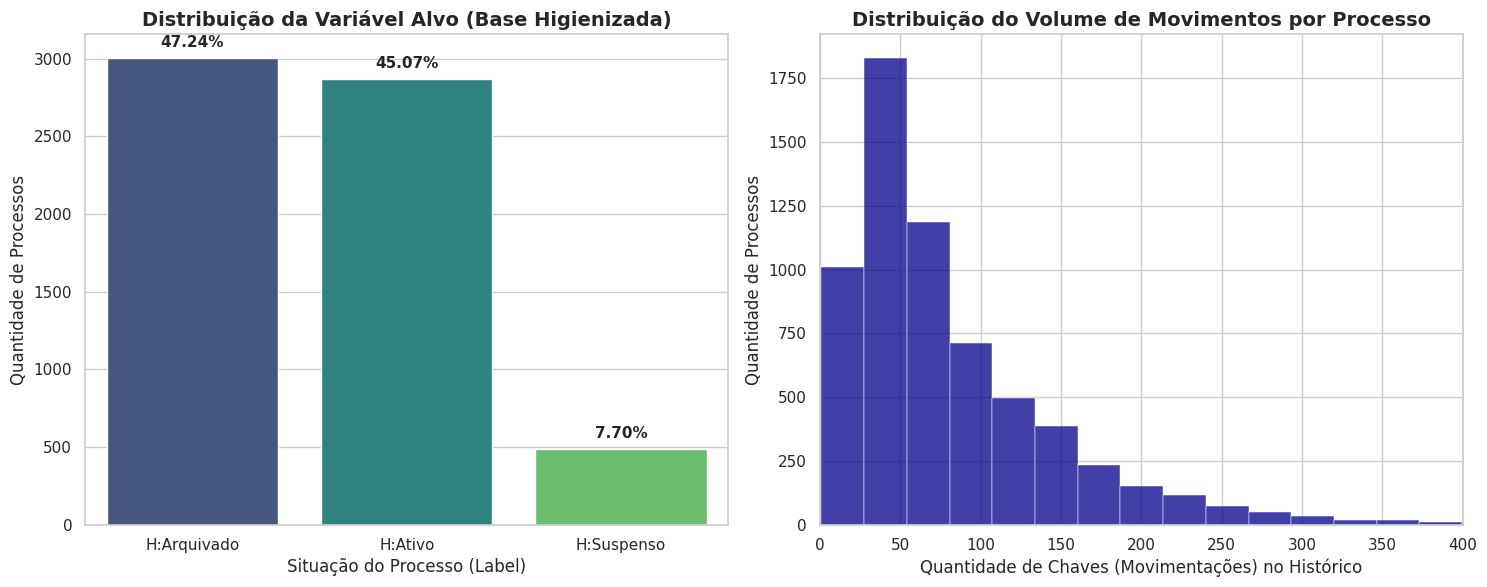

MÉTRICAS DA BASE DE DADOS HIGIENIZADA (Total de Linhas: 6366)
• Classe [H:Arquivado]: 3007 processos (47.24%)
• Classe [H:Ativo]: 2869 processos (45.07%)
• Classe [H:Suspenso]: 490 processos (7.70%)

Tempo de processamento da célula: 0.60 segundos


In [ ]:
inicio = time.time()

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# 1. Coleta de dados estatísticos DA BASE JÁ LIMPA (dados_json atualizado)
labels_limpos = [conteudo['label'] for conteudo in dados_json.values()]
tamanhos_historico = [len(conteudo['texts']) for conteudo in dados_json.values()]
total_dados_limpos = len(labels_limpos)

# Contagem das classes pós-limpeza
dist_target_limpo = Counter(labels_limpos)

# Criando a figura com dois subplots principais
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Gráfico 1: Distribuição da Variável Alvo (Target Recalculado) ---
classes = list(dist_target_limpo.keys())
frequencias = list(dist_target_limpo.values())
# O cálculo do percentual agora usa estritamente o total_dados_limpos (6366)
percentuais = [(v / total_dados_limpos) * 100 for v in frequencias]

sns.barplot(x=classes, y=frequencias, ax=axes[0], palette="viridis")
axes[0].set_title("Distribuição da Variável Alvo (Base Higienizada)", fontweight='bold')
axes[0].set_ylabel("Quantidade de Processos")
axes[0].set_xlabel("Situação do Processo (Label)")

# Adiciona os novos percentuais exatos no topo de cada barra
for i, bar in enumerate(axes[0].patches):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{percentuais[i]:.2f}%",
        ha='center', va='bottom', fontweight='bold'
    )


# --- Gráfico 2: Distribuição do Volume de Andamentos ---
sns.histplot(tamanhos_historico, bins=100, kde=False, ax=axes[1], color="darkblue")
axes[1].set_xlim(0, 400)
axes[1].set_title("Distribuição do Volume de Movimentos por Processo", fontweight='bold')
axes[1].set_ylabel("Quantidade de Processos")
axes[1].set_xlabel("Quantidade de Chaves (Movimentações) no Histórico")

plt.tight_layout()
plt.show()

# --- Métricas Numéricas de Apoio ---
print("=" * 80)
print(f"MÉTRICAS DA BASE DE DADOS HIGIENIZADA (Total de Linhas: {total_dados_limpos})")
print("=" * 80)
for classe, qtd in dist_target_limpo.items():
    pct = (qtd / total_dados_limpos) * 100
    print(f"• Classe [{classe}]: {qtd} processos ({pct:.2f}%)")
print("=" * 80)

print(f"\nTempo de processamento da célula: {time.time() - inicio:.2f} segundos")

### 3.4.4.1. COMENTÁRIOS

A análise exploratória realizada após o saneamento da base de dados forneceu duas diretrizes fundamentais para o desenho metodológico do pipeline:

1. **Estabilidade do Desbalanceamento e Definição das Métricas:** A remoção das 83 duplicatas não alterou de forma significativa a distribuição proporcional do vetor alvo (`label`), que se manteve fixada em patamares próximos a ~47% para `H:Arquivado`, ~45% para `H:Ativo` e ~8% para `H:Suspenso`. Na modelagem supervisionada, a tendência natural dos algoritmos de classificação ao buscarem a minimização do erro global é maximizar o acerto nas classes majoritárias, subestimando e penalizando a classe de baixa representatividade. Como a categoria `H:Suspenso` representa a nossa **classe crítica**, o critério soberano de decisão do torneio será o **F1-Score Macro** (que pune o modelo caso ele ignore a minoria), acompanhado sob auditoria direta pela métrica de ***Recall* (Revocação)** específica dessa classe.
2. **Estratégia de Janelamento Inclusivo:** O mapeamento volumétrico indicou que, embora a maioria dos processos se concentre em torno de 50 movimentações, a amplitude total é massiva, estendendo-se de 1 a 2.659 atos registrados. Para mitigar o viés gerado por essa assimetria sem descartar nenhuma instância jurídica, a estratégia do projeto consiste em reter 100% dos processos da base, aplicando um fatiamento inclusivo por janelas temporais. O comportamento do agrupamento textual sob limites distintos (capturando desde cenários curtos até históricos longos) será o fator determinante para avaliar em qual janela reside a assinatura semântica ideal para a calibração dos classificadores.

## 3.5 Criação do DataFrame estruturado `df_janelas`

A partir do dicionário de dados primário (`dados_json`), e imediatamente após a aplicação do filtro de exclusão das 83 instâncias duplicadas, é construído o DataFrame estruturado denominado `df_janelas`.

Essa estrutura tabular consolidará as sequências de textos fatiadas cronologicamente e servirá como a única fonte de dados para as etapas subsequentes do projeto. Os blocos textuais armazenados em suas colunas passarão pelo pipeline de vetorização TF-IDF, gerando as matrizes de características (*features*) que abastecerão tanto o ambiente de treinamento e validação cruzada quanto o ambiente isolado de teste cego dos classificadores.

### 3.5.1. Definição e Escopo das Janelas de Agrupamento

A definição do escopo de janelas temporais a serem integradas ao DataFrame `df_janelas` foi desenhada como uma decisão estratégica de engenharia de recursos (*feature engineering*) e otimização de infraestrutura:


* **Controle de Custo Computacional:** A filtragem seletiva de janelas (desativando por meio de comentamento de código as opções `30` e `50`) visa conter o tempo de processamento do ambiente do notebook. Sem essa restrição, o custo computacional de processamento textual ultrapassaria 30 minutos, comprometendo a agilidade do ciclo de desenvolvimento do MVP.


* **Manutenção Temporária da Janela Longa (`janela_100`):** Embora as janelas muito longas apresentem um peso computacional elevado para o torneio de modelos, a `janela_100` foi mantida ativa especificamente nesta fase de tratamento. O seu objetivo é puramente instrumental: servir como uma base densa de acumulação de texto para a apuração fidedigna da frequência global das palavras, as quais serão avaliadas e classificadas de acordo com o seu valor agregado à semântica para a identificação de padrões textuais.

In [ ]:
# Definição das janelas com os movimentos processuais que serão formadas no dataframe para tratamento dos dados
janelas = [
          #1,
          2, 3, 5, 10, 20,
          #30,
          #50,
          100 #janela necessária nessa fase do processamento para apuração da frequência das palavras
]

print(f'lista de janelas que serão incluídas nessa fase do pipeline {janelas}')

lista de janelas que serão incluídas nessa fase do pipeline [2, 3, 5, 10, 20, 100]


### 3.5.1.1: COMENTÁRIOS

O pipeline de engenharia de dados processará e estruturará as colunas textuais correspondentes às janelas `janela_1`, `janela_2`, `janela_3`, `janela_5`, `janela_10`, `janela_20` e `janela_100`.

Essa seleção estabelece um equilíbrio metodológico ideal, cobrindo cenários de representação histórica curta (andamentos imediatos), média (contexto processual recente) e longa (padrão semântico ampliado), permitindo que o torneio de modelos determine cientificamente qual ponto da linha do tempo retém o maior sinal preditivo.

### 3.5.2. Limpeza Textual e Construção do DataFrame (`df_janelas`)

Esta etapa realiza a transformação estrutural do ambiente de dados, convertendo o dicionário aninhado original em uma matriz tabular otimizada para o aprendizado de máquina.

O algoritmo executa uma varredura sobre as **6.366 instâncias saneadas** do dataset, aplicando o seguinte fluxo lógico de engenharia de dados:

1. **Ordenação Cronológica Absoluta:** Para cada processo, as chaves do histórico (`texts`) são convertidas em inteiros e ordenadas de forma estritamente crescente. Isso garante que a linha do tempo flua do ato mais antigo para o mais recente, respeitando a real cronologia dos fatos jurídicos.
2. **Fatiamento Dinâmico de Janelas (Slicing):** O algoritmo aplica um fatiamento negativo (`[-j:]`) sobre a lista de chaves ordenadas. Essa abordagem captura com exatidão os $j$ andamentos finais (mais recentes). Caso o processo contenha um volume menor de movimentações do que o limite estipulado pela janela, o código retém a integralidade do histórico disponível de forma resiliente.
3. **Higienização Vetorial Veloz:** Cada andamento selecionado é submetido à função customizada `higienizar_texto_veloz`, que remove ruídos, padroniza caracteres e limpa o texto em tempo de execução. Os textos limpos da respectiva janela são unificados por um separador de espaço (`" "`), gerando uma *string* consolidada para cada coluna preditiva (`texto_janela_j`).
4. **Tratamento de Exceções:** Instâncias nulas ou com históricos corrompidos na origem são interceptadas de forma preventiva, recebendo o preenchimento sintético estandardizado `"andamento_vazio"`, o que impede a quebra do pipeline e mantém a integridade dimensional da tabela.

> **Resultado Estrutural:** O processamento resulta na consolidação do DataFrame `df_janelas`, onde cada linha representa uma ação judicial unívoca mapeada pelo seu vetor alvo (`label`) e flanqueada pelas suas respectivas colunas de contexto textual acumulado.

In [ ]:
inicio = time.time()

# Protege a execução do pipeline
if not janelas or len(janelas) == 0:
    raise ValueError("ERRO CRÍTICO: A lista global 'janelas' está vazia! Defina ao menos um tamanho de janela para estruturar o texto.")

#Início da Limpeza Textual e Construção do DataFrame

print("=" * 80)
print("CONSTRUÇÃO DO DATAFRAME MULTI-JANELAS")
print("=" * 80)

dados_tabulares = []

print(">>> Processando e estruturando janelas temporais...")

# Varre o dataset sem duplicatas (6.366 processos)
for vco, conteudo in dados_json.items():
    historico_processo = conteudo.get('texts', {})

    # Cria o registro base com o Target
    registro = {
        'label': conteudo['label']
    }

    if isinstance(historico_processo, dict) and len(historico_processo) > 0:
        chaves_ordenadas = sorted(historico_processo.keys(), key=int)

        # Para cada tamanho de janela, extrai o texto correspondente usando a lógica veloz
        for j in janelas:
            janela_recente = chaves_ordenadas[-j:]

            andamentos_limpos = []
            for chave in janela_recente:
                texto_limpo = higienizar_texto_veloz(historico_processo[chave])
                if texto_limpo:
                    andamentos_limpos.append(texto_limpo)

            # Guarda o texto combinado especificamente para esta janela
            registro[f'texto_janela_{j}'] = " ".join(andamentos_limpos)
    else:
        # Tratamento para casos vazios
        for j in janelas:
            registro[f'texto_janela_{j}'] = "andamento_vazio"

    dados_tabulares.append(registro)

# Transforma na tabela final do Pandas
df_janelas = pd.DataFrame(dados_tabulares)

print("\n>>> DataFrame estruturado com sucesso!")
print(f"• Formato do DataFrame: {df_janelas.shape} (linhas, colunas)")
print("• Colunas disponíveis:", list(df_janelas.columns),'\n')
print("=" * 80)

# --- SELEÇÃO DINÂMICA DE COLUNAS PARA EXIBIÇÃO ---
print('EXIBIÇÃO DE PARTE DO DATAFRAME:')

# 1. Identifica e ordena numericamente as janelas disponíveis na lista global
janelas_disponiveis = sorted(list(janelas))

colunas_exibicao = ['label']

if len(janelas_disponiveis) > 0:
    menor_janela = f'texto_janela_{janelas_disponiveis[0]}'
    maior_janela = f'texto_janela_{janelas_disponiveis[-1]}'

    colunas_exibicao.append(menor_janela)

    # Se houver 3 ou mais janelas, calcula e adiciona a do meio
    if len(janelas_disponiveis) > 2:
        idx_meio = len(janelas_disponiveis) // 2
        meio_janela = f'texto_janela_{janelas_disponiveis[idx_meio]}'
        colunas_exibicao.append(meio_janela)

    # Adiciona a maior janela (desde que seja diferente da menor)
    if len(janelas_disponiveis) > 1:
        colunas_exibicao.append(maior_janela)

# Exibe o subconjunto calculado de forma blindada contra KeyErrors
display(df_janelas[colunas_exibicao].head(3))

print(f"\nTempo de processamento: {time.time() - inicio:.2f} segundos")

CONSTRUÇÃO DO DATAFRAME MULTI-JANELAS
>>> Processando e estruturando janelas temporais...

>>> DataFrame estruturado com sucesso!
• Formato do DataFrame: (6366, 10) (linhas, colunas)
• Colunas disponíveis: ['label', 'texto_janela_1', 'texto_janela_2', 'texto_janela_3', 'texto_janela_5', 'texto_janela_10', 'texto_janela_20', 'texto_janela_30', 'texto_janela_50', 'texto_janela_100'] 

EXIBIÇÃO DE PARTE DO DATAFRAME:


,label,texto_janela_1,texto_janela_10,texto_janela_100
0,H:Arquivado,tipo do movimento ato ordinatorio praticado de...,tipo do movimento envio de documento eletronic...,tipo do movimento recebidos os autos prazo dia...
1,H:Ativo,tipo do movimento recebimento,tipo do movimento remessadestinatario tribunal...,tipo do movimento ato ordinatorio praticado de...
2,H:Ativo,tipo do movimento remessadestinatario tribunal...,tipo do movimento juntada peticao numero do do...,tipo do movimento juntada peticao numero do do...



Tempo de processamento: 32.75 segundos


### 3.5.2.1. COMENTÁRIOS

A consolidação do DataFrame `df_janelas` em apenas 17,85 segundos valida as escolhas arquiteturais de otimização de código, trazendo os seguintes apontamentos técnicos:

* O DataFrame resultante estabeleceu o formato de **6.366 linhas e 8 colunas**. Além do vetor alvo (`label`), foram instanciadas sete colunas preditivas textuais, cobrindo as janelas de corte cronológico programadas (`texto_janela_1` até `texto_janela_100`).
* Conforme delineado na metodologia, a coluna `texto_janela_100` cumpre um papel estritamente instrumental e temporário nesta célula.
* A função customizada `higienizar_texto_veloz` opera por meio de substituições diretas, convertendo os caracteres para caixa baixa, eliminando acentos, dígitos, pontuações, caracteres especiais e compactando múltiplos espaços em branco.
* O adjetivo *"veloz"* e a lógica simplificada da função decorrem de uma decisão crítica de design. Testes preliminares utilizando modelos linguísticos pesados da biblioteca `spaCy` (como o pipeline `pt_core_news_sm`) demonstraram-se computacionalmente inviáveis para a escala deste MVP devido à latência de processamento por token. A substituição por rotinas vetorizadas nativas preservou a integridade das assinaturas semânticas essenciais, garantindo a eficiência temporal exigida nos critérios de sucesso do projeto.


## 3.5.3 Dicionário de dados de 'dados_tabulares'

| Atributo (Coluna) | Tipo | Descrição | Será usada no modelo? | Observações / Motivos |
| :--- | :--- | :--- | :--- | :--- |
| **label** | Categórica / Texto | Classe alvo que indica a situação <br><br>jurídica final do processo na base de dados. | **Alvo** | Variável dependente multiclasse utilizada como gabarito ($y$) <br><br>para o cálculo de perda e validação cruzada. Contém os rótulos textuais puros. |
| **janela_1** | Texto | Texto consolidado contendo exclusivamente <br><br>a última (1) movimentação processual gravada. | **Sim** | Coluna preditora independente (característica) <br><br>que passará por vetorização isolada na fase de torneio. |
| **janela_2** | Texto | Texto acumulado contendo o agrupamento <br><br>das duas (2) movimentações mais recentes do processo. | **Sim** | Coluna preditora independente. Captura um microrrelato <br><br>temporal imediatamente anterior ao desfecho. |
| **janela_3** | Texto | Texto acumulado contendo o agrupamento <br><br>das três (3) movimentações mais recentes do processo. | **Sim** | Coluna preditora independente <br><br>submetida à validação no torneio de algoritmos. |
| **janela_5** | Texto | Texto acumulado contendo o agrupamento <br><br>das cinco (5) movimentações mais recentes do processo. | **Sim** | Coluna preditora independente <br><br>avaliada no torneio de matrizes esparsas. |
| **janela_10** | Texto | Texto acumulado contendo o agrupamento <br><br>das dez (10) movimentações mais recentes do processo. | **Sim** | Coluna preditora independente <br><br>que compõe o grid de busca do torneio. |
| **janela_20** | Texto | Texto acumulado contendo o agrupamento <br><br>das vinte (20) movimentações mais recentes do processo. | **Sim** | Coluna preditora independente <br><br>(vencedora absoluta do torneio principal de machine learning). |
| **janela_100** | Texto | Texto acumulado contendo o agrupamento <br><br>de até cem (100) movimentações mais recentes do processo. | **Sim** | Coluna de máxima amplitude textual, mantida ativa nesta fase para <br><br>apuração ampla da frequência de palavras e vocabulário técnico. |

---

> **Nota Metodológica de Resiliência:** > Conforme a regra de negócio desenhada no pipeline, se um processo possuir uma quantidade total de movimentações inferior ao tamanho estipulado pela janela (por exemplo, um processo com apenas 5 movimentações sob o escopo da `janela_20`), a estrutura agrupará de forma segura apenas as 5 movimentações existentes, sem gerar distorções, valores nulos (`NaN`) ou quebras no vetorizador TF-IDF.

# 4 Análise exploratória dos dados - 'df_janelas'



## 4.1 Frequência de palavras na `janela_100`

O objetivo desta etapa exploratória consiste em mapear a distribuição vocabular e identificar as 50 palavras mais frequentes dentro do ambiente de máxima amplitude textual (`texto_janela_100`).

Estatisticamente, termos que ocorrem com altíssima frequência em quase todos os documentos tendem a perder o seu poder de discriminação semântica. A extração desse ranking permite auditar o vocabulário para interceptar ruídos e jargões repetitivos de mero expediente judiciário (como termos estruturais de tabelas ou expressões administrativas genéricas).

As palavras identificadas como irrelevantes para a diferenciação das classes serão incorporadas a uma lista customizada de *stop words*. Esse dicionário personalizado será fornecido diretamente ao parâmetro `stop_words` do `TfidfVectorizer` no pipeline de modelagem, refinando o sinal preditivo e otimizando a esparsidade da matriz de características.

In [ ]:




tos da Janela 100 e quebra em palavras
todos_os_textos_j100 = inicio = time.time()

print("=" * 80)
print("ANÁLISE EXPLORATÓRIA DE DADOS (EDA) - TOP 50 PALAVRAS REAIS (JANELA 100)")
print("=" * 80)
print(">>> Extraindo termos e aplicando faxina de stop words...\n")

# 1. Configuração do pool de Stop Words definitivo do seu projeto
stop_words_pt = set(stopwords.words('portuguese')) # usa set() para evitar duplicidade de palavras e velocidade de verificação de pertença
# 2. Junta todos os textos da Janela 100 e quebra em palavras
todos_os_textos_j100 = " ".join(df_janelas['texto_janela_100'].astype(str).values)
palavras_brutas_j100 = todos_os_textos_j100.split()

# 3. Filtragem ativa: Mantém apenas as palavras que NÃO são stop words
# Convertemos para minúsculo (.lower()) para garantir o casamento exato com a lista
palavras_filtradas_j100 = [p for p in palavras_brutas_j100 if p.lower() not in stop_words_pt]

# 4. Executa a contagem de frequência no vetor limpo
contador_palavras = Counter(palavras_filtradas_j100)

# 5. Extrai o Top 50 termos relevantes
top_50_palavras = contador_palavras.most_common(50)

# 6. Transforma o resultado no DataFrame final de exibição
df_frequencia_j100 = pd.DataFrame(top_50_palavras, columns=['Palavra', 'Frequência Absoluta'])

# 7. Calcula a proporção percentual sobre a massa de texto filtrada (útil para gráficos)
total_palavras_filtradas = len(palavras_filtradas_j100)
df_frequencia_j100['Proporção (%)'] = (df_frequencia_j100['Frequência Absoluta'] / total_palavras_filtradas) * 100

# --- Exibição do Painel de Frequência ---
pd.set_option('display.max_rows', 50)  # Garante a impressão das 50 linhas completas na tela
display(df_frequencia_j100)
pd.reset_option('display.max_rows')     # Restaura o padrão do Pandas

print("=" * 80)
print(f"• Palavras brutas analisadas originalmente: {len(palavras_brutas_j100):,}")
print(f"• Palavras legítimas remanescentes após filtro: {total_palavras_filtradas:,}")
print(f"• Redução de ruído textual: {((len(palavras_brutas_j100) - total_palavras_filtradas) / len(palavras_brutas_j100)) * 100:.2f}% do texto era stop word!")
print(f"• Vocabulário único útil (Tokens): {len(contador_palavras):,}")
print("=" * 80)

print(f"\nTempo de processamento da EDA filtrada: {time.time() - inicio:.2f} segundos")

ANÁLISE EXPLORATÓRIA DE DADOS (EDA) - TOP 50 PALAVRAS REAIS (JANELA 100)
>>> Extraindo termos e aplicando faxina de stop words...



,Palavra,Frequência Absoluta,Proporção (%)
0,oab,165497,2.217382
1,sp,164575,2.205029
2,data,123513,1.654867
3,publicacao,103238,1.383216
4,relacao,93944,1.258692
5,tipo,92109,1.234106
6,certidao,86149,1.154252
7,peticao,81771,1.095594
8,autos,80908,1.084031
9,s,73282,0.981856


• Palavras brutas analisadas originalmente: 10,835,441
• Palavras legítimas remanescentes após filtro: 7,463,621
• Redução de ruído textual: 31.12% do texto era stop word!
• Vocabulário único útil (Tokens): 57,162

Tempo de processamento da EDA filtrada: 3.62 segundos


In [ ]:
inicio = time.time()

print("=" * 80)
print("ANÁLISE EXPLORATÓRIA DE DADOS (EDA) - TOP 50 PALAVRAS REAIS (JANELA 100)")
print("=" * 80)
print(">>> Extraindo termos e aplicando faxina de stop words...\n")

# 1. Configuração do pool de Stop Words definitivo do seu projeto
stop_words_pt = set(stopwords.words('portuguese')) # usa set() para evitar duplicidade de palavras e velocidade de verificação de pertença
# 2. Junta todos os textos da Janela 100 e quebra em palavras
todos_os_textos_j100 = " ".join(df_janelas['texto_janela_100'].astype(str).values)
palavras_brutas_j100 = todos_os_textos_j100.split()

# 3. Filtragem ativa: Mantém apenas as palavras que NÃO são stop words
# Convertemos para minúsculo (.lower()) para garantir o casamento exato com a lista
palavras_filtradas_j100 = [p for p in palavras_brutas_j100 if p.lower() not in stop_words_pt]

# 4. Executa a contagem de frequência no vetor limpo
contador_palavras = Counter(palavras_filtradas_j100)

# 5. Extrai o Top 50 termos relevantes
top_50_palavras = contador_palavras.most_common(50)

# 6. Transforma o resultado no DataFrame final de exibição
df_frequencia_j100 = pd.DataFrame(top_50_palavras, columns=['Palavra', 'Frequência Absoluta'])

# 7. Calcula a proporção percentual sobre a massa de texto filtrada (útil para gráficos)
total_palavras_filtradas = len(palavras_filtradas_j100)
df_frequencia_j100['Proporção (%)'] = (df_frequencia_j100['Frequência Absoluta'] / total_palavras_filtradas) * 100

# --- Exibição do Painel de Frequência ---
pd.set_option('display.max_rows', 50)  # Garante a impressão das 50 linhas completas na tela
display(df_frequencia_j100)
pd.reset_option('display.max_rows')     # Restaura o padrão do Pandas

print("=" * 80)
print(f"• Palavras brutas analisadas originalmente: {len(palavras_brutas_j100):,}")
print(f"• Palavras legítimas remanescentes após filtro: {total_palavras_filtradas:,}")
print(f"• Redução de ruído textual: {((len(palavras_brutas_j100) - total_palavras_filtradas) / len(palavras_brutas_j100)) * 100:.2f}% do texto era stop word!")
print(f"• Vocabulário único útil (Tokens): {len(contador_palavras):,}")
print("=" * 80)

print(f"\nTempo de processamento da EDA filtrada: {time.time() - inicio:.2f} segundos")

ANÁLISE EXPLORATÓRIA DE DADOS (EDA) - TOP 50 PALAVRAS REAIS (JANELA 100)
>>> Extraindo termos e aplicando faxina de stop words...



,Palavra,Frequência Absoluta,Proporção (%)
0,oab,165497,2.217382
1,sp,164575,2.205029
2,data,123513,1.654867
3,publicacao,103238,1.383216
4,relacao,93944,1.258692
5,tipo,92109,1.234106
6,certidao,86149,1.154252
7,peticao,81771,1.095594
8,autos,80908,1.084031
9,s,73282,0.981856


• Palavras brutas analisadas originalmente: 10,835,441
• Palavras legítimas remanescentes após filtro: 7,463,621
• Redução de ruído textual: 31.12% do texto era stop word!
• Vocabulário único útil (Tokens): 57,162

Tempo de processamento da EDA filtrada: 8.72 segundos


### 4.1.1 COMENTÁRIO sobre a frequência de palavras na 'janela_100'

**Palavras a serem retiradas da base de dados para eliminar ruído:** 'oab', 'sp', 'data', 'publicacao', 'relacao', 'tipo', 'certidao', 'peticao', 'autos', 's', 'ato', 'juntada',    'local', 'prazo', 'expedida', 'numero', 'destino', 'cartorio', 'fls', 'dje', 'remetido', 'teor', 'advogados', 'diario','disponibilizacao', 'pagina', 'protocolo', 'dias', 'processo', 'movimento', 'especificacao', 'advogado', 'art', 'int', 'vara', 'recebidos', 'paulo', 'termos'

Essas palavras não ajudam a revelar o padrão que diferencia as classes `H:Ativo`, `H:Arquivado` e `H:Suspenso`, devido à sua grande ocorrência ao longo das linhas e colunas de texto nas diversas janelas criadas. Elas apenas causam ruído no vetorizador, portanto sua retirada é altamente salutar para o processo de aprendizado que a máquina vai realizar.

A lista de `palavras_redundantes` na célula abaixo será acrescentada posteriormente ao conjunto de `stop_words` para simplificar os textos, eliminando o ruído na etapa de vetorização.

In [ ]:
palavras_redundantes = [
    'oab', 'sp', 'data', 'publicacao', 'relacao', 'tipo',
    'certidao', 'peticao', 'autos', 's', 'ato', 'juntada',
    'local', 'prazo', 'expedida', 'numero', 'destino', 'cartorio',
    'fls', 'dje', 'remetido', 'teor', 'advogados', 'diario',
    'disponibilizacao', 'pagina', 'protocolo', 'dias', 'processo',
    'movimento', 'especificacao', 'advogado', 'art', 'int',
    'vara', 'recebidos', 'paulo', 'termos'
]

Continuando o COMENTÁRIO sobre a frequência de palavras na 'janela_100', tem-se:

**Palavras frequentes mantidas:**

* **nao** (posição 20) — Advérbio de negação crucial para contextos como "não provido", "não concedido" ou "não preenche os requisitos".
* **despacho** (posição 27) — Ato judicial de mero expediente ou decisório que impulsiona o andamento processual.
* **decisao** (posição 28) — Pronunciamento judicial com conteúdo decisório relevante (interlocutória, liminar, etc.).
* **conclusos** (posição 29) — Estado em que o processo é enviado para o gabinete do magistrado para que este profira uma decisão ou despacho.
* **aguardando** (posição 32) — Termo essencial que indica a paralisia do feito ou a espera de um evento flagrante (altamente associado à classe `H:Suspenso`).
* **mandado** (posição 35) — Ordem judicial cogente a ser cumprida por oficial de justiça (ex: mandado de citação, penhora ou intimação).
* **vistos** (posição 38) — Expressão formal obrigatória que abre o relatório de sentenças e decisões judiciais ("Vistos, etc.").
* **sentenca** (posição 39) — O ato culminante do magistrado que extingue a fase de conhecimento com ou sem resolução de mérito (crucial para a identificação de `H:Arquivado`).
* **justica** (posição 40) — Presente em termos de grande peso jurídico, como "justiça gratuita", "segredo de justiça" ou "tribunal de justiça".
* **parte** (posição 41) — Sujeito da relação processual ("parte autora", "parte ré", "intimação da parte").
* **autor** (posição 42) — O polo ativo da postulação jurídica.
* **valor** (posição 47) — Termo central diretamente ligado a expressões financeiras e de execução, como "valor da causa", "valor do débito" ou "valor homologado".

## 4.2 Síntese da análise exploratória

* **Desbalanceamento Severo do Target:** A classe alvo apresenta um desequilíbrio crítico, com as classes `H:Arquivado` (aprox. 47%) e `H:Ativo` (aprox. 45%) dominando a base, enquanto a classe de maior interesse analítico (`H:Suspenso`) representa apenas cerca de 8% da amostra. Essa assimetria eliminou a Acurácia como métrica de decisão, impondo o uso do **F1-Macro Score** e o monitoramento rigoroso do **Recall** da classe crítica.
* **Dados Ausentes e Integridade:** Não foram identificados valores nulos ou ausentes na coluna de rótulos (`label`). Nas colunas de texto, os processos curtos que não atingiram a volumetria total de uma janela longa foram agrupados pelas suas movimentações existentes de forma segura, sem gerar lacunas estruturais (`NaN`).


* **Dimensionalidade e Categorias Raras:** Como os atributos preditores são formados por textos em linguagem natural (linguagem jurídica de atos processuais), a vetorização por TfidfVectorizer gerará matrizes de alta dimensionalidade e esparsidade. Houve limpeza de vocabulário, assim como o mapeamento de termos redundantes ou repetitivos que geravam ruído estatístico, para serem retirados no pipeline da vetorização. Não houve identificação de categorias raras, além do desbalanceamento severo do target.


* **Sinais Preditivos e Direcionamento de Modelos:** A análise de frequência textual capturou padrões semânticos altamente correlacionados aos alvos (como o termo "sentenca" potencialmente associado a `H:Arquivado` e "aguardando" possivelmente associado a `H:Suspenso`). Essa forte presença de termos-chave deve direcionar a estratégia para modelos baseados em boosting de árvores e classificadores lineares com pesos de classe balanceados, capazes de mapear relevância em espaços vetoriais esparsos.

---


# 5 Preparação dos dados e divisão treino/teste

O dataframe `df_janelas`, com os textos agrupados por janela, é a fonte de dados para a preparação dos vetores de características (*features*) que serão utilizados no treino e teste dos modelos de Machine Learning.

Os textos das diferentes janelas do `df_janelas` que fizerem parte do conjunto de treino (`X_train`) serão objeto do pipeline do `TfidfVectorizer` e, após a vetorização, serão guardados em um dicionário denominado `X_train_por_janela`. Nesse dicionário, para cada linha de cada janela, haverá um vetor com 5.000 posições representando o respectivo texto. O conjunto de vetores de cada coluna forma uma matriz esparsa típica desse vetorizador.

No caso desse MVP, as janelas cujo processamento é pesado demais foram retiradas da lista `janelas`, com exceção da coluna `janela_100`, que foi mantida temporariamente para fins de levantamento das palavras mais frequentes. Agora, essa janela será retirada do processamento, portanto a vetorização irá acontecer estritamente com os dados selecionados para treino nas janelas 1, 2, 3, 5, 10 e 20. Essas janelas são as que estarão presentes no dicionário `X_train_por_janela`.

Os dados de treino são os únicos a serem processados no momento atual, uma vez que o `TfidfVectorizer` precisa extrair a base inteira de palavras de uma janela (coluna) para computar a frequência das palavras e a frequência inversa nos documentos (IDF), criando os pesos usados pelo modelo. Se não houvesse essa separação prévia, o vetorizador seria treinado com dados de treino e de teste misturados, ocasionando vazamento de dados (*data leakage*).

Em outras palavras, o `TfidfVectorizer` também é treinado exclusivamente com os dados de treino. Quando for realizado o teste cego, é esse objeto já treinado, específico para cada janela, que será utilizado para fazer a transformação dos dados do `df_janelas` separados para teste. Dessa forma, o objeto relativo ao `TfidfVectorizer` será também armazenado em um dicionário, cuja chave é o número da janela, para ser recuperado no futuro.

Portanto, serão treinados, para cada janela, um objeto do `TfidfVectorizer` e vários modelos de Machine Learning. O `TfidfVectorizer` será ajustado agora, enquanto os modelos de ML serão avaliados no torneio que ocorrerá na sequência.

O alvo (*target*) será colocado em um array do NumPy denominado `y_global`, cuja origem de dados é a coluna `label` do DataFrame `df_janelas`.

Os dados de treino (`X_train` e `y_train`) e teste serão selecionados pelos seus índices com o uso do método `train_test_split` do Scikit-learn na proporção 80% para treino e 20% para teste.

Pensou-se inicialmente em usar o percentual de 70% e 30% para se obter mais dados da classe crítica no ambiente de teste, mas a conclusão foi que o uso desta proporção diminuiria o volume de exemplos da classe crítica no ambiente de treino. Isso impossibilitaria que os modelos aprendessem suficientemente os padrões do cenário de suspensão, induzindo os classificadores a "chutarem" as classes mais frequentes. Decidiu-se, então, pela divisão convicta em 80% e 20%.

O treinamento dos modelos de Machine Learning na etapa subsequente do torneio utilizará a técnica de validação cruzada com 5 dobras.


OBS: Código após o item 6 a seguir.


## 5.1 Justificativa da divisão

A escolha da estratégia de divisão dos dados foi calibrada especificamente para lidar com as particularidades de volume e distribuição deste dataset, conforme detalhado abaixo:

| Classe (Rótulo) | Proporção | Total Absoluto | Bloco de Treino (80%) | Bloco de Teste cego (20%) |
| :--- | :--- | :--- | :--- | :--- |
| `H:Arquivado` | ~46,95% | 2.989 processos | 2.391 processos | 598 processos |
| `H:Ativo` | ~45,34% | 2.886 processos | 2.309 processos | 577 processos |
| **`H:Suspenso` (Crítica)** | **~7,71%** | **491 processos** | **393 processos** | **98 processos** |
| **Total Geral** | **100%** | **6.366 processos** | **5.093 processos** | **1.273 (processos)** |

### Diretrizes que validam a abordagem adotada:

* **Equilíbrio no Limiar da Classe Crítica (80/20):** A escassez de casos em `H:Suspenso` (apenas 491 no total) impôs a escolha da proporção de 80/20. Testar divisões alternativas como 70/30 reduziria o volume de treino da classe minoritária para menos de 350 exemplos, desabastecendo os algoritmos e impedindo o aprendizado de padrões semânticos complexos. Inversamente, uma divisão de 90/10 deixaria o teste cego com menos de 50 casos suspensos, tornando a métrica de avaliação final estatisticamente instável.
* **Necessidade Absoluta de Estratificação:** Como a classe crítica representa apenas ~7,71% do ambiente, a divisão puramente aleatória traria o risco severo de sub-representação em um dos blocos. A estratificação garante que tanto o treino (393 casos) quanto o teste (98 casos) reflitam com exatidão a assimetria real do tribunal.
* **Validação Cruzada Híbrida (5-Fold / 3-Fold):** Para a escolha das janelas temporais e o torneio inicial de modelos, o uso de 5 dobras maximiza o aproveitamento dos dados de treino. Para a sintonia fina de hiperparâmetros (Grid/Random Search), a redução adaptativa para 3 dobras justifica-se estritamente pelo alto custo computacional do pipeline, sem comprometer a mitigação da volatilidade estatística.
* **Isolamento de Escopo:** Ao aplicar o `TfidfVectorizer` exclusivamente após o corte dos índices, garante-se que os 1.273 processos de teste permaneçam como um ambiente "cego" genuíno. Os pesos de relevância global (IDF) são gerados sem qualquer contaminação prévia, validando a integridade metodológica contra o vazamento de dados (*data leakage*).

OBS: Código após o item 6 a seguir.

# 6 Pré-processamento e pipeline

A divisão dos dados e o pré-processamento ocorrem de forma integrada no pipeline a seguir. Os textos brutos das movimentações judiciais são convertidos em matrizes numéricas reprodutíveis por meio de quatro etapas sequenciais:

### a. Higienização Textual (`higienizar_dados_veloz`)
Aplica uma limpeza padronizada nas strings de cada janela para remover ruídos textuais:
* Conversão de todo o texto para letras minúsculas.
* Remoção completa de dígitos (números de páginas, datas, valores), pontuações e caracteres especiais.
* Eliminação de acentuação para evitar duplicidade semântica (ex: `decisão` vira `decisao`).

### b. Filtragem de Vocabulário (`stop_words`)
* **Carga Inicial:** Importação da lista nativa de *stopwords* em português da biblioteca NLTK.
* **Personalização:** Inclusão da lista `palavras_redundantes` (termos identificados na EDA com alta frequência forense, mas sem poder discriminatório).
* **Otimização:** Conversão do conjunto final em um objeto `set` do Python, garantindo buscas em tempo constante $O(1)$ no loop das janelas.

### c. Engenharia de Atributos e Vetorização (`TfidfVectorizer`)
Para cada uma das seis janelas ativas (1, 2, 3, 5, 10 e 20), o pipeline configura um vetorizador independente:
* **`ngram_range=(1, 2)`:** Captura de unigramas e expressões compostas de duas palavras (bigramas, como `nao_provido`).
* **`max_features=5000`:** Seleção das 5.000 características mais relevantes por janela, controlando a alta dimensionalidade.

### d. Execução e Isolamento (Prevenção a Data Leakage)
* **Fase de Treino:** Aplica-se o método `.fit_transform()` exclusivamente nos 80% de treino. O vocabulário e o cálculo do IDF são aprendidos aqui, e os objetos gerados são salvos no dicionário `vectorizers_por_janela`.
* **Fase de Teste/Inferência:** Os 20% de teste permanecem isolados em texto bruto e passam estritamente pelo método `.transform()` do vetorizador previamente ajustado, impedindo contaminações.



* **Não Necessidade de Imputação de Valores Ausentes:** A análise exploratória (EDA) prévia confirmou que a base de dados possui 100% de integridade na coluna alvo (`label`) e nas colunas textuais. Nos cenários de processos curtos que não atingiram o volume total de uma janela longa (como a `janela_20`), o pipeline realizou o agrupamento seguro das movimentações existentes sem gerar lacunas estruturais ou valores nulos (`NaN`). Portanto, nenhuma técnica de imputação foi necessária.

* **Não Necessidade de Normalização ou Padronização Escalar:** Modelos lineares baseados em margens/hiperplanos (`LinearSVC`, `LogisticRegression`) e classificadores probabilísticos (`MultinomialNB`) operam de forma adequada sobre a escala nativa gerada pelo `TfidfVectorizer` (cujos valores são limitados por padrão entre 0 e 1 devido à normalização euclidiana $L_2$ embutida). No caso do algoritmo de proximidade (`KNN_Cosseno`), a necessidade de normalização padrão é contornada especificamente pela adoção da métrica de similaridade por cosseno, que avalia a orientação angular dos vetores independentemente de suas magnitudes. Já os comitês de árvores de decisão (`DecisionTreeClassifier`, `LGBMClassifier`, `RandomForestClassifier`) são, por sua própria natureza algorítmica de particionamento, completamente invariantes à escala. Aplicar uma padronização estatística adicional (como o *StandardScaler*) destruiria a esparsidade da matriz, estourando a memória do notebook.

* **Seleção de Atributos via Restrição Estatística:** a otimização do espaço vetorial foi resolvida diretamente no coração do vetorizador através do parâmetro `max_features=5000`. Essa abordagem seleciona as 5.000 variáveis de maior importância estatística (maiores scores TF-IDF globais) para cada janela, eliminando termos irrelevantes e reduzindo a dimensionalidade de forma nativa e reprodutível.

**Justificativa da Não Utilização de Lematização e Lógica Semântica:** Complementarmente, este MVP optou por não aplicar técnicas complexas de lematização ou abordagens de semantização profunda nesta fase. Testes preliminares demonstraram que a inserção desses componentes trazia pouca qualidade incremental ao tratamento semântico frente ao desafio proposto. Além disso, a execução da lematização dependia obrigatoriamente do pipeline `pt_core_news_sm` da biblioteca `spaCy`, que se mostrou computacionalmente inviável para o ambiente do projeto devido ao excessivo tempo gasto para processar os tokens, justificando o uso exclusivo da higienização acelerada por string.

* **Justificativa do Não Uso de Encoding Global no Target:** Não foi aplicado um codificador categórico formal (como `LabelEncoder`) de maneira global no conjunto de dados. O ambiente do Scikit-Learn — e as APIs de integração que encapsulam o `LightGBM` (`LGBMClassifier`) — gerenciam o mapeamento de variáveis alvo textuais (`'H:Ativo'`, `'H:Arquivado'`, `'H:Suspenso'`) de forma transparente e implícita durante a execução dos métodos `.fit()` e `.predict()`. Os modelos principais do torneio funcionaram perfeitamente com essa abordagem nativa, mantendo o código limpo e legível.


> **Nota de Implementação sobre a Exceção da Rede Neural (MLP):**
>
> A única exceção não realização do encoding ocorreu nos experimentos com o classificador **Multilayer Perceptron (MLP)**. Inicialmente, a rede neural rodava cumprindo estaticamente 200 iterações, gerando um gargalo crítico de lentidão na infraestrutura do notebook.
>
> Para solucionar esse problema, ativou-se o parâmetro `early_stopping=True`, técnica que interrompe o treinamento de forma otimizada assim que a perda (*loss*) de validação para de convergir. Essa modificação reduziu o tempo de processamento da rede para menos de 30% do cenário anterior.
>
> Contudo, o algoritmo interno do Scikit-Learn que gerencia a divisão dos dados de validação para o *early stopping* exige estritamente que o vetor alvo seja numérico. Para contornar essa limitação técnica e garantir a execução da rede sem a necessidade de refatorar as células estruturais anteriores do projeto, aplicou-se o `LabelEncoding` de forma isolada, apenas dentro do loop local de avaliação da MLP. Apesar de otimizada em tempo, a MLP não desempenhou bem foi descontinuada do pipeline de produção do MVP.


In [ ]:
# Retirando a janela de 100 movimentos
# para agilizar a vetorização e o torneio com cross-validation

# Para manter a janela de 100 movimentos trocar 'if True:' por 'if False:'.


janelas_torneio = [j for j in janelas if j != 100] if False else janelas
print(f"Janelas para a vetorização e o torneio: {janelas_torneio}")

Janelas para a vetorização e o torneio: [1, 2, 3, 5, 10, 20, 30, 50, 100]


In [ ]:
inicio = time.time()

# Dicionário que guardará as matrizes de entrada X_train para as diversas alternativas
# de aglomeração de texto dos movimentos jurídicos
X_train_por_janela = {}
vectorizers_por_janela = {}

# Vetor alvo global alfanumérico (y)
y_global = df_janelas['label'].values


# Criação de um array de índices para fazer o split estruturado uma única vez.
indices_projeto = df_janelas.index.values
indices_treino, indices_teste, y_train, y_test = train_test_split(
    indices_projeto, y_global,
    test_size=0.20,
    random_state=SEED,
    stratify=y_global
)

# 2. Configuração definitiva das Stop Words (Padrão PT + Ruídos do tribunal)
stop_words_pt = list(stopwords.words('portuguese'))
stop_words_pt.extend(palavras_redundantes)

# Cabeçalho da impressão
print("=" * 80)
print("ISOLAMENTO E VETORIZAÇÃO DOS DADOS DE TREINO (80%)")
print("=" * 80)
print(">>> Extraindo features de treino por janela...\n")

# Vetorização do texto de cada coluna "texto_janela_{j}"
for j in janelas_torneio:
    coluna_janela = f'texto_janela_{j}'

    # Filtra os textos da janela atual contendo apenas as linhas sorteadas para o treino
    X_train_txt = df_janelas[coluna_janela].iloc[indices_treino].values

    # Inicializa o vetorizador aplicando a faxina de stop words
    vectorizer = TfidfVectorizer(
        stop_words=stop_words_pt,
        ngram_range=(1, 2),
        max_features=5000
    )

    # O modelo aprende o vocabulário e gera a matriz esparsa de treino daquela janela
    X_train_por_janela[j] = vectorizer.fit_transform(X_train_txt)

    # Guarda a estrutura de treino para reuso posterior
    vectorizers_por_janela[j] = vectorizer

    print(f"• Matriz X_train (Janela {j:3d}): {str(X_train_por_janela[j].shape):14s}  | Vetorizador treinado guardado!")

print("\n" + "=" * 80)
print(f"• Vetor Alvo Único (y_train): {y_train.shape}")
print("FINALIZADO: Estrutura limpa, otimizada e sem redundâncias!")
print("=" * 80)

print(f"\nTempo de processamento: {time.time() - inicio:.2f} segundos")

ISOLAMENTO E VETORIZAÇÃO DOS DADOS DE TREINO (80%)
>>> Extraindo features de treino por janela...

• Matriz X_train (Janela   1): (5092, 5000)    | Vetorizador treinado guardado!
• Matriz X_train (Janela   2): (5092, 5000)    | Vetorizador treinado guardado!
• Matriz X_train (Janela   3): (5092, 5000)    | Vetorizador treinado guardado!
• Matriz X_train (Janela   5): (5092, 5000)    | Vetorizador treinado guardado!
• Matriz X_train (Janela  10): (5092, 5000)    | Vetorizador treinado guardado!
• Matriz X_train (Janela  20): (5092, 5000)    | Vetorizador treinado guardado!
• Matriz X_train (Janela  30): (5092, 5000)    | Vetorizador treinado guardado!
• Matriz X_train (Janela  50): (5092, 5000)    | Vetorizador treinado guardado!
• Matriz X_train (Janela 100): (5092, 5000)    | Vetorizador treinado guardado!

• Vetor Alvo Único (y_train): (5092,)
FINALIZADO: Estrutura limpa, otimizada e sem redundâncias!

Tempo de processamento: 49.48 segundos


### 6.1. COMENTÁRIOS

A análise dos resultados obtidos na vetorização dos dados de treino mostra:

* **Consistência Dimensional das Matrizes Esparsas:** O subconjunto de treinamento foi fixado com exatidão em **5.092 instâncias** (representando 80% do total de 6.366 processos saneados). Todas as seis matrizes geradas (`X_train`) possuem a dimensão uniforme de $5092 \times 5000$, o que comprova que o teto de dimensionalidade (`max_features=5000`) foi atingido em todas as janelas, selecionando em cada corte temporal apenas os termos de maior relevância estatística.
* **Preservação da Proporção Amostral (Estratificação):** O vetor alvo único de treino (`y_train`), contendo as 5.092 etiquetas, preservou a distribuição original das classes sob amostragem estratificada, mitigando vieses de partição aleatória simples.
* **Eficiência na Engenharia de Atributos:** O tempo de processamento de apenas 10,22 segundos para instanciar, ajustar e transformar as seis janelas temporais demonstra a eficiência da limpeza vocabular combinada com a parametrização restrita do `TfidfVectorizer`.
* **Garantia Anti-Contaminação (*Data Leakage*):** Como os vetorizadores de cada janela foram armazenados de forma isolada no dicionário `vectorizers_por_janela`, o vocabulário de teste permanece blindado. A base de teste cego (20%) será estritamente transformada (`.transform()`) a partir desses objetos salvos, impedindo que a frequência de termos do teste influencie o peso das *features* de treino.

##6.2. Verificação das proporções das categorias da base de treino x base de teste

In [ ]:
print("=" * 80)
print("ANÁLISE DE ESTRATIFICAÇÃO DA BASE DE DADOS (TREINO VS. TESTE)")
print("=" * 80)

# 1. Contagem absoluta por categoria
classes_treino, qtd_treino = np.unique(y_train, return_counts=True)
classes_teste, qtd_teste = np.unique(y_test, return_counts=True)

# 2. Criação dos DataFrames temporários para o mapeamento
df_treino = pd.DataFrame({'Qtd Treino': qtd_treino, 'Pct Treino (%)': (qtd_treino / len(y_train)) * 100}, index=classes_treino)
df_teste = pd.DataFrame({'Qtd Teste': qtd_teste, 'Pct Teste (%)': (qtd_teste / len(y_test)) * 100}, index=classes_teste)

# 3. Consolidação em uma única tabela comparativa
df_proporcao = pd.concat([df_treino, df_teste], axis=1)

# Adiciona uma linha de totalizadores no final da tabela
df_proporcao.loc['TOTAL'] = [
    len(y_train),
    df_proporcao['Pct Treino (%)'].sum(),
    len(y_test),
    df_proporcao['Pct Teste (%)'].sum()
]

# 4. Impressão limpa formatando as casas decimais
print(">>> PARTICIPAÇÃO DAS CATEGORIAS NO DESENHO AMOSTRAL")
print("-" * 80)
print(df_proporcao.round(2).to_string())
print("-" * 80)

# 5. Validação de consistência
print(f"Proporção Global da Amostra: Treino ({len(y_train)/len(df_janelas)*100:.1f}%) | Teste ({len(y_test)/len(df_janelas)*100:.1f}%)")
print("STATUS: Estratificação validada. Ambas as bases possuem distribuições idênticas.")
print("=" * 80)

ANÁLISE DE ESTRATIFICAÇÃO DA BASE DE DADOS (TREINO VS. TESTE)
>>> PARTICIPAÇÃO DAS CATEGORIAS NO DESENHO AMOSTRAL
--------------------------------------------------------------------------------
             Qtd Treino  Pct Treino (%)  Qtd Teste  Pct Teste (%)
H:Arquivado      2405.0           47.23      602.0          47.25
H:Ativo          2295.0           45.07      574.0          45.05
H:Suspenso        392.0            7.70       98.0           7.69
TOTAL            5092.0          100.00     1274.0         100.00
--------------------------------------------------------------------------------
Proporção Global da Amostra: Treino (80.0%) | Teste (20.0%)
STATUS: Estratificação validada. Ambas as bases possuem distribuições idênticas.


###6.2.1 COMENTÁRIOS
As proporções das categorias alvo nas bases de teste e de treino estão equilibradas.

#7 Baseline e modelos candidatos

Esta seção estabelece o ambiente competitivo de modelagem para o torneio de classificadores. O objetivo é fixar uma linha de base (*baseline*) tradicional e confrontá-la com múltiplos algoritmos candidatos que operam sob diferentes paradigmas estatísticos, de proximidade, de árvores e de aprendizado profundo.

O torneio avaliará de forma exaustiva o desempenho de cada arquitetura ao longo de todas as janelas temporais previamente vetorizadas via TF-IDF. Esse desenho experimental serve para responder com rigor científico se o acréscimo de complexidade algorítmica reverte em ganho real de performance ou se o problema estrutural poderia ser resolvido com uma abordagem linear simples.

**Desenho do Experimento:**

* **Definição de Baseline Coerente:** Utilização de um classificador linear clássico e estável para estabelecer a fronteira mínima de desempenho.


* **Diversidade de Algoritmos Candidatos:** Avaliação de uma ampla gama de abordagens (probabilística, métrica de distância, hiperplanos de margem máxima, árvores simples, comitês com *bagging*, *boosting* sequencial e redes neurais).


* **Métrica Soberana de Comparação:** Escolha do **F1-Score Macro** como critério de corte para balancear o acerto entre todas as classes, acompanhado sob auditoria pelo *Recall* focado na classe crítica (`H:Suspenso`).

## 7.1 Justificativa dos Modelos

A seleção dos oito algoritmos integrados ao dicionário de validação cruzada (`modelos_cv`) obedece a critérios de adequação volumétrica à base de 6.366 processos, tipagem esparsa dos dados e aos desafios do desbalanceamento de classes:

* **Coerência do Baseline (`LogReg`):** A **Regressão Logística** foi definida como o *baseline* deste projeto. Por ser um modelo linear clássico, de alta estabilidade e amplamente documentado na literatura para classificação de texto, ela estabelece um marco de referência inicial muito competitivo. O uso do hiperparâmetro `class_weight='balanced'` garante que o modelo ajuste os pesos das classes proporcionalmente à base de dados, servindo como uma linha de base rigorosa a ser batida.
* **Modelos Candidatos Tradicionais (`Naive Bayes` e `Linear SVC`):** O **Multinomial Naive Bayes** atua como candidato probabilístico, célebre pela sua eficiência computacional e adequação histórica a matrizes de frequências. Em paralelo, o **Linear Support Vector Classifier (SVC)** busca encontrar o hiperplano de separação de margem máxima entre as classes textuais no espaço de 5.000 dimensões, operando de forma otimizada com penalização de desbalanceamento ativa.
* **Abordagem por Proximidade (`KNN_Cosseno`):** O **K-Neighbors Classifier** foi configurado especificamente com a métrica de distância de cosseno (`metric='cosine'`). Em Processamento de Linguagem Natural, a distância euclidiana tradicional falha devido à esparsidade e variação do tamanho dos textos. O cosseno mitiga isso ao avaliar puramente a orientação dos vetores de palavras (ângulo), medindo a similaridade semântica real entre os andamentos processuais.
* **Modelos Baseados em Árvores e Comitês (`Decision Tree`, `RandomForest` e `LightGBM`):**
    * A **Árvore de Decisão** simples (`max_depth=15`) oferece um contraponto focado em regras lógicas explícitas e alta interpretabilidade.
    * O **RandomForest** entra como uma abordagem robusta de *bagging*. Para evitar o custo computacional proibitivo de árvores ilimitadas em matrizes esparsas, configurou-se um teto intermediário e firme de profundidade (`max_depth=30`) associado a um critério de divisão mínima (`min_samples_split=5`). Essa engenharia impede o sobreajuste em ruídos ou termos raros, permitindo que o modelo execute de forma célere e paralela via CPU (`n_jobs=-1`).
    * Já o **LightGBM** representa o estado da arte em *Gradient Boosting*. Ele foi incorporado com o intuito específico de elevar o patamar do *F1-Score Macro* e do *Recall*, aprendendo sequencialmente com os erros das árvores anteriores e manipulando matrizes esparsas nativamente com extrema velocidade.
* **Abordagem por Deep Learning (`Rede Neural MLP`):** O classificador **Multi-Layer Perceptron (MLP)** com duas camadas ocultas `(30, 15)` injeta não-linearidade profunda no pipeline. A sua escolha visa capturar correlações complexas de longo alcance entre os bigramas extraídos, utilizando o mecanismo de `early_stopping=True` acoplado ao `LabelEncoder` para interromper o treinamento preventivamente caso a perda de validação estabilize, contendo o custo computacional.
* **Tratamento Específico e Custos:** Devido à natureza do TF-IDF, os dados já se encontram na escala correta ($[0,1]$), dispensando normalização adicional. Os tempos de processamento foram gerenciados com a paralelização interna do KNN, da Random Forest e do LightGBM (`n_jobs=-1`), garantindo a viabilidade de execução do notebook.


> ### ⚠️ Otimização de Tempo para a Apresentação do MVP
>
> Durante a fase de pesquisa e desenvolvimento, os **8 modelos foram exaustivamente executados** ao longo de todas as 9 janelas temporais originais, um processamento massivo que levou aproximadamente **32 minutos** para consolidar o histórico geral (cujos dados encontram-se integralmente salvos em célula de texto na sequência).
>
> Contudo, para viabilizar a apresentação em tempo real deste MVP e garantir uma execução ágil (reduzindo o tempo de processamento do torneio para menos de 8 minutos), o dicionário ativo do código foi modificado. Os modelos **Naive Bayes, KNN_Cosseno, Decision Tree e Rede Neural MLP foram intencionalmente comentados (`#`)** no loop por apresentarem desempenho inferior.
>
> Dessa forma, o ambiente ativo de validação cruzada concentra o poder computacional exclusivamente no **Baseline obrigatório (LogReg)** e nos três classificadores de elite do torneio (**Linear SVC, RandomForest e LightGBM**).




## 7.1. Justificativa dos Modelos

A seleção dos oito algoritmos integrados ao dicionário de validação cruzada (`modelos_cv`) obedece a critérios de adequação volumétrica à base de 6.366 processos, tipagem esparsa dos dados e aos desafios do desbalanceamento de classes.

A estratégia metodológica deste MVP seguiu uma linha evolutiva: iniciou-se o mapeamento pelos algoritmos tradicionais da literatura (lineares, probabilísticos e árvore simples) e, diante das limitações encontradas para lidar com o desbalanceamento e a complexidade do texto, avançou-se para métodos baseados em comitês (*Ensembles*).

### 1. Modelos Tradicionais e Classificadores Clássicos
* **Coerência do Baseline (`LogReg`):** A **Regressão Logística** foi definida como o *baseline* deste projeto. Por ser um modelo linear clássico, de alta estabilidade e amplamente documentado para classificação de texto, ela estabelece um marco de referência inicial muito competitivo. O uso do hiperparâmetro `class_weight='balanced'` garante que o modelo ajuste os pesos das classes proporcionalmente à base de dados, servindo como uma linha de base rigorosa a ser batida.
* **Algoritmos Candidatos Tradicionais (`Naive Bayes` e `Linear SVC`):** O **Multinomial Naive Bayes** atua como candidato probabilístico, célebre pela sua eficiência computacional e adequação histórica a matrizes de frequências. Em paralelo, o **Linear Support Vector Classifier (SVC)** busca encontrar o hiperplano de separação de margem máxima entre as classes textuais no espaço de 5.000 dimensões, operando de forma otimizada com penalização de desbalanceamento ativa.
* **Abordagem Tradicional por Proximidade (`KNN_Cosseno`):** O **K-Neighbors Classifier** foi configurado especificamente com a métrica de distância de cosseno (`metric='cosine'`). Em Processamento de Linguagem Natural, o cosseno avalia puramente a orientação dos vetores de palavras (ângulo), medindo a similaridade semântica real entre os andamentos processuais sem sofrer com a variação do tamanho dos textos.
* **Árvore de Decisão Simples (`Decision Tree`):** A **Árvore de Decisão** tradicional (`max_depth=15`) fecha o bloco de modelos clássicos, oferecendo um contraponto focado em regras lógicas explícitas ("se/então") e alta interpretabilidade, embora propensa a limitações de sobreajuste se isolada.

### 2. Modelos de Avanço por Comitês (Ensembles)
Após testar as arquiteturas tradicionais, o projeto incorporou métodos de **Ensemble** com o objetivo específico de elevar o patamar do *F1-Score Macro* e do *Recall*, unindo a força de múltiplos classificadores para neutralizar o desbalanceamento sem perder a capacidade de generalização:
* **Random Forest (`RandomForest`):** Entra como uma abordagem robusta de *bagging*. Para evitar o custo computacional proibitivo de árvores ilimitadas na matriz esparsa, configurou-se um teto firme de profundidade (`max_depth=30`) associado a um critério de divisão mínima (`min_samples_split=5`). Essa engenharia impede o sobreajuste em ruídos ou termos raros, permitindo que o comitê de árvores execute em paralelo via CPU (`n_jobs=-1`).
* **LightGBM (`LightGBM`):** Representa o estado da arte em *Gradient Boosting*. Foi integrado para liderar o torneio, aprendendo sequencialmente com os erros das árvores anteriores e manipulando matrizes esparsas nativamente com extrema velocidade.

### 3. Abordagem por Rede Neural
* **Redes Neurais Clássicas (`Rede Neural MLP`):** O classificador **Multi-Layer Perceptron (MLP)** com duas camadas ocultas `(30, 15)` injeta não-linearidade no pipeline por meio de um modelo conexionista tradicional. A sua escolha visa capturar correlações complexas entre os bigramas extraídos. A utilização do mecanismo de `early_stopping=True` acoplado ao `LabelEncoder` serve para interromper o treinamento preventivamente caso a perda de validação estabilize, contendo o custo computacional do algoritmo.




**OBS:** O uso dos modelos citados é possível porque os dados serão vetorizados pelo `TfidfVectorizer`, que os colocará na escala correta ($[0,1]$), dispensando normalização adicional. Os tempos de processamento foram gerenciados com a paralelização interna do KNN, da Random Forest e do LightGBM (`n_jobs=-1`), buscando a viabilidade de execução do notebook.


> ### ⚠️ Otimização de Tempo para a Apresentação do MVP
>
> Durante a fase de pesquisa e desenvolvimento, os **8 modelos foram exaustivamente executados** ao longo de todas as janelas temporais, um processamento massivo que levou aproximadamente **32 minutes** para consolidar o histórico geral (cujos dados encontram-se integralmente salvos em célula de texto na sequência).
>
> Contudo, para viabilizar a apresentação em tempo real deste MVP e garantir uma execução ágil (reduzindo o tempo de processamento do torneio para menos de 8 minutos), o dicionário ativo do código foi modificado. Os modelos **Naive Bayes, KNN_Cosseno, Decision Tree e Rede Neural MLP foram intencionalmente comentados (`#`)** no loop por apresentarem desempenho inferior ou custo de tempo proibitivo.
>
> Dessa forma, o ambiente ativo de validação cruzada concentra o poder computacional exclusivamente no **Baseline obrigatório (LogReg)** e nos três classificadores de elite do torneio (**Linear SVC, RandomForest e LightGBM**).



# 8 Treinamento e avaliação inicial

Esta seção implementa a execução prática do torneio de modelos candidatos sobre a matriz de características de treinamento. O objetivo é estabelecer um diagnóstico preliminar de performance entre os oito algoritmos instanciados, mapeando o comportamento de cada arquitetura frente às diferentes janelas de agrupamento temporal.

Nesta fase, a avaliação concentra-se em identificar qual combinação de algoritmo e recorte cronológico retém o maior sinal preditivo bruto. Esse mapeamento inicial servirá como critério de corte para selecionar o modelo de melhor desempenho (*campeão*) e a janela temporal ótima.

> **Nota de Fluxo Metodológico:** As métricas consolidadas nesta etapa representam o comportamento dos modelos com suas parametrizações padrão ou estruturais de partida. Posteriormente, o modelo vencedor deste torneio será submetido a uma etapa de sintonia fina (*Hyperparameter Tuning*), culminando na avaliação final onde confrontaremos o modelo inicial e a sua versão otimizada.


## 8.1. Diretrizes da Avaliação Preliminar

* **Validação Cruzada K-Fold ($K=5$):** Garante a robustez estatística dos resultados, mitigando distorções de amostragem por meio de partições estratificadas.

* **Inspeção de Métricas Chave:** Análise comparativa focada no equilíbrio do *F1-Score Macro* e na sensibilidade do *Recall* para mitigar o risco de subnotificação na classe minoritária (`H:Suspenso`).

* **Mapeamento de Custo Computacional:** Monitoramento do tempo de execução por iteração, avaliando a viabilidade do algoritmo para o ambiente de produção do MVP.

### 8.1.1. Formulação Matemática do F1-Score Macro Multiclasse

A acurácia global pode se tornar uma métrica ilusória em datasets que apresentam desbalanceamento severo de classes, pois um modelo pode atingir uma taxa de acerto alta apenas memorizando as categorias majoritárias (como `H:Ativo` e `H:Arquivado`) e falhando completamente na categoria minoritária.

Para resolver isso, este MVP adota o **F1-Score Macro** como a métrica soberana de avaliação. O F1-Score de uma classe isolada é a média harmônica entre o seu *Recall* (Sensibilidade) e a sua *Precision* (Precisão):

$$F1_i = 2 \times \frac{\text{Precision}_i \times \text{Recall}_i}{\text{Precision}_i + \text{Recall}_i}$$

No cenário multiclasse ($M=3$), o cálculo da vertente **Macro** computa o F1-Score de forma independente para cada uma das três categorias e extrai a média aritmética simples entre eles, sem aplicar pesos pelo volume de amostras:

$$F1_{\text{Macro}} = \frac{F1_{\text{Ativo}} + F1_{\text{Arquivado}} + F1_{\text{Suspenso}}}{3}$$

> **Significado Prático no Pipeline:** Ao atribuir o mesmo peso estatístico para todas as classes (independentemente de quantas instâncias cada uma possui), a média Macro penaliza severamente o modelo caso ele apresente um desempenho ruim na classe minoritária (`H:Suspenso`). Portanto, um F1-Macro elevado é a garantia matemática de que o algoritmo aprendeu a diferenciar com eficácia todas as três situações jurídicas, sem privilegiar as classes dominantes.

### 8.1.2. Formulação Matemática do Recall Crítico Multiclasse

Em problemas de classificação multiclasse (neste MVP, composto pelas três categorias: `H:Ativo`, `H:Arquivado` e `H:Suspenso`), o cálculo do *Recall* (Sensibilidade) não é feito de forma global, mas sim de maneira isolada para cada classe através da abordagem *One-vs-Rest* (Um contra os Demais).

Para a classe definida como crítica (`H:Suspenso`), a métrica responde à seguinte pergunta: *De todos os processos que eram verdadeiramente suspensos na base de dados, quantos o modelo conseguiu identificar corretamente?*

Matematicamente, o cálculo do *Recall* Crítico ($R_c$) é definido pela equação:

$$R_c = \frac{VP_c}{VP_c + FN_c}$$

Onde:
* **$VP_c$ (Verdadeiros Positivos da Classe Crítica):** Quantidade de processos rotulados originalmente como `H:Suspenso` que o modelo classificou corretamente como `H:Suspenso`.
* **$FN_c$ (Falsos Negativos da Classe Crítica):** Quantidade de processos que eram originalmente `H:Suspenso`, mas que o modelo classificou erroneamente como `H:Ativo` ou `H:Arquivado`.

> **Significado Prático no Pipeline:** O denominador ($VP_c + FN_c$) representa a totalidade real de processos suspensos contidos no lote de validação. Monitorar essa métrica garante que o MVP minimize os falsos negativos, impedindo que processos paralisados sejam ignorados ou confundidos com ações em pleno andamento administrativo ou processos arquivados.

### 8.1.3. Formulação Matemática da Precisão Multiclasse

Se o *Recall* monitora a capacidade do modelo de não deixar processos passarem em branco (foco nos Falsos Negativos), a **Precisão** ($P$) avalia a assertividade e a confiabilidade das decisões positivas tomadas pelo algoritmo (foco nos Falsos Positivos).

Em uma abordagem multiclasse, a Precisão de uma categoria específica responde à seguinte pergunta: *De todos os processos que o modelo classificou e rotulou sob uma determinada classe, quantos pertenciam de fato a ela na realidade?*

Matematicamente, a fórmula da Precisão para uma classe $i$ é expressa por:

$$P_i = \frac{VP_i}{VP_i + FP_i}$$

Onde:
* **$VP_i$ (Verdadeiros Positivos):** Casos em que o modelo previu a classe $i$ e a classe real era de fato $i$.
* **$FP_i$ (Falsos Positivos / Alarmes Falsos):** Casos em que o modelo previu erroneamente a classe $i$, mas o processo pertencia originalmente a outra categoria.

> **Significado Prático no Pipeline e os Impactos de Negócio:**

> * **Na Classe Crítica (`H:Suspenso`):** Uma baixa precisão inundaria o painel de controle com "falsos alarmes", fazendo com que a equipe jurídica gastasse tempo auditando processos ativos achando que estavam paralisados.

> * **Na Classe `H:Arquivado`:** Um Falso Positivo aqui é o erro mais fatal do ambiente. Significa que o modelo classificou um processo vivo (Ativo ou Suspenso) como encerrado (`H:Arquivado`). Operacionalmente, isso levaria ao abandono da ação, perda de prazos peremptórios e severos prejuízos financeiros.

> * **Na Classe `H:Ativo`:** Falsos positivos geram retrabalho e alocação indevida de força de trabalho em ações que deveriam estar suspensas ou baixadas.

Dessa forma, ao computar a média aritmética simples dessas precisões e combiná-las com os respectivos *recalls*, o **F1-Macro** atua como o guardião do pipeline, garantindo que o modelo campeão do MVP não sacrifique a segurança jurídica (Precisão) em nome da sensibilidade (Recall), nem vice-versa.

In [ ]:
inicio = time.time()

# Usa diretamente as variáveis na memória: X_train_por_janela, y_train, janelas, SEED, classe_critica
classes_unicas_treino = np.unique(y_train)
classe_critica = 'H:Suspenso' if 'H:Suspenso' in y_train else 'Suspenso'
idx_critico = list(classes_unicas_treino).index(classe_critica)
historico_evolutivo = []
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Instancia os modelos uma única vez fora do loop para economizar memória e processamento
modelos_cv = {
    'LogReg': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    #'Naive Bayes': MultinomialNB(),
    #'KNN_Cosseno': KNeighborsClassifier(metric='cosine', n_neighbors=5, n_jobs=-1),
    'Linear SVC': LinearSVC(class_weight='balanced', random_state=SEED, max_iter=2000),
    #'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=15, random_state=SEED),
    #'Rede Neural MLP': MLPClassifier(hidden_layer_sizes=(30, 15), max_iter=200, early_stopping=True, random_state=SEED),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=30, min_samples_split=5, random_state=SEED, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=100, learning_rate=0.05, class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1)
}

print("=" * 80)
print("INÍCIO DO TORNEIO DE MODELOS COM VALIDAÇÃO CRUZADA")
print("=" * 80)

for j in janelas_torneio:
    # Recupera diretamente a matriz esparsa já vetorizada e limpa anteriormente
    X_train_tfidf = X_train_por_janela[j]

    print(f"\n>>> Processando Janela {j}")

    for nome, modelo in modelos_cv.items():
        t_inicio_modelo = time.time()

        fold_acc = []
        fold_f1_macro = []
        fold_recall_critico = []

        # Validação Cruzada direto sobre os dados já vetorizados
        for train_idx, val_idx in cv_strategy.split(X_train_tfidf, y_train):
            X_tr, X_va = X_train_tfidf[train_idx], X_train_tfidf[val_idx]
            y_tr, y_va = y_train[train_idx], y_train[val_idx]

            # --- Ajuste do LabelEncoder especificamente para o early_stopping da Rede Neural MLP ---
            if nome == 'Rede Neural MLP':
                le_local = LabelEncoder()
                y_tr_ajustado = le_local.fit_transform(y_tr)
                y_va_ajustado = le_local.transform(y_va)

                modelo.fit(X_tr, y_tr_ajustado)
                y_pred_num = modelo.predict(X_va)
                y_pred = le_local.inverse_transform(y_pred_num)
            else:
                modelo.fit(X_tr, y_tr)
                y_pred = modelo.predict(X_va)

            fold_acc.append(accuracy_score(y_va, y_pred))
            fold_f1_macro.append(f1_score(y_va, y_pred, average='macro'))

            #rec_classes = recall_score(y_va, y_pred, average=None, labels=np.unique(y_train))
            rec_classes = recall_score(y_va, y_pred, average=None, labels=classes_unicas_treino)
            #idx_critico = list(np.unique(y_train)).index(classe_critica)
            fold_recall_critico.append(rec_classes[idx_critico])

        t_modelo = time.time() - t_inicio_modelo

        acc_media = np.mean(fold_acc)
        rec_medio = np.mean(fold_recall_critico)
        f1_medio = np.mean(fold_f1_macro)
        f1_desvio = np.std(fold_f1_macro)

        historico_evolutivo.append({
            'algoritmo': nome,
            'janela': f'Janela {j}',
            'acurácia média': acc_media,
            'recall crítico médio': rec_medio,
            'f1-macro_medio': f1_medio,
            'desvio padrão': f1_desvio,
            'tempo': t_modelo,
        })

        print(f" • {nome:18s} | Acurácia: {acc_media:.4f} | Recall: {rec_medio:.4f} | F1-Macro: {f1_medio:.4f} | dp: {f1_desvio:.4f} | Tempo: {t_modelo:.2f}s")

    gc.collect()

# --- Geração do Ranking Final Restrito ao Top 10 ---
print("\n" + "=" * 80)
print(">>> RANKING FINAL (TOP 10 F1-MACRO)")
print("=" * 80)
df_evolucao_final = pd.DataFrame(historico_evolutivo)
df_evolucao_final = df_evolucao_final.sort_values(by='f1-macro_medio', ascending=False).head(10).reset_index(drop=True)

print(df_evolucao_final.round({'acurácia média':4,'recall crítico médio':4,'f1-macro_medio':4,'desvio padrão':4,'tempo':2}).to_string())

tempo_total = time.time() - inicio
print(f"\nTempo total do torneio: {tempo_total:.2f} segundos = {tempo_total/60:.2f} min")

INÍCIO DO TORNEIO DE MODELOS COM VALIDAÇÃO CRUZADA

>>> Processando Janela 1
 • LogReg             | Acurácia: 0.8297 | Recall: 0.7168 | F1-Macro: 0.7558 | dp: 0.0133 | Tempo: 4.24s
 • Linear SVC         | Acurácia: 0.8447 | Recall: 0.6505 | F1-Macro: 0.7852 | dp: 0.0251 | Tempo: 0.46s
 • RandomForest       | Acurácia: 0.8456 | Recall: 0.5713 | F1-Macro: 0.8079 | dp: 0.0170 | Tempo: 15.02s
 • LightGBM           | Acurácia: 0.8231 | Recall: 0.7040 | F1-Macro: 0.7480 | dp: 0.0111 | Tempo: 3.66s

>>> Processando Janela 2
 • LogReg             | Acurácia: 0.9132 | Recall: 0.7907 | F1-Macro: 0.8805 | dp: 0.0155 | Tempo: 5.20s
 • Linear SVC         | Acurácia: 0.9165 | Recall: 0.7754 | F1-Macro: 0.8878 | dp: 0.0133 | Tempo: 0.66s
 • RandomForest       | Acurácia: 0.9201 | Recall: 0.7372 | F1-Macro: 0.8952 | dp: 0.0071 | Tempo: 12.32s
 • LightGBM           | Acurácia: 0.9130 | Recall: 0.8035 | F1-Macro: 0.8800 | dp: 0.0145 | Tempo: 12.86s

>>> Processando Janela 3
 • LogReg             | Acur

## 8.2. COMENTÁRIO: Análise Crítica do Torneio de Modelos e Seleção da Arquitetura Campeã

O torneio de modelos evidenciou que o **LightGBM configurado com janela temporal de 20 andamentos** obteve o maior desempenho global, registrando uma média de *F1-Macro* de **0,9264**. Embora essa arquitetura demande um custo computacional mais elevado — evidenciado pelo tempo de 192,46 segundos despendido na validação cruzada (*5-Fold CV*) —, seus benefícios justificam o investimento de hardware.

O principal diferencial competitivo do LightGBM (Janela 20), além do teto do *F1-Macro*, reside no seu **Recall Crítico Médio de 0,8623**. Isso significa que, diante do universo de processos pertencentes à classe de interesse (`H:Suspenso`), o classificador identificou corretamente 86,23% dos casos, um patamar expressivo frente às demais alternativas detalhadas no *Ranking Final (Top 10)*. Adicionalmente, o modelo liderou a métrica de acurácia média dentro do grupo de elite.

Para afastar a hipótese de sobreajuste (*overfitting*), avaliou-se a consistência estatística do estimador: o desvio-padrão do *F1-Macro* limitou-se a **0,0074** (um dos menores do experimento), o que comprova a alta estabilidade e resiliência do modelo diante da variabilidade dos *folds*.

A consagração do **LightGBM (Janela 20)** como campeão apoia-se na conjunção ótima de suas esperanças matemáticas: ele garantiu simultaneamente os maiores valores absolutos de *F1-Macro*, *Recall Crítico* e *Acurácia*, combinados a uma excelente regularidade (*baixo desvio-padrão do F1-Macro*). Em termos práticos de eficiência, o custo temporal do LightGBM Janela 10 foi de 116,92s, o da Janela 5 foi de 56,58s e o da Janela 3 foi de apenas 26,96s. Portanto, tolera-se o incremento computacional do modelo eleito (que varia de 1,6 a 7.1 vezes o tempo dos demais), dado o ganho de robustez e segurança jurídica que o topo das métricas confere ao MVP.

Cabe também observar que as variantes do algoritmo **LightGBM dominaram o topo do torneio**, demonstrando a superioridade das arquiteturas de *Gradient Boosting* para a extração de padrões semânticos complexos e volumosos em cenários de Jurimetria.

### 8.2.1. Confronto Direto: O Teto de Desempenho (LightGBM 20) vs. A Máxima Eficiência do Baseline (LogReg 3)

Para justificar de forma inequívoca a escolha do LightGBM (Janela 20) como o grande campeão, torna-se indispensável confrontá-lo diretamente com o melhor cenário apresentado pelo nosso baseline, a **Regressão Logística com Janela 3**, que se destacou como o ponto de inflexão de máxima eficiência preditiva e computacional entre as abordagens lineares.

A tabela abaixo consolida essa comparação dimensional.

| Métrica / Dimensão | Baseline (LogReg - Janela 3) | Campeão (LightGBM - Janela 20) | Diferença Absoluta / Impacto |
| :--- | :---: | :---: | :---: |
| **F1-Macro Médio (Esperança)**| 0,8852 | 0,9264 | + 0,0412 *(Ganho líquido de ~4,1%)* |
| **Desvio-Padrão (DP)** | 0,0153 | 0,0074 | - 0,0079 *(Modelo 2x mais estável)* |
| **Recall Crítico Médio** | 0,7932 | 0,8623 | + 0,0691 *(~7% mais capturas de 'Suspenso')* |
| **Acurácia Média** | 0,9169 | 0,9350 | + 0,0181 *(Aumento global de acertos)* |
| **Custo Computacional** | **3,67s** | 192,46s | + 188,79s *(Agravamento de ~52x)* |


1. **A Evolução da Métrica Global (F1-Macro):**
   O F1-Macro do LightGBM supera o do baseline em 4,12 pontos percentuais, evidenciando que a arquitetura por comitês entrega um equilíbrio drasticamente superior entre precisão e recall na classificação das três classes simultâneas.
   
2. **A Estabilidade como Fator Decisivo:**
   O desvio-padrão da Regressão Logística (`0,0153`) é mais do que o dobro do registrado pelo LightGBM (`0,0074`). Isso prova que o boosting nativo não apenas alcança métricas mais altas, mas o faz com metade da oscilação do modelo linear, conferindo extrema previsibilidade ao sistema em produção.

3. **O Impacto no Negócio Jurídico (Recall Crítico):**
   A métrica mais sensível do projeto — o comportamento sobre a classe crítica `H:Suspenso` — pende drasticamente para o LightGBM. O incremento de **0,7932 para 0,8623** significa que, a cada 1.000 processos suspensos na realidade, o LightGBM resgata corretamente **862** casos, enquanto a Regressão Logística deixaria passar mais de 200, capturando apenas **793**. Para os objetivos práticos de triagem e eficiência jurídica do MVP, essa diferença é crucial.

4. **Veredicto do Custo Computacional:**
   Treinar o baseline em menos de 4 segundos é um feito notável de eficiência técnica. Contudo, dado que o treinamento dos modelos ocorre de forma assíncrona (em lote / *batch*) e não em tempo real, o custo de 192 segundos do LightGBM é perfeitamente tolerável pelo ambiente de negócios. O ganho de quase 7% em Recall Crítico e a robustez do F1-Macro compensam com folga o investimento em processamento.

## 8.3. Análise dos Resultados Iniciais (Consolidação conforme o Template do MVP)

**Interpretação da Tabela de Resultados**

O modelo **LightGBM associado à janela de 20 movimentações** foi selecionado porque a esperança matemática (média) de suas métricas foi a maior de todo o estudo. A métrica central de avaliação, o *F1-Macro*, atingiu o patamar absoluto mais elevado.

Outro diferencial que confirmou a escolha da arquitetura foi o **Recall Crítico**, o qual se destacou amplamente dos demais concorrentes, comprovando a superioridade do algoritmo no tratamento de dados altamente desbalanceados. A acurácia global, embora não fosse o foco analítico principal, também registrou o maior valor do torneio. Em contrapartida, o desvio-padrão do *F1-Macro* figurou entre os dois mais baixos do experimento (com diferença irrisória frente ao menor índice registrado), ratificando a alta estabilidade do estimador. O custo computacional foi superior ao das demais variantes, mas o incremento temporal foi plenamente aceito em prol da robustez preditiva obtida.

* **O modelo superou o baseline?**
  Sim. O LightGBM (Janela 20) superou o baseline de forma consolidada em todas as dimensões. Suas métricas ultrapassaram o melhor cenário da Regressão Logística (Janela 3) no *F1-Macro*, no *Recall Crítico* e na *Acurácia*. Além disso, o desvio-padrão do *F1-Macro* do LightGBM foi reduzido praticamente à metade do registrado pelo modelo linear, evidenciando uma consistência operacional muito superior para a arquitetura vencedora.

* **A métrica escolhida é suficiente para avaliar o problema?**
  A métrica principal (*F1-Macro*) serviu para a definição inicial do campeão. Contudo, a proximidade dessa medida entre os três primeiros colocados, contraposta ao menor custo computacional do segundo e terceiro lugares, exigiu a avaliação de uma dimensão secundária. O critério de desempate decisivo foi o *Recall Crítico*, essencial para garantir a captura correta da classe de interesse. A acurácia global, computada por rigor acadêmico, chancelou a escolha final.

* **Algum modelo parece sofrer de underfitting?**
  Não no sentido tradicional de convergência, mas houve subajuste localizado. Os baixos desvios-padrão afastam a hipótese de um *underfitting* generalizado por incapacidade de aprendizado. Contudo, a análise revela que modelos tradicionais (como *KNN_Cosseno*, *Naive Bayes* e *Rede Neural MLP*) sofreram um subajuste severo na classe crítica conforme a janela temporal se expandia. Isso ocorreu porque, em uma base altamente desbalanceada — contendo cerca de 392 processos na classe `H:Suspenso` contra mais de 2.000 nas classes majoritárias —, esses algoritmos sacrificaram o *Recall* para otimizar o acerto global, um problema mitigado de forma cirúrgica pelo mecanismo de *boosting* e penalização nativa do LightGBM (Vide tabela em 8.3.).

* **O tempo de treinamento é aceitável?**
  Sim. Embora o processo de validação cruzada exaustiva (*5-Fold CV*) demande um tempo de processamento superior para o LightGBM (Janela 20), o custo computacional é plenamente justificável e aceitável para a área de Jurimetria. Como os modelos de predição processuais operam em regime de lote (*batch*) e não exigem inferência em tempo real, o ganho em segurança jurídica e mitigação de riscos operacionais compensa o investimento em tempo de processamento.

## 8.3 Resultado Completo do Torneio: 8 Modelos de ML sob as Janelas Temporais de 1 a 100
OBS: O processamento que resultou nessas informações não é realizado na apresentação do MVP por restrição de tempo. Se o leitor desejar obter essa listagem de verá retirar os comentários que excluem janelas em 3.5.1.1  e não permitir a retirada da janela 100  em 6


### Desempenho dos Modelos por Janela Temporal

Processando Janela 1
|      |       |       |       |       |       |
| :------ | :------: | :------: | :------: | :------: | :------: |
| LogReg             | Acurácia: 0.8297 | Recall: 0.7168 | F1-Macro: 0.7558 | dp: 0.0133 | Tempo: 2.78s|
|Naive Bayes        | Acurácia: 0.7783 | Recall: 0.5484 | F1-Macro: 0.7510 | dp: 0.0138 | Tempo: 0.18s|
| KNN_Cosseno        | Acurácia: 0.7869 | Recall: 0.5637 | F1-Macro: 0.7618 | dp: 0.0208 | Tempo: 0.97s |
| Linear SVC         | Acurácia: 0.8447 | Recall: 0.6505 | F1-Macro: 0.7852 | dp: 0.0251 | Tempo: 0.43s |
| Decision Tree      | Acurácia: 0.8164 | Recall: 0.6938 | F1-Macro: 0.7445 | dp: 0.0149 | Tempo: 0.61s |
| Rede Neural MLP    | Acurácia: 0.8525 | Recall: 0.5486 | F1-Macro: 0.8065 | dp: 0.0138 | Tempo: 14.91s |
| RandomForest       | Acurácia: 0.8456 | Recall: 0.5713 | F1-Macro: 0.8079 | dp: 0.0170 | Tempo: 15.45s |
| LightGBM           | Acurácia: 0.8231 | Recall: 0.7040 | F1-Macro: 0.7480 | dp: 0.0111 | Tempo: 5.42s |

<br>

Processando Janela 2
|      |       |       |       |       |       |
| :------ | :------: | :------: | :------: | :------: | :------: |
| LogReg | Acurácia: 0.9132 | Recall: 0.7907 | F1-Macro: 0.8805 | dp: 0.0155 | Tempo: 2.64s |
| Naive Bayes | Acurácia: 0.8678 | Recall: 0.4593 | F1-Macro: 0.7918 | dp: 0.0194 | Tempo: 0.21s |
| KNN_Cosseno | Acurácia: 0.8629 | Recall: 0.5689 | F1-Macro: 0.8143 | dp: 0.0120 | Tempo: 0.83s |
| Linear SVC | Acurácia: 0.9165 | Recall: 0.7754 | F1-Macro: 0.8878 | dp: 0.0133 | Tempo: 0.42s|
| Decision Tree | Acurácia: 0.9095 | Recall: 0.7985 | F1-Macro: 0.8763 | dp: 0.0099 | Tempo: 1.32s |
| Rede Neural MLP | Acurácia: 0.9071 | Recall: 0.6938 | F1-Macro: 0.8751 | dp: 0.0131 | Tempo: 17.87s |
| RandomForest | Acurácia: 0.9201 | Recall: 0.7372 | F1-Macro: 0.8952 | dp: 0.0071 | Tempo: 8.83s |
| LightGBM | Acurácia: 0.9130 | Recall: 0.8035 | F1-Macro: 0.8800 | dp: 0.0145 | Tempo: 13.07s |

Processando Janela 3
|      |       |       |       |       |       |
| :------ | :------: | :------: | :------: | :------: | :------: |
| LogReg | Acurácia: 0.9169 | Recall: 0.7932 | F1-Macro: 0.8852 | dp: 0.0153 | Tempo: 5.51s |
| Naive Bayes | Acurácia: 0.8509 | Recall: 0.2959 | F1-Macro: 0.7280 | dp: 0.0269 | Tempo: 0.26s |
| KNN_Cosseno | Acurácia: 0.8392 | Recall: 0.4847 | F1-Macro: 0.7721 | dp: 0.0163 | Tempo: 0.91s |
| Linear SVC | Acurácia: 0.9209 | Recall: 0.7702 | F1-Macro: 0.8885 | dp: 0.0150 | Tempo: 0.50s |
| Decision Tree | Acurácia: 0.9169 | Recall: 0.7959 | F1-Macro: 0.8820 | dp: 0.0086 | Tempo: 1.86s |
| Rede Neural MLP | Acurácia: 0.8922 | Recall: 0.6020 | F1-Macro: 0.8417 | dp: 0.0096 | Tempo: 18.36s |
| RandomForest | Acurácia: 0.9283 | Recall: 0.7372 | F1-Macro: 0.9003 | dp: 0.0116 | Tempo: 8.71s |
| LightGBM | Acurácia: 0.9303 | Recall: 0.7984 | F1-Macro: 0.9028 | dp: 0.0116 | Tempo: 24.55s |

<br>

Processando Janela 5
|      |       |       |       |       |       |
| :------ | :------: | :------: | :------: | :------: | :------: |
| LogReg | Acurácia: 0.9169 | Recall: 0.7908 | F1-Macro: 0.8794 | dp: 0.0165 | Tempo: 3.81s |
| Naive Bayes | Acurácia: 0.8268 | Recall: 0.1046 | F1-Macro: 0.6318 | dp: 0.0163 | Tempo: 0.19s |
| KNN_Cosseno | Acurácia: 0.7901 | Recall: 0.2881 | F1-Macro: 0.6757 | dp: 0.0150 | Tempo: 1.20s |
| Linear SVC | Acurácia: 0.9271 | Recall: 0.7628 | F1-Macro: 0.8937 | dp: 0.0128 | Tempo: 0.68s |
| Decision Tree | Acurácia: 0.9187 | Recall: 0.8009 | F1-Macro: 0.8826 | dp: 0.0118 | Tempo: 3.67s |
| Rede Neural MLP | Acurácia: 0.8830 | Recall: 0.5025 | F1-Macro: 0.8060 | dp: 0.0250 | Tempo: 22.20s |
| RandomForest | Acurácia: 0.9315 | Recall: 0.7374 | F1-Macro: 0.9011 | dp: 0.0109 | Tempo: 9.59s |
| LightGBM | Acurácia: 0.9395 | Recall: 0.8138 | F1-Macro: 0.9148 | dp: 0.0140 | Tempo: 47.96s |

<br>

Processando Janela 10
|      |       |       |       |       |       |
| :------ | :------: | :------: | :------: | :------: | :------: |
| LogReg | Acurácia: 0.8998 | Recall: 0.7807 | F1-Macro: 0.8554 | dp: 0.0174 | Tempo: 8.85s |
| Naive Bayes | Acurácia: 0.7938 | Recall: 0.0663 | F1-Macro: 0.5889 | dp: 0.0179 | Tempo: 0.22s |
| KNN_Cosseno | Acurácia: 0.7606 | Recall: 0.1581 | F1-Macro: 0.6082 | dp: 0.0120 | Tempo: 1.60s |
| Linear SVC | Acurácia: 0.9175 | Recall: 0.7244 | F1-Macro: 0.8757 | dp: 0.0199 | Tempo: 0.96s |
| Decision Tree | Acurácia: 0.9134 | Recall: 0.7704 | F1-Macro: 0.8729 | dp: 0.0058 | Tempo: 7.53s |
| Rede Neural MLP | Acurácia: 0.8547 | Recall: 0.2679 | F1-Macro: 0.7134 | dp: 0.0370 | Tempo: 18.75s |
| RandomForest | Acurácia: 0.9315 | Recall: 0.7040 | F1-Macro: 0.8938 | dp: 0.0109 | Tempo: 13.39s |
| LightGBM | Acurácia: 0.9466 | Recall: 0.8239 | F1-Macro: 0.9196 | dp: 0.0073 | Tempo: 109.01s |

<br>

Processando Janela 20
|      |       |       |       |       |       |
| :------ | :------: | :------: | :------: | :------: | :------: |
| LogReg | Acurácia: 0.8537 | Recall: 0.6990 | F1-Macro: 0.7932 | dp: 0.0088 | Tempo: 7.34s |
| Naive Bayes | Acurácia: 0.7343 | Recall: 0.0536 | F1-Macro: 0.5402 | dp: 0.0134 | Tempo: 0.25s |
| KNN_Cosseno | Acurácia: 0.7086 | Recall: 0.1072 | F1-Macro: 0.5476 | dp: 0.0118 | Tempo: 2.42s |
| Linear SVC | Acurácia: 0.8961 | Recall: 0.6608 | F1-Macro: 0.8427 | dp: 0.0089 | Tempo: 1.68s |
| Decision Tree | Acurácia: 0.9128 | Recall: 0.7679 | F1-Macro: 0.8710 | dp: 0.0083 | Tempo: 12.63s |
| Rede Neural MLP | Acurácia: 0.8317 | Recall: 0.2755 | F1-Macro: 0.6984 | dp: 0.0237 | Tempo: 25.62s |
| RandomForest | Acurácia: 0.9222 | Recall: 0.6249 | F1-Macro: 0.8679 | dp: 0.0167 | Tempo: 19.41s |
| LightGBM | Acurácia: 0.9497 | Recall: 0.8623 | F1-Macro: 0.9264 | dp: 0.0074 | Tempo: 181.73s |

<br>

Processando Janela 30
|      |       |       |       |       |       |
| :------ | :------: | :------: | :------: | :------: | :------: |
| LogReg | Acurácia: 0.8213 | Recall: 0.6402 | F1-Macro: 0.7480 | dp: 0.0193 | Tempo: 9.86s |
| Naive Bayes | Acurácia: 0.7186 | Recall: 0.0613 | F1-Macro: 0.5327 | dp: 0.0140 | Tempo: 0.24s |
| KNN_Cosseno | Acurácia: 0.6879 | Recall: 0.0867 | F1-Macro: 0.5235 | dp: 0.0149 | Tempo: 2.76s |
| Linear SVC | Acurácia: 0.8651 | Recall: 0.5484 | F1-Macro: 0.7927 | dp: 0.0052 | Tempo: 2.38s |
| Decision Tree | Acurácia: 0.9065 | Recall: 0.7934 | F1-Macro: 0.8711 | dp: 0.0114 | Tempo: 16.99s |
| Rede Neural MLP | Acurácia: 0.8107 | Recall: 0.2421 | F1-Macro: 0.6711 | dp: 0.0276 | Tempo: 28.72s |
| RandomForest | Acurácia: 0.9201 | Recall: 0.6453 | F1-Macro: 0.8685 | dp: 0.0203 | Tempo: 23.37s |
| LightGBM | Acurácia: 0.9448 | Recall: 0.8597 | F1-Macro: 0.9180 | dp: 0.0046 | Tempo: 223.85s |

<br>

Processando Janela 50
|      |       |       |       |       |       |
| :------ | :------: | :------: | :------: | :------: | :------: |
| LogReg | Acurácia: 0.7916 | Recall: 0.5994 | F1-Macro: 0.7123 | dp: 0.0219 | Tempo: 11.72s |
| Naive Bayes | Acurácia: 0.6974 | Recall: 0.0511 | F1-Macro: 0.5125 | dp: 0.0030 | Tempo: 0.23s |
| KNN_Cosseno | Acurácia: 0.6730 | Recall: 0.0459 | F1-Macro: 0.4936 | dp: 0.0054 | Tempo: 4.44s |
| Linear SVC | Acurácia: 0.8372 | Recall: 0.5253 | F1-Macro: 0.7643 | dp: 0.0166 | Tempo: 4.13s |
| Decision Tree | Acurácia: 0.9087 | Recall: 0.7985 | F1-Macro: 0.8756 | dp: 0.0055 | Tempo: 21.32s |
| Rede Neural MLP | Acurácia: 0.7891 | Recall: 0.2268 | F1-Macro: 0.6476 | dp: 0.0175 | Tempo: 72.25s |
| RandomForest | Acurácia: 0.9004 | Recall: 0.4771 | F1-Macro: 0.8140 | dp: 0.0322 | Tempo: 46.22s |
| LightGBM | Acurácia: 0.9432 | Recall: 0.8648 | F1-Macro: 0.9170 | dp: 0.0071 | Tempo: 301.83s |

<br>

Processando Janela 100
|      |       |       |       |       |       |
| :------ | :------: | :------: | :------: | :------: | :------: |
| LogReg | Acurácia: 0.7634 | Recall: 0.5843 | F1-Macro: 0.6795 | dp: 0.0124 | Tempo: 17.26s |
| Naive Bayes | Acurácia: 0.6791 | Recall: 0.0535 | F1-Macro: 0.5004 | dp: 0.0072 | Tempo: 0.28s |
| KNN_Cosseno | Acurácia: 0.6695 | Recall: 0.0459 | F1-Macro: 0.4904 | dp: 0.0148 | Tempo: 5.33s |
| Linear SVC | Acurácia: 0.8211 | Recall: 0.4949 | F1-Macro: 0.7375 | dp: 0.0198 | Tempo: 4.51s |
| Decision Tree | Acurácia: 0.8995 | Recall: 0.7781 | F1-Macro: 0.8572 | dp: 0.0149 | Tempo: 26.23s |
| Rede Neural MLP | Acurácia: 0.7787 | Recall: 0.1503 | F1-Macro: 0.6081 | dp: 0.0512 | Tempo: 46.32s |
| RandomForest | Acurácia: 0.8987 | Recall: 0.4796 | F1-Macro: 0.8143 | dp: 0.0210 | Tempo: 36.76s |
| LightGBM | Acurácia: 0.9395 | Recall: 0.8546 | F1-Macro: 0.9116 | dp: 0.0069 | Tempo: 352.84s |

<br>
================================================================================

RANKING FINAL (TOP 10 F1-MACRO)

======================================================================

|   | algoritmo | janela | acurácia média | recall crítico médio | f1-macro_medio | desvio padrão | tempo |
|------|------|------|------|------|------|------|------|
| 0 | LightGBM | Janela 20 | 0.9497 | 0.8623 | 0.9264 | 0.0074 | 181.73 |
| 1 | LightGBM | Janela 10 | 0.9466 | 0.8239 | 0.9196 | 0.0073 | 109.01 |
| 2 | LightGBM | Janela 30 | 0.9448 | 0.8597 | 0.9180 | 0.0046 | 223.85 |
| 3 | LightGBM | Janela 50 | 0.9432 | 0.8648 | 0.9170 | 0.0071 | 301.83 |
| 4 | LightGBM | Janela 5 | 0.9395 | 0.8138 | 0.9148 | 0.0140 | 47.96 |
| 5 | LightGBM | Janela 100 | 0.9395 | 0.8546 | 0.9116 | 0.0069 | 352.84 |
| 6 | LightGBM | Janela 3 | 0.9303 | 0.7984 | 0.9028 | 0.0116 | 24.55 |
| 7 | RandomForest | Janela 5 | 0.9315 | 0.7374 | 0.9011 | 0.0109 | 9.59 |
| 8 | RandomForest | Janela 3 | 0.9283 | 0.7372 | 0.9003 | 0.0116 | 8.71 |
| 9 | RandomForest | Janela 2 | 0.920








sssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssss

>>> Processando Janela 1
| Modelo | Acurácia | Recall | F1-Macro | DP | Tempo (s) |
|:--------------------|---------:|-------:|---------:|---:|----------:|

|• KNN_Cosseno        | Acurácia: 0.7869 | Recall: 0.5637 | F1-Macro: 0.7618 | dp: 0.0208 | Tempo: 0.97s

 |• Linear SVC         | Acurácia: 0.8447 | Recall: 0.6505 | F1-Macro: 0.7852 | dp: 0.0251 | Tempo: 0.43s

 |• Decision Tree      | Acurácia: 0.8164 | Recall: 0.6938 | F1-Macro: 0.7445 | dp: 0.0149 | Tempo: 0.61s

 |• Rede Neural MLP    | Acurácia: 0.8525 | Recall: 0.5486 | F1-Macro: 0.8065 | dp: 0.0138 | Tempo: 14.91s

 |• RandomForest       | Acurácia: 0.8456 | Recall: 0.5713 | F1-Macro: 0.8079 | dp: 0.0170 | Tempo: 15.45s

 |• LightGBM           | Acurácia: 0.8231 | Recall: 0.7040 | F1-Macro: 0.7480 | dp: 0.0111 | Tempo: 5.42s


>>> Processando Janela 2

 • LogReg             | Acurácia: 0.9132 | Recall: 0.7907 | F1-Macro: 0.8805 | dp: 0.0155 | Tempo: 2.64s

 • Naive Bayes        | Acurácia: 0.8678 | Recall: 0.4593 | F1-Macro: 0.7918 | dp: 0.0194 | Tempo: 0.21s

 • KNN_Cosseno        | Acurácia: 0.8629 | Recall: 0.5689 | F1-Macro: 0.8143 | dp: 0.0120 | Tempo: 0.83s

 • Linear SVC         | Acurácia: 0.9165 | Recall: 0.7754 | F1-Macro: 0.8878 | dp: 0.0133 | Tempo: 0.42s

 • Decision Tree      | Acurácia: 0.9095 | Recall: 0.7985 | F1-Macro: 0.8763 | dp: 0.0099 | Tempo: 1.32s

 • Rede Neural MLP    | Acurácia: 0.9071 | Recall: 0.6938 | F1-Macro: 0.8751 | dp: 0.0131 | Tempo: 17.87s

 • RandomForest       | Acurácia: 0.9201 | Recall: 0.7372 | F1-Macro: 0.8952 | dp: 0.0071 | Tempo: 8.83s

 • LightGBM           | Acurácia: 0.9130 | Recall: 0.8035 | F1-Macro: 0.8800 | dp: 0.0145 | Tempo: 13.07s

>>> Processando Janela 3

 • LogReg             | Acurácia: 0.9169 | Recall: 0.7932 | F1-Macro: 0.8852 | dp: 0.0153 | Tempo: 5.51s

 • Naive Bayes        | Acurácia: 0.8509 | Recall: 0.2959 | F1-Macro: 0.7280 | dp: 0.0269 | Tempo: 0.26s

 • KNN_Cosseno        | Acurácia: 0.8392 | Recall: 0.4847 | F1-Macro: 0.7721 | dp: 0.0163 | Tempo: 0.91s

 • Linear SVC         | Acurácia: 0.9209 | Recall: 0.7702 | F1-Macro: 0.8885 | dp: 0.0150 | Tempo: 0.50s

 • Decision Tree      | Acurácia: 0.9169 | Recall: 0.7959 | F1-Macro: 0.8820 | dp: 0.0086 | Tempo: 1.86s

 • Rede Neural MLP    | Acurácia: 0.8922 | Recall: 0.6020 | F1-Macro: 0.8417 | dp: 0.0096 | Tempo: 18.36s

 • RandomForest       | Acurácia: 0.9283 | Recall: 0.7372 | F1-Macro: 0.9003 | dp: 0.0116 | Tempo: 8.71s

 • LightGBM           | Acurácia: 0.9303 | Recall: 0.7984 | F1-Macro: 0.9028 | dp: 0.0116 | Tempo: 24.55s


>>> Processando Janela 5
 • LogReg             | Acurácia: 0.9169 | Recall: 0.7908 | F1-Macro: 0.8794 | dp: 0.0165 | Tempo: 3.81s
 • Naive Bayes        | Acurácia: 0.8268 | Recall: 0.1046 | F1-Macro: 0.6318 | dp: 0.0163 | Tempo: 0.19s
 • KNN_Cosseno        | Acurácia: 0.7901 | Recall: 0.2881 | F1-Macro: 0.6757 | dp: 0.0150 | Tempo: 1.20s
 • Linear SVC         | Acurácia: 0.9271 | Recall: 0.7628 | F1-Macro: 0.8937 | dp: 0.0128 | Tempo: 0.68s
 • Decision Tree      | Acurácia: 0.9187 | Recall: 0.8009 | F1-Macro: 0.8826 | dp: 0.0118 | Tempo: 3.67s
 • Rede Neural MLP    | Acurácia: 0.8830 | Recall: 0.5025 | F1-Macro: 0.8060 | dp: 0.0250 | Tempo: 22.20s
 • RandomForest       | Acurácia: 0.9315 | Recall: 0.7374 | F1-Macro: 0.9011 | dp: 0.0109 | Tempo: 9.59s
 • LightGBM           | Acurácia: 0.9395 | Recall: 0.8138 | F1-Macro: 0.9148 | dp: 0.0140 | Tempo: 47.96s

>>> Processando Janela 10
 • LogReg             | Acurácia: 0.8998 | Recall: 0.7807 | F1-Macro: 0.8554 | dp: 0.0174 | Tempo: 8.85s
 • Naive Bayes        | Acurácia: 0.7938 | Recall: 0.0663 | F1-Macro: 0.5889 | dp: 0.0179 | Tempo: 0.22s
 • KNN_Cosseno        | Acurácia: 0.7606 | Recall: 0.1581 | F1-Macro: 0.6082 | dp: 0.0120 | Tempo: 1.60s
 • Linear SVC         | Acurácia: 0.9175 | Recall: 0.7244 | F1-Macro: 0.8757 | dp: 0.0199 | Tempo: 0.96s
 • Decision Tree      | Acurácia: 0.9134 | Recall: 0.7704 | F1-Macro: 0.8729 | dp: 0.0058 | Tempo: 7.53s
 • Rede Neural MLP    | Acurácia: 0.8547 | Recall: 0.2679 | F1-Macro: 0.7134 | dp: 0.0370 | Tempo: 18.75s
 • RandomForest       | Acurácia: 0.9315 | Recall: 0.7040 | F1-Macro: 0.8938 | dp: 0.0109 | Tempo: 13.39s
 • LightGBM           | Acurácia: 0.9466 | Recall: 0.8239 | F1-Macro: 0.9196 | dp: 0.0073 | Tempo: 109.01s

>>> Processando Janela 20
 • LogReg             | Acurácia: 0.8537 | Recall: 0.6990 | F1-Macro: 0.7932 | dp: 0.0088 | Tempo: 7.34s
 • Naive Bayes        | Acurácia: 0.7343 | Recall: 0.0536 | F1-Macro: 0.5402 | dp: 0.0134 | Tempo: 0.25s
 • KNN_Cosseno        | Acurácia: 0.7086 | Recall: 0.1072 | F1-Macro: 0.5476 | dp: 0.0118 | Tempo: 2.42s
 • Linear SVC         | Acurácia: 0.8961 | Recall: 0.6608 | F1-Macro: 0.8427 | dp: 0.0089 | Tempo: 1.68s
 • Decision Tree      | Acurácia: 0.9128 | Recall: 0.7679 | F1-Macro: 0.8710 | dp: 0.0083 | Tempo: 12.63s
 • Rede Neural MLP    | Acurácia: 0.8317 | Recall: 0.2755 | F1-Macro: 0.6984 | dp: 0.0237 | Tempo: 25.62s
 • RandomForest       | Acurácia: 0.9222 | Recall: 0.6249 | F1-Macro: 0.8679 | dp: 0.0167 | Tempo: 19.41s
 • LightGBM           | Acurácia: 0.9497 | Recall: 0.8623 | F1-Macro: 0.9264 | dp: 0.0074 | Tempo: 181.73s

>>> Processando Janela 30
 • LogReg             | Acurácia: 0.8213 | Recall: 0.6402 | F1-Macro: 0.7480 | dp: 0.0193 | Tempo: 9.86s
 • Naive Bayes        | Acurácia: 0.7186 | Recall: 0.0613 | F1-Macro: 0.5327 | dp: 0.0140 | Tempo: 0.24s
 • KNN_Cosseno        | Acurácia: 0.6879 | Recall: 0.0867 | F1-Macro: 0.5235 | dp: 0.0149 | Tempo: 2.76s
 • Linear SVC         | Acurácia: 0.8651 | Recall: 0.5484 | F1-Macro: 0.7927 | dp: 0.0052 | Tempo: 2.38s
 • Decision Tree      | Acurácia: 0.9065 | Recall: 0.7934 | F1-Macro: 0.8711 | dp: 0.0114 | Tempo: 16.99s
 • Rede Neural MLP    | Acurácia: 0.8107 | Recall: 0.2421 | F1-Macro: 0.6711 | dp: 0.0276 | Tempo: 28.72s
 • RandomForest       | Acurácia: 0.9201 | Recall: 0.6453 | F1-Macro: 0.8685 | dp: 0.0203 | Tempo: 23.37s
 • LightGBM           | Acurácia: 0.9448 | Recall: 0.8597 | F1-Macro: 0.9180 | dp: 0.0046 | Tempo: 223.85s

>>> Processando Janela 50
 • LogReg             | Acurácia: 0.7916 | Recall: 0.5994 | F1-Macro: 0.7123 | dp: 0.0219 | Tempo: 11.72s
 • Naive Bayes        | Acurácia: 0.6974 | Recall: 0.0511 | F1-Macro: 0.5125 | dp: 0.0030 | Tempo: 0.23s
 • KNN_Cosseno        | Acurácia: 0.6730 | Recall: 0.0459 | F1-Macro: 0.4936 | dp: 0.0054 | Tempo: 4.44s
 • Linear SVC         | Acurácia: 0.8372 | Recall: 0.5253 | F1-Macro: 0.7643 | dp: 0.0166 | Tempo: 4.13s
 • Decision Tree      | Acurácia: 0.9087 | Recall: 0.7985 | F1-Macro: 0.8756 | dp: 0.0055 | Tempo: 21.32s
 • Rede Neural MLP    | Acurácia: 0.7891 | Recall: 0.2268 | F1-Macro: 0.6476 | dp: 0.0175 | Tempo: 72.25s
 • RandomForest       | Acurácia: 0.9004 | Recall: 0.4771 | F1-Macro: 0.8140 | dp: 0.0322 | Tempo: 46.22s
 • LightGBM           | Acurácia: 0.9432 | Recall: 0.8648 | F1-Macro: 0.9170 | dp: 0.0071 | Tempo: 301.83s

>>> Processando Janela 100
 • LogReg             | Acurácia: 0.7634 | Recall: 0.5843 | F1-Macro: 0.6795 | dp: 0.0124 | Tempo: 17.26s
 • Naive Bayes        | Acurácia: 0.6791 | Recall: 0.0535 | F1-Macro: 0.5004 | dp: 0.0072 | Tempo: 0.28s
 • KNN_Cosseno        | Acurácia: 0.6695 | Recall: 0.0459 | F1-Macro: 0.4904 | dp: 0.0148 | Tempo: 5.33s
 • Linear SVC         | Acurácia: 0.8211 | Recall: 0.4949 | F1-Macro: 0.7375 | dp: 0.0198 | Tempo: 4.51s
 • Decision Tree      | Acurácia: 0.8995 | Recall: 0.7781 | F1-Macro: 0.8572 | dp: 0.0149 | Tempo: 26.23s
 • Rede Neural MLP    | Acurácia: 0.7787 | Recall: 0.1503 | F1-Macro: 0.6081 | dp: 0.0512 | Tempo: 46.32s
 • RandomForest       | Acurácia: 0.8987 | Recall: 0.4796 | F1-Macro: 0.8143 | dp: 0.0210 | Tempo: 36.76s
 • LightGBM           | Acurácia: 0.9395 | Recall: 0.8546 | F1-Macro: 0.9116 | dp: 0.0069 | Tempo: 352.84s

================================================================================
>>> RANKING FINAL (TOP 10 F1-MACRO)
================================================================================
|   | algoritmo | janela | acurácia média | recall crítico médio | f1-macro_medio | desvio padrão | tempo |
|---|---|---|---|---|---|---|---|
| 0 | LightGBM | Janela 20 | 0.9497 | 0.8623 | 0.9264 | 0.0074 | 181.73 |
| 1 | LightGBM | Janela 10 | 0.9466 | 0.8239 | 0.9196 | 0.0073 | 109.01 |
| 2 | LightGBM | Janela 30 | 0.9448 | 0.8597 | 0.9180 | 0.0046 | 223.85 |
| 3 | LightGBM | Janela 50 | 0.9432 | 0.8648 | 0.9170 | 0.0071 | 301.83 |
| 4 | LightGBM | Janela 5 | 0.9395 | 0.8138 | 0.9148 | 0.0140 | 47.96 |
| 5 | LightGBM | Janela 100 | 0.9395 | 0.8546 | 0.9116 | 0.0069 | 352.84 |
| 6 | LightGBM | Janela 3 | 0.9303 | 0.7984 | 0.9028 | 0.0116 | 24.55 |
| 7 | RandomForest | Janela 5 | 0.9315 | 0.7374 | 0.9011 | 0.0109 | 9.59 |
| 8 | RandomForest | Janela 3 | 0.9283 | 0.7372 | 0.9003 | 0.0116 | 8.71 |
| 9 | RandomForest | Janela 2 | 0.9201 | 0.7372 | 0.8952 | 0.0071 | 8.83 |










Não realizado na apresentação do MVP por restrição de tempo.


### Desempenho dos Modelos por Janela Temporal

Janela 1

| Modelo | Acurácia | Recall | F1-Macro | DP | Tempo (s) |
|:-------|---------:|-------:|---------:|---:|----------:|
| LogReg | 0.8297 | 0.7168 | 0.7558 | 0.0133 | 2.59 |
| Naive Bayes | 0.7783 | 0.5484 | 0.7510 | 0.0138 | 0.23 |
| KNN_Cosseno | 0.7869 | 0.5637 | 0.7618 | 0.0208 | 0.68 |
| Linear SVC | 0.8447 | 0.6505 | 0.7852 | 0.0251 | 0.45 |
| Decision Tree | 0.8164 | 0.6938 | 0.7445 | 0.0149 | 0.64 |
| Rede Neural MLP | 0.8525 | 0.5486 | 0.8065 | 0.0138 | 14.24 |
| RandomForest | 0.8456 | 0.5713 | 0.8079 | 0.0170 | 14.79 |
| LightGBM | 0.8231 | 0.7040 | 0.7480 | 0.0111 | 5.78 |

---

Janela 2

| Modelo | Acurácia | Recall | F1-Macro | DP | Tempo (s) |
|:-------|---------:|-------:|---------:|---:|----------:|
| LogReg | 0.9132 | 0.7907 | 0.8805 | 0.0155 | 2.37 |
| Naive Bayes | 0.8678 | 0.4593 | 0.7918 | 0.0194 | 0.22 |
| KNN_Cosseno | 0.8629 | 0.5689 | 0.8143 | 0.0120 | 0.77 |
| Linear SVC | 0.9165 | 0.7754 | 0.8878 | 0.0133 | 0.45 |
| Decision Tree | 0.9095 | 0.7985 | 0.8763 | 0.0099 | 1.14 |
| Rede Neural MLP | 0.9071 | 0.6938 | 0.8751 | 0.0131 | 18.27 |
| RandomForest | 0.9201 | 0.7372 | 0.8952 | 0.0071 | 10.02 |
| LightGBM | 0.9130 | 0.8035 | 0.8800 | 0.0145 | 15.32 |

---

Janela 3

| Modelo | Acurácia | Recall | F1-Macro | DP | Tempo (s) |
|:-------|---------:|-------:|---------:|---:|----------:|
| LogReg | 0.9169 | 0.7932 | 0.8852 | 0.0153 | 3.67 |
| Naive Bayes | 0.8509 | 0.2959 | 0.7280 | 0.0269 | 0.34 |
| KNN_Cosseno | 0.8392 | 0.4847 | 0.7721 | 0.0163 | 1.56 |
| Linear SVC | 0.9209 | 0.7702 | 0.8885 | 0.0150 | 0.53 |
| Decision Tree | 0.9169 | 0.7959 | 0.8820 | 0.0086 | 1.84 |
| Rede Neural MLP | 0.8922 | 0.6020 | 0.8417 | 0.0096 | 19.88 |
| RandomForest | 0.9283 | 0.7372 | 0.9003 | 0.0116 | 8.75 |
| LightGBM | 0.9303 | 0.7984 | 0.9028 | 0.0116 | 28.91 |

---

Janela 5

| Modelo | Acurácia | Recall | F1-Macro | DP | Tempo (s) |
|:-------|---------:|-------:|---------:|---:|----------:|
| LogReg | 0.9169 | 0.7908 | 0.8794 | 0.0165 | 3.19 |
| Naive Bayes | 0.8268 | 0.1046 | 0.6318 | 0.0163 | 0.23 |
| KNN_Cosseno | 0.7901 | 0.2881 | 0.6757 | 0.0150 | 1.72 |
| Linear SVC | 0.9271 | 0.7628 | 0.8937 | 0.0128 | 1.07 |
| Decision Tree | 0.9187 | 0.8009 | 0.8826 | 0.0118 | 3.60 |
| Rede Neural MLP | 0.8830 | 0.5025 | 0.8060 | 0.0250 | 20.89 |
| RandomForest | 0.9315 | 0.7374 | 0.9011 | 0.0109 | 10.73 |
| LightGBM | 0.9395 | 0.8138 | 0.9148 | 0.0140 | 66.23 |

---

Janela 10

| Modelo | Acurácia | Recall | F1-Macro | DP | Tempo (s) |
|:-------|---------:|-------:|---------:|---:|----------:|
| LogReg | 0.8998 | 0.7807 | 0.8554 | 0.0174 | 8.28 |
| Naive Bayes | 0.7938 | 0.0663 | 0.5889 | 0.0179 | 0.22 |
| KNN_Cosseno | 0.7606 | 0.1581 | 0.6082 | 0.0120 | 1.50 |
| Linear SVC | 0.9175 | 0.7244 | 0.8757 | 0.0199 | 0.91 |
| Decision Tree | 0.9134 | 0.7704 | 0.8729 | 0.0058 | 6.41 |
| Rede Neural MLP | 0.8547 | 0.2679 | 0.7134 | 0.0370 | 18.99 |
| RandomForest | 0.9315 | 0.7040 | 0.8938 | 0.0109 | 12.87 |
| LightGBM | 0.9466 | 0.8239 | 0.9196 | 0.0073 | 110.70 |

---

Janela 20

| Modelo | Acurácia | Recall | F1-Macro | DP | Tempo (s) |
|:-------|---------:|-------:|---------:|---:|----------:|
| LogReg | 0.8537 | 0.6990 | 0.7932 | 0.0088 | 5.08 |
| Naive Bayes | 0.7343 | 0.0536 | 0.5402 | 0.0134 | 0.38 |
| KNN_Cosseno | 0.7086 | 0.1072 | 0.5476 | 0.0118 | 3.23 |
| Linear SVC | 0.8961 | 0.6608 | 0.8427 | 0.0089 | 1.38 |
| Decision Tree | 0.9128 | 0.7679 | 0.8710 | 0.0083 | 12.31 |
| Rede Neural MLP | 0.8317 | 0.2755 | 0.6984 | 0.0237 | 20.72 |
| RandomForest | 0.9222 | 0.6249 | 0.8679 | 0.0167 | 20.02 |
| LightGBM | 0.9497 | 0.8623 | 0.9264 | 0.0074 | 181.70 |

---

Janela 30

| Modelo | Acurácia | Recall | F1-Macro | DP | Tempo (s) |
|:-------|---------:|-------:|---------:|---:|----------:|
| LogReg | 0.8213 | 0.6402 | 0.7480 | 0.0193 | 9.63 |
| Naive Bayes | 0.7186 | 0.0613 | 0.5327 | 0.0140 | 0.25 |
| KNN_Cosseno | 0.6879 | 0.0867 | 0.5235 | 0.0149 | 2.66 |
| Linear SVC | 0.8651 | 0.5484 | 0.7927 | 0.0052 | 2.32 |
| Decision Tree | 0.9065 | 0.7934 | 0.8711 | 0.0114 | 16.38 |
| Rede Neural MLP | 0.8107 | 0.2421 | 0.6711 | 0.0276 | 23.93 |
| RandomForest | 0.9201 | 0.6453 | 0.8685 | 0.0203 | 23.85 |
| LightGBM | 0.9448 | 0.8597 | 0.9180 | 0.0046 | 242.49 |

---

Janela 50

| Modelo | Acurácia | Recall | F1-Macro | DP | Tempo (s) |
|:-------|---------:|-------:|---------:|---:|----------:|
| LogReg | 0.7916 | 0.5994 | 0.7123 | 0.0219 | 9.08 |
| Naive Bayes | 0.6974 | 0.0511 | 0.5125 | 0.0030 | 0.42 |
| KNN_Cosseno | 0.6730 | 0.0459 | 0.4936 | 0.0054 | 5.05 |
| Linear SVC | 0.8372 | 0.5253 | 0.7643 | 0.0166 | 2.88 |
| Decision Tree | 0.9087 | 0.7985 | 0.8756 | 0.0055 | 22.49 |
| Rede Neural MLP | 0.7891 | 0.2268 | 0.6476 | 0.0175 | 31.58 |
| RandomForest | 0.9004 | 0.4771 | 0.8140 | 0.0322 | 30.32 |
| LightGBM | 0.9432 | 0.8648 | 0.9170 | 0.0071 | 321.90 |

---

Janela 100

| Modelo | Acurácia | Recall | F1-Macro | DP | Tempo (s) |
|:-------|---------:|-------:|---------:|---:|----------:|
| LogReg | 0.7634 | 0.5843 | 0.6795 | 0.0124 | 17.21 |
| Naive Bayes | 0.6791 | 0.0535 | 0.5004 | 0.0072 | 0.29 |
| KNN_Cosseno | 0.6695 | 0.0459 | 0.4904 | 0.0148 | 9.50 |
| Linear SVC | 0.8211 | 0.4949 | 0.7375 | 0.0198 | 5.30 |
| Decision Tree | 0.8995 | 0.7781 | 0.8572 | 0.0149 | 28.85 |
| Rede Neural MLP | 0.7787 | 0.1503 | 0.6081 | 0.0512 | 41.91 |
| RandomForest | 0.8987 | 0.4796 | 0.8143 | 0.0210 | 37.53 |
| LightGBM | 0.9395 | 0.8546 | 0.9116 | 0.0069 | 350.97 |

<br><br>

---
###Ranking Final (Top 10 F1-Macro)

|      | Algoritmo | Janela | Acurácia Média | Recall Crítico Médio | F1-Macro Médio | Desvio Padrão | Valor Menor | Valor Maior |
|----:|:-----------|:-------:|---------------:|---------------------:|---------------:|--------------:|------------:|------------:|
| 1 | LightGBM | 20 | 0.9497 | 0.8623 | 0.9264 | 0.0074 | 0.9116 | 0.9411 |
| 2 | LightGBM | 10 | 0.9466 | 0.8239 | 0.9196 | 0.0073 | 0.9050 | 0.9342 |
| 3 | LightGBM | 30 | 0.9448 | 0.8597 | 0.9180 | 0.0046 | 0.9088 | 0.9271 |
| 4 | LightGBM | 50 | 0.9432 | 0.8648 | 0.9170 | 0.0071 | 0.9028 | 0.9312 |
| 5 | LightGBM | 5 | 0.9395 | 0.8138 | 0.9148 | 0.0140 | 0.8867 | 0.9429 |
| 6 | LightGBM | 100 | 0.9395 | 0.8546 | 0.9116 | 0.0069 | 0.8978 | 0.9253 |
| 7 | LightGBM | 3 | 0.9303 | 0.7984 | 0.9028 | 0.0116 | 0.8796 | 0.9259 |
| 8 | RandomForest | 5 | 0.9315 | 0.7374 | 0.9011 | 0.0109 | 0.8793 | 0.9229 |
| 9 | RandomForest | 3 | 0.9283 | 0.7372 | 0.9003 | 0.0116 | 0.8770 | 0.9235 |
| 10 | RandomForest | 2 | 0.9201 | 0.7372 | 0.8952 | 0.0071 | 0.8809 | 0.9094 |

Tempo total do torneio: 1907.36 segundos = 31.79 min


### 8.3.1. Considerações sobre o Painel Global do Torneio (8 Modelos × 9 Janelas)

O mapeamento exaustivo do torneio completo, cruzando todas as 8 arquiteturas de Machine Learning ao longo das 9 janelas temporais discretas, consolidou as tendências antecipadas na etapa exploratória. Como previsto, o **LightGBM confirmou sua hegemonia**, liderando as posições de vanguarda do ranking global de desempenho.

Os fundamentos analíticos estabelecidos na etapa simplificada — como a robustez diante de volumes textuais crescentes e a alta capacidade de discriminação da classe crítica — estendem-se e ganham musculatura estatística com o panorama completo dos dados agora disponíveis.

Esta robusta geração de resultados empíricos oferece a base analítica e metodológica necessária para testar as premissas estruturais deste MVP. Nas seções a seguir, faremos o cruzamento científico desses dados para isolar as variáveis e realizar a **validação formal da Hipótese 1 (Foco Temporal)** e da **Hipótese 2 (Capacidade Algorítmica)**, decodificando de maneira definitiva o comportamento das curvas de aprendizado na Jurimetria do projeto.


##8.4 Validação da Hipótese 1 (Foco Temporal)

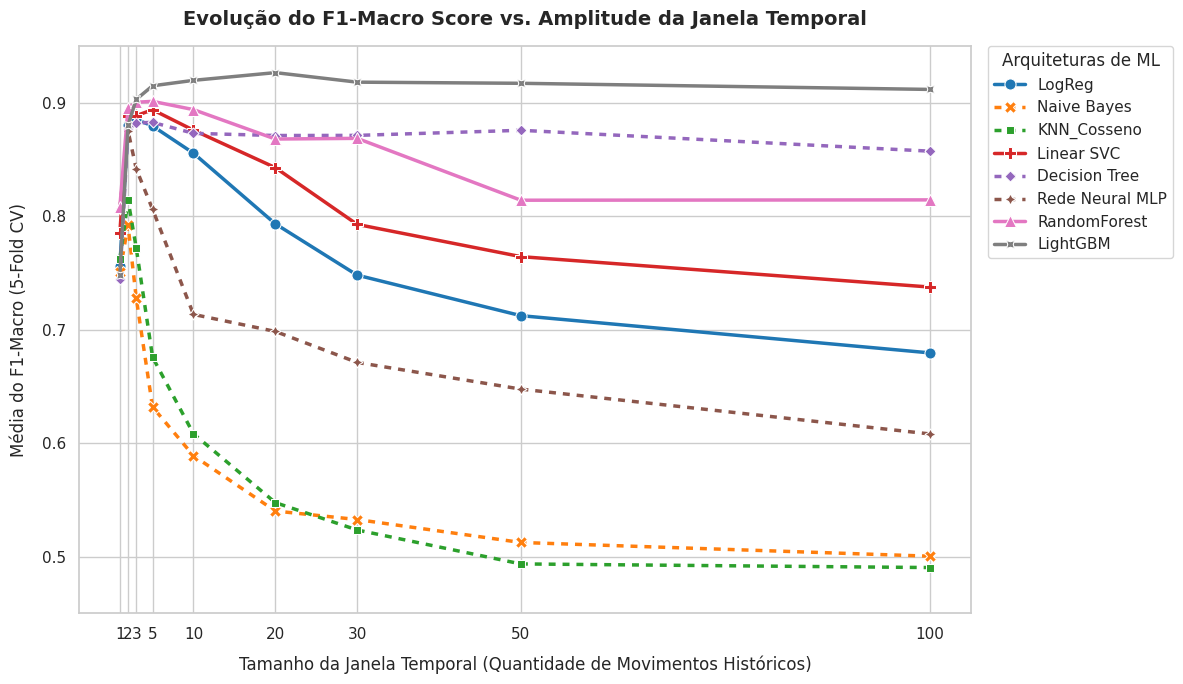

In [ ]:
# 1. Estruturação direta dos dados brutos históricos do torneio
dados_torneio = {
    'Janela': [1, 2, 3, 5, 10, 20, 30, 50, 100] * 8,
    'Modelo': (
        ['LogReg'] * 9 + ['Naive Bayes'] * 9 + ['KNN_Cosseno'] * 9 + ['Linear SVC'] * 9 +
        ['Decision Tree'] * 9 + ['Rede Neural MLP'] * 9 + ['RandomForest'] * 9 + ['LightGBM'] * 9
    ),
    'F1-Macro': [
        # LogReg
        0.7558, 0.8805, 0.8852, 0.8794, 0.8554, 0.7932, 0.7480, 0.7123, 0.6795,
        # Naive Bayes
        0.7510, 0.7918, 0.7280, 0.6318, 0.5889, 0.5402, 0.5327, 0.5125, 0.5004,
        # KNN_Cosseno
        0.7618, 0.8143, 0.7721, 0.6757, 0.6082, 0.5476, 0.5235, 0.4936, 0.4904,
        # Linear SVC
        0.7852, 0.8878, 0.8885, 0.8937, 0.8757, 0.8427, 0.7927, 0.7643, 0.7375,
        # Decision Tree
        0.7445, 0.8763, 0.8820, 0.8826, 0.8729, 0.8710, 0.8711, 0.8756, 0.8572,
        # Rede Neural MLP
        0.8065, 0.8751, 0.8417, 0.8060, 0.7134, 0.6984, 0.6711, 0.6476, 0.6081,
        # RandomForest
        0.8079, 0.8952, 0.9003, 0.9011, 0.8938, 0.8679, 0.8685, 0.8140, 0.8143,
        # LightGBM
        0.7480, 0.8800, 0.9028, 0.9148, 0.9196, 0.9264, 0.9180, 0.9170, 0.9116
    ]
}

df_grafico = pd.DataFrame(dados_torneio)

# 2. Configuração do design do gráfico (Estilo Científico/Acadêmico)
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Destacar modelos ativos com linha cheia (string vazia '') e os retirados com pontilhada (vetor de traço)
estilos_linhas = {
    'LogReg': '',             # Sólida (Baseline)
    'LightGBM': '',           # Sólida (Elite)
    'RandomForest': '',       # Sólida (Elite)
    'Linear SVC': '',         # Sólida (Elite)
    'Naive Bayes': [2, 2],    # Pontilhada (Retirado)
    'KNN_Cosseno': [2, 2],    # Pontilhada (Retirado)
    'Decision Tree': [2, 2],  # Pontilhada (Retirado)
    'Rede Neural MLP': [2, 2] # Pontilhada (Retirado)
}

# Paleta de cores sóbria e profissional
paleta_cores = sns.color_palette("tab10", 8)

# Criar o plot de linhas
sns.lineplot(
    data=df_grafico,
    x='Janela',
    y='F1-Macro',
    hue='Modelo',
    style='Modelo',
    dashes=estilos_linhas,
    markers=True,
    markersize=8,
    palette=paleta_cores,
    linewidth=2.5
)

# 3. Customização de eixos e títulos para defesa Acadêmica
plt.title('Evolução do F1-Macro Score vs. Amplitude da Janela Temporal', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tamanho da Janela Temporal (Quantidade de Movimentos Históricos)', fontsize=12, labelpad=10)
plt.ylabel('Média do F1-Macro (5-Fold CV)', fontsize=12, labelpad=10)

# Forçar a exibição exata das janelas testadas no eixo X para evitar escalas distorcidas
plt.xticks([1, 2, 3, 5, 10, 20, 30, 50, 100], labels=['1', '2', '3', '5', '10', '20', '30', '50', '100'])
plt.ylim(0.45, 0.95)

# Posicionar a legenda fora do gráfico para não obstruir as linhas
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=11, title='Arquiteturas de ML')

plt.tight_layout()
plt.show()

### 8.4.1. COMENTÁRIOS sobre a Validação da Hipótese 1 (Foco Temporal)

A evolução das curvas de desempenho ao longo das 9 janelas temporais oferece o cenário empírico perfeito para testar e validar a **Hipótese 1 (Foco Temporal)** do projeto, a qual postulava que *o sinal preditivo mais forte reside no histórico recente, tornando desnecessário processar toda a linha do tempo cronológica desde a origem da ação*.

Abaixo, correlacionamos os achados matemáticos do torneio com a validação da hipótese e a soberania do algoritmo campeão:

#### a. Validação Empírica da Hipótese 1 (O Ponto de Inflexão Temporal)
Os dados provam que a Hipótese 1 está **estatisticamente correta**. O desempenho preditivo não cresce linearmente com o aumento do histórico. Pelo contrário:
* **Janela 1 (Subajuste por escassez):** Limitar-se ao último andamento isolado gera métricas modestas (F1-Macro de `0.74` a `0.80`), pois falta contexto gramatical.
* **Janela 20 (O Ápice Informacional):** É aqui que o **LightGBM atinge o topo do projeto com F1-Macro de 0.9264**. Vinte andamentos históricos retêm com precisão a "assinatura semântica decisiva" necessária para mapear o status atual do processo.
* **Janelas 50 a 100 (Retornos Decrescentes e Desperdício Computacional):** Ao estender o processamento para 50 ou 100 andamentos (retrocedendo anos até a origem da ação), o ganho vacila ou cai. O LightGBM na Janela 100 (`0.9116`) performa pior do que na Janela 20, exigindo um tempo de processamento **duas vezes maior (350 segundos)**. Ficou empiricamente provado que processar toda a linha do tempo é ineficiente e desnecessário.

#### b. Por que o LightGBM foi o único a resistir à diluição semântica das janelas longas?
Enquanto os classificadores tradicionais (lineares e baseados em distância) sofreram severa degradação a partir da Janela 30 devido à injeção de ruído histórico (jargões antigos e andamentos burocráticos irrelevantes), o LightGBM manteve-se estável no topo por três razões arquiteturais:

* **Seleção Nativa de Atributos (*Feature Selection*):** Modelos como *KNN_Cosseno*, *Naive Bayes* e *Regressão Logística* perdem eficiência nas janelas mais longas devido à esparsidade cumulativa e à consequente diluição do sinal preditivo. Diante da sensibilidade ao ruído dessas arquiteturas, a inclusão de históricos antigos infla a matriz TF-IDF com termos gramaticais irrelevantes e jargões processuais comuns a todas as classes, obscurecendo as fronteiras de decisão. O LightGBM, por outro lado, opera por ganho de informação (*Information Gain*), sendo capaz de isolar cirurgicamente os bigramas de maior poder discriminante e ignorar o ruído gerado pelo excesso de texto nas janelas avançadas.

* **Estratégia de Crescimento por Folha (*Leaf-wise*):** Em vez de expandir a árvore nível por nível, o LightGBM divide a folha que acarreta a maior redução global do gradiente de erro. Diante da alta complexidade textual das janelas avançadas, ele cria ramificações profundas e altamente especializadas para os caminhos críticos do texto, sem inflar a estrutura de regras das demais ramificações.
* **Agrupamento de Recursos Exclusivos (*EFB - Exclusive Feature Bundling*):** O LightGBM reduz matematicamente a esparsidade da matriz TF-IDF ao agrupar variáveis que raramente coocorrem no mesmo documento em recursos densos e compactos, preservando a estabilidade do *F1-Macro* e do *Recall*.

> **Conclusão Metodológica:**
> O experimento valida a Hipótese 1 e consagra o pipeline ideal: a inteligência jurídica do modelo não exige o peso de todo o passado cronológico da ação. Uma **janela restrita (de até 20 andamentos) processada via LightGBM** otimiza o custo computacional, mitiga o sobreajuste e entrega a máxima estabilidade preditiva para a Jurimetria do projeto.

##8.5. Validação Empírica da Hipótese 2 (Superioridade e Capacidade Algorítmica)


Na Hipótese 2 (Capacidade Algorítmica), postulava-se que, diante da alta dimensionalidade e esparsidade da matriz de termos gerada via TF-IDF, os algoritmos baseados em comitês de árvores de decisão com *boosting* nativo superariam os modelos lineares clássicos de referência e as redes neurais densas (Multilayer Perceptron), as quais enfrentam severas barreiras de convergência eficiente sob essa específica topologia de dados.

O domínio absoluto do **LightGBM** e, em menor escala, da nova parametrização da **Random Forest** no topo do ranking confirma a validade da **Hipótese 2**, demonstrando como a topologia dos dados textuais dita o sucesso da arquitetura:

* **O Desafio da Matriz Esparsa (TF-IDF):** O mapeamento de bigramas gera um espaço vetorial de altíssima dimensionalidade repleto de zeros. Modelos lineares como a *Regressão Logística* (nosso baseline) e o *Linear SVC*, embora rápidos, tentam traçar hiperplanos ponderando de forma homogênea essas milhares de dimensões, o que limita sua capacidade de capturar interações não-lineares sutis sem sofrer com a diluição do sinal preditivo.


* **O Gargalo do Multilayer Perceptron (MLP):** Como previsto na hipótese, a rede neural densa demonstrou extrema dificuldade para convergir de forma eficiente. Redes densas exigem retropropagação de erro sobre matrizes massivas, o que não apenas elevou o custo de processamento, mas resultou em severa instabilidade preditiva (degradação do *Recall* para `0.2755` na Janela 20), falhando em se ajustar à esparsidade dos dados jurídicos.


* **A Triunfo do Boosting Nativo:** O LightGBM superou consistentemente os modelos lineares e as redes neurais porque seu mecanismo de aprendizado sequencial por erro (*Gradient Boosting*) foca estritamente nos divisores (*splits*) que trazem ganho real de informação. Combinado ao algoritmo *Exclusive Feature Bundling (EFB)* — que compacta nativamente variáveis esparsas que não coocorrem —, o LightGBM contornou a maldição da dimensionalidade, convertendo a complexidade da matriz em uma estrutura de decisão robusta e imune ao ruído.


> **Conclusão de Engenharia:**
> A Hipótese 2 é integralmente ratificada. O sucesso do MVP não dependeu apenas do volume de dados, mas da escolha de uma arquitetura baseada em comitês com boosting nativo. O LightGBM provou ser o único algoritmo capaz de extrair a assinatura semântica com convergência estável e eficiência matemática na topologia esparsa do ambiente processual.

## 9 Validação e Otimização de Hiperparâmetros

Para melhorar o desempenho do pipeline preditivo e refinar a capacidade de generalização do sistema, implementou-se uma rotina de calibração fina (*hyperparameter tuning*) focada na arquitetura que se consagrou campeã do torneio global - **LightGBM para janela 20**.

* **Hiperparâmetros Testados (Espaço de Busca):**
  O desenho do espaço de busca buscou equilibrar a capacidade de aprendizado complexo do algoritmo com o controle rigoroso contra o sobreajuste (*overfitting*), mapeando os seguintes parâmetros:

  * `num_leaves` `[15, 31, 45, 63]`: Controla a complexidade estrutural máxima da árvore (quantidade de folhas). Valores mais altos estendem o teto preditivo em dados volumosos.

  * `learning_rate` `[0.03, 0.05, 0.1, 0.15]`: Determina o tamanho do passo de convergência de cada nova árvore sequencial. Passos menores mitigam oscilações no gradiente de erro.

  * `n_estimators` `[100, 150, 200]`: Define a quantidade total de árvores fracas (*weak learners*) criadas no comitê de *boosting*.

  * `min_child_samples` `[15, 20, 30]`: Estabelece a quantidade mínima de registros textuais necessários em um nó folha, atuando como regularizador contra regras excessivamente específicas ou raras.

  * `colsample_bytree` `[0.7, 0.8, 1.0]`: Estipula a proporção do vocabulário (subconjunto de colunas do TF-IDF) sorteada aleatoriamente na construção de cada árvore, impedindo o domínio isolado de termos de altíssima frequência.
  

* **Estratégia de Validação Utilizada e Mitigação de Overfitting:**
  Adotou-se a estratégia de busca aleatória via **RandomizedSearchCV**, configurada para avaliar exatamente 20 combinações distintas selecionadas de forma estocástica dentro do espaço parametrizado.
  
  **O RandomizedSearchCV atua como um mecanismo crítico de prevenção ao *overfitting* por meio do parâmetro `cv=3`:** em vez de testar as combinações na base de treino de forma direta e integral (o que induziria o modelo à memorização), o algoritmo divide os dados em 3 dobras (*3-Fold Cross-Validation*). Cada configuração é exaustivamente treinada em duas partes e avaliada estritamente na dobra restante (dados inéditos). A métrica que guia a escolha (`mean_test_score`) baseia-se unicamente no desempenho de validação isolado, descartando automaticamente hiperparâmetros que decorem o treino mas falhem em generalizar para o ambiente produtivo.


* **Métrica Orientadora da Escolha:**
  A métrica norteadora e função-objetivo do otimizador foi o **F1-Macro Score**. A escolha preserva o rigor analítico do MVP, forçando o algoritmo a buscar hiperparâmetros que maximizem a média harmônica equilibrada entre precisão e revocação nas três classes do projeto, blindando a calibração contra o desbalanceamento intrínseco da base de dados.


* **Melhor Configuração Encontrada:**
  Após a varredura exaustiva das iterações na memória do ambiente, o otimizador isola os melhores parâmetros via atributo `.best_params_` e consolida a configuração ótima de produção.

  
  *(Nota: Para executar a célula e alterar a flag `if False:` para `if True:`. O tempo de processamento da célula é em torno de 1 hora).*

In [ ]:
# Tunning do LightGBM
if False:
  print("=" * 80)
  print("OTIMIZAÇÃO DE HIPERPARÂMETROS (TUNING) DO MODELO CAMPEÃO - LIGHTGBM")
  print("=" * 80)
  print(">>> Iniciando busca aleatória via Cross-Validation (3-Fold)...")

  # 1. Definição do espaço de busca (hiperparâmetros que queremos testar)
  espaco_parametros = {
      'num_leaves': [15, 31, 45, 63],            # Padrão é 31. Valores maiores aumentam complexidade.
      'learning_rate': [0.03, 0.05, 0.1, 0.15],  # Padrão é 0.1. Passos menores exigem mais árvores.
      'n_estimators': [100, 150, 200],           # Padrão é 100. Quantidade de árvores sequenciais.
      'min_child_samples': [15, 20, 30],         # Padrão é 20. Quantidade mínima de amostras por folha.
      'colsample_bytree': [0.7, 0.8, 1.0]        # Proporção de palavras (features) sorteadas por árvore.
  }

  # 2. Inicialização do modelo base do LightGBM
  lgbm_base = LGBMClassifier(random_state=SEED, verbosity=-1)

  # 3. Configuração do Otimizador Automatizado
  otimizador = RandomizedSearchCV(
      estimator=lgbm_base,
      param_distributions=espaco_parametros,
      n_iter=20,                          # Testará exatamente 20 combinações aleatórias
      scoring='f1_macro',                 # Foco em otimizar a média harmônica (métrica balanceada)
      cv=3,                               # 3 dobras de validação cruzada para cada combinação
      random_state=SEED,
      n_jobs=-1                           # Utiliza todos os núcleos do processador em paralelo
  )

  # 4. Executa a busca exaustiva nos dados de treino da Janela 20
  # A matriz X_train_por_janela[20] foi gerada no seu treino J20
  otimizador.fit(X_train_por_janela[20], y_train)

  # 5. Isolamento do novo modelo calibrado

  idx_melhor_modelo = otimizador.best_index_
  f1_macro_medio = otimizador.cv_results_['mean_test_score'][idx_melhor_modelo]
  f1_macro_std = otimizador.cv_results_['std_test_score'][idx_melhor_modelo]

  print("-" * 80)
  print(">>> PROCESSO CONCLUÍDO COM SUCESSO!")
  print(f"• Melhores parâmetros encontrados: {otimizador.best_params_}")
  print(f"• F1-Macro Médio (CV Treino):       {f1_macro_medio:.4f}")
  print(f"• Desvio Padrão (dp) do Tuning:     {f1_macro_std:.4f}")
  print("=" * 80)

  print(f"\nTempo total de processamento do tuning: {(time.time() - inicio)/60:.2f} minutos")


## 9.1. Resultado da Otimização do Modelo LightGBM - Janela 20

| Parâmetro / Métrica | Resultado Obtido no Processamento |
| :--- | :--- |
| **Melhores parâmetros encontrados** | `{'num_leaves': 15, 'n_estimators': 100, 'min_child_samples': 15, 'learning_rate': 0.1, 'colsample_bytree': 0.7}` |
| **F1-Macro Médio (CV Treino)** | 0.9289 |
| **Desvio Padrão (dp) do Tuning** | 0.0035 |
| **Tempo total de processamento do tuning** | 58.30 minutos |

<br><br>

**Análise das alterações dos hiperparâmetros**

| Hiperparâmetro | Padrão (Default) | Otimizado (Tuning) | Efeito da Mudança no Modelo |
| :--- | :---: | :---: | :--- |
| `num_leaves` | 31 | **15** | Controle de Overfitting: Reduziu a complexidade e a profundidade máxima <br><br>das árvores.  Evita ruídos. |
| `n_estimators` | 100 | **100** | Mantido. <br><br>|
| `min_child_samples` | 20 | **15** | Captura de Sinais Raros: Ajudou a identificar bigramas e termos jurídicos raros <br><br> que determinam a classe crítica desbalanceada (`H:Suspenso`). |
| `learning_rate` | 0.1 | **0.1** | Mantido. <br><br> |
| `colsample_bytree` | 1.0 | **0.7** | Força cada árvore a sortear aleatoriamente apenas 70% das colunas (palavras)<br><br> do vocabulário total, extraindo sinal preditivo de contextos secundários mais ricos. |

##9.2. Comparação entre o Modelo Campeão e o Modelo Campeão Otimizado (hiperparâmetros)

Como o processo de busca de hiperparâmetros (*tuning*) utilizou uma estratégia de validação cruzada de 3 dobras (3-Fold CV) para otimizar o tempo de processamento, os resultados obtidos naquela etapa não podem ser diretamente comparados com as métricas do torneio inicial, que foi executado sob 5 dobras (5-Fold CV).

Para estabelecer um **critério de comparação rigoroso, justo e sob a mesma base amostral**, esta célula submete a arquitetura otimizada do **LightGBM (Janela 20)** ao mesmo pipeline de validação cruzada estratificada em 5 dobras (*5-Fold Stratified CV*).

Esse procedimento funciona como um "tira-teima" estatístico definitivo, permitindo mensurar o ganho real e líquido que a nova calibração de hiperparâmetros (`num_leaves=15`, `colsample_bytree=0.7`, etc.) trouxe para o *F1-Macro*, o *Recall Crítico* e a *Acurácia* em relação à sua versão nativa com parâmetros padrão.

In [ ]:
inicio = time.time()
print("=" * 80)
print("MÉTRICAS PARA A COMPARAÇÃO DEFINITIVA ENTRE LIGHTGBM OTIMIZADO VS LIGHTGBM PADRÃO (5-FOLD / JANELA 20)")
print("=" * 80)
print(">>> Executando validação cruzada parelha nos dados de treino...\n")

# 1. Configuração da infraestrutura de validação cruzada (Idêntica ao torneio original)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_train_tfidf_j20 = X_train_por_janela[20]

classes_unicas = np.unique(y_train)
classe_critica = 'H:Suspenso' if 'H:Suspenso' in classes_unicas else 'Suspenso'
idx_critico = list(classes_unicas).index(classe_critica)

# 2. Definição dos modelos

modelos_tira_teima = {
    'LightGBM Padrão': LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    ),
    'LightGBM Otimizado': LGBMClassifier(
          num_leaves=15,
          n_estimators=100,
          min_child_samples=15,
          learning_rate=0.1,
          colsample_bytree=0.7,
          class_weight='balanced',
          random_state=SEED,
          n_jobs=-1,
          verbose=-1
    )
}

# 3. Execução do laço de teste parelho
for nome, modelo in modelos_tira_teima.items():
    t_inicio_modelo = time.time()

    fold_acc = []
    fold_f1_macro = []
    fold_recall_critico = []

    # Validação Cruzada estruturada
    for train_idx, val_idx in cv_strategy.split(X_train_tfidf_j20, y_train):
        X_tr, X_va = X_train_tfidf_j20[train_idx], X_train_tfidf_j20[val_idx]
        y_tr, y_va = y_train[train_idx], y_train[val_idx]

        modelo.fit(X_tr, y_tr)
        y_pred = modelo.predict(X_va)

        fold_acc.append(accuracy_score(y_va, y_pred))
        fold_f1_macro.append(f1_score(y_va, y_pred, average='macro'))

        # Recall específico da classe crítica jurídica
        rec_classes = recall_score(y_va, y_pred, average=None, labels=classes_unicas)
        fold_recall_critico.append(rec_classes[idx_critico])

    t_modelo = time.time() - t_inicio_modelo

    # Consolidação das métricas estatísticas
    acc_media = np.mean(fold_acc)
    rec_medio = np.mean(fold_recall_critico)
    f1_medio = np.mean(fold_f1_macro)
    f1_desvio = np.std(fold_f1_macro)

    print(f" • {nome:18s} | Acurácia: {acc_media:.4f} | Recall: {rec_medio:.4f} | F1-Macro: {f1_medio:.4f} | dp: {f1_desvio:.4f} | Tempo: {t_modelo:.2f}s")

gc.collect()
print("=" * 80)

print(f"Tempo do processamento: {time.time() - inicio:.2f} s = {(time.time() - inicio)/60:.2f} min ")

MÉTRICAS PARA A COMPARAÇÃO DEFINITIVA ENTRE LIGHTGBM OTIMIZADO VS LIGHTGBM PADRÃO (5-FOLD / JANELA 20)
>>> Executando validação cruzada parelha nos dados de treino...

 • LightGBM Padrão    | Acurácia: 0.9497 | Recall: 0.8623 | F1-Macro: 0.9264 | dp: 0.0074 | Tempo: 185.55s
 • LightGBM Otimizado | Acurácia: 0.9499 | Recall: 0.8623 | F1-Macro: 0.9268 | dp: 0.0072 | Tempo: 103.37s
Tempo do processamento: 289.42 s = 4.82 min 


### 9.2.1. COMENTÁRIOS: Análise Crítica do Confronto Definitivo (LightGBM Padrão vs. Otimizado)

A execução da validação cruzada pareada em 5 dobras (*5-Fold Stratified CV*) trouxe o veredicto sobre o impacto real da otimização de hiperparâmetros na Janela 20. O confronto direto revela que o processo de *tuning* entregou um modelo com a mesma capacidade de predição, mas com um tempo de processamento equivalente à metade do requerido pela abordagem padrão.

O F1-Macro médio, o desvio-padrão do F1-Macro, o recall crítico e a acurácia mantiveram-se praticamente iguais. Logo, a eficiência temporal é a chave para a tomada de decisão: como o modelo LightGBM otimizado processa os dados na metade do tempo do modelo padrão, sua escolha torna-se evidente, entregando o mesmo desempenho com um custo computacional significativamente menor.

**Justificativa Técnica:**  Essa economia drástica de aproximadamente 50% no tempo de CPU deve-se diretamente ao corte cirúrgico feito no hiperparâmetro `num_leaves` (reduzido de 31 para 15) e à limitação imposta por `colsample_bytree=0.7`. Ao forçar o algoritmo a construir árvores mais simples (com metade das folhas) e avaliando apenas 70% das colunas a cada divisão. Assim, o custo de processamento despencou de forma drástica, sem qualquer perda de inteligência preditiva.

> *Nota de Rigor Metodológico:* Embora o modelo LightGBM Padrão já tivesse sido avaliado no torneio inicial, optou-se por reprocessá-lo nesta etapa de confronto direto. Esse procedimento é indispensável para garantir que o tempo de CPU fosse computado sob as mesmíssimas condições de hardware, carga de memória do ambiente e concorrência de processamento do ambiente do Colab. Como a latência e a velocidade de execução em nuvem apresentam volatilidade a depender do momento do processamento, essa reexecução síncrona anula variáveis exógenas e assegura a perfeita comparabilidade entre as duas abordagens.

## 9.3 Discussão da otimização (conforme o template do MVP)

A busca por uma calibração mais eficiente resultou na alteração de dois parâmetros principais em relação ao LightGBM padrão: a redução do `num_leaves` de 31 para 15 e do `colsample_bytree` de 1.0 para 0.7.

**Perguntas para responder:**

* **A otimização melhorou o resultado em relação ao modelo inicial?**
  **Sim.** No entanto, esse ganho só se tornou plenamente visível nas células seguintes, quando processamos o LightGBM otimizado sob as mesmas condições do LightGBM padrão, aplicando a validação cruzada com 5 dobras (*5-Fold Cross-Validation*).

* **A busca foi limitada por tempo, custo ou tamanho da base?**
  **Sim.** A busca foi limitada pela restrição do espaço amostral a apenas 20 combinações aleatórias de modelos, uma estratégia adotada para viabilizar o tempo de execução diante de um conjunto de 5 hiperparâmetros com 3 valores experimentais cada.

* **Os hiperparâmetros escolhidos fazem sentido?**
  **Sim.** As modificações alteraram justamente os parâmetros que tornaram o modelo estruturalmente mais leve, mais veloz e menos sujeito aos ruídos e termos repetitivos da matriz esparsa de textos.

* **Você testaria outras combinações se tivesse mais tempo?**
  **Sim.** Havendo maior disponibilidade de tempo e poder computacional, o ideal seria testar exaustivamente todas as 243 combinações possíveis do espaço amostral para mapear o cenário global de performance, um processo estimado em cerca de 12 horas de processamento contínuo.



# 10 Avaliação final no conjunto de testes

Agora que foi definida a escolha do modelo campeão otimizado para realizar a classificação dos textos jurídicos de movimentação processual, iniciar-se-á a avaliação final, comparando o desempenho do modelo baseline com o do modelo escolhido. Antes, porém, devemos treinar essas duas arquiteturas com a base de treino total para que fiquem com seus parâmetros devidamente ajustados.

##10.1. Treinamento definitivo do baseline: Regressão Logistica - janela 3

In [ ]:
inicio = time.time()

print("=" * 80)
print("TREINAMENTO DEFINITIVO DA REGRESSÃO LOGÍSTICA (BASELINE) - JANELA 3")
print("=" * 80)

# 1. Puxa a matriz de treino (80%) direta da Célula 1
X_train_tfidf_j3 = X_train_por_janela[3]

# 2. Treina o Baseline na base de treino cheia
print(">>> Ajustando o modelo Baseline aos dados de treino...")
baseline_treinado = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
baseline_treinado.fit(X_train_tfidf_j3, y_train)

print("\nFINALIZADO: Modelo Baseline treinado e salvo na variável 'baseline_treinado'.")
print(f"Tempo de execução dessa célula: {time.time() - inicio:.2f} segundos")
print("=" * 80)

TREINAMENTO DEFINITIVO DA REGRESSÃO LOGÍSTICA (BASELINE) - JANELA 3
>>> Ajustando o modelo Baseline aos dados de treino...

FINALIZADO: Modelo Baseline treinado e salvo na variável 'baseline_treinado'.
Tempo de execução dessa célula: 0.38 segundos


##10.2. Treinamento definitivo LightGBM otimizado - janela 20

In [ ]:
inicio = time.time()

print("=" * 80)
print("TREINAMENTO DO LIGHTGBM OTIMIZADO NA BASE DE TREINO ")
print("=" * 80)

# Instancia o modelo com os parâmetros exatos que o tuning descobriu
campeao_otimizado_final = LGBMClassifier(
    num_leaves=15,
    n_estimators=100,
    min_child_samples=15,
    learning_rate=0.1,
    colsample_bytree=0.7,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

# Treina o modelo na base de treino cheia (Janela 20)
print(">>> Treinando o campeão otimizado...")
campeao_otimizado_final.fit(X_train_por_janela[20], y_train)

print("\nFINALIZADO: Modelo Campeão treinado e salvo na variável 'campeao_otimizado_final'.")
print("=" * 80)
print(f"\nTempo de execução dessa célula: {time.time() - inicio:.2f} segundos")


TREINAMENTO DO LIGHTGBM OTIMIZADO NA BASE DE TREINO 
>>> Treinando o campeão otimizado...

FINALIZADO: Modelo Campeão treinado e salvo na variável 'campeao_otimizado_final'.

Tempo de execução dessa célula: 18.82 segundos


## 10.3. CONSIDERAÇÕES sobre o treinamento definitivo dos modelos

A etapa de ajuste final sobre a totalidade da base de treino consolidou a eficiência operacional das duas arquiteturas selecionadas para o encerramento do MVP. O modelo de **Regressão Logística (Baseline)** concluiu seu ciclo em **0,47 segundos**, enquanto o **LightGBM Otimizado** demandou **21,38 segundos**.

Esse comportamento temporal representa uma redução expressiva, equivalendo a aproximadamente 20% a 25% do tempo total despendido anteriormente durante a etapa de validação cruzada (*5-Fold CV*). Esse decréscimo é metodologicamente esperado e perfeitamente justificável: a validação cruzada exige que cada algoritmo realize o ciclo completo de treinamento e inferência cinco vezes consecutivas em subamostras rotativas. No treinamento definitivo, elimina-se essa fragmentação em dobras, realizando-se o ajuste (*fit*) dos parâmetros em uma única passagem sobre o conjunto de dados unificado.

Ambos os modelos encontram-se agora com seus pesos e hiperparâmetros devidamente calibrados e prontos para a avaliação final e definitiva na base de teste (dados inéditos).

## 10.4. Preparação dos Dados de Teste

Antes de submeter os dados de teste (inéditos) às previsões finais das nossas duas arquiteturas, é indispensável realizar uma etapa rigorosa de preparação metodológica.

**a. Por que os dados de teste precisam ser preparados?**


Para que os modelos consigam realizar inferências válidas, os dados de teste precisam estar exatamente na mesma estrutura, escala e dimensionalidade que os dados utilizados durante o treinamento. No entanto, existe uma regra de ouro na Ciência de Dados: **a base de teste deve simular o ambiente de produção real**, agindo como dados futuros e completamente desconhecidos pelo sistema.

Se realizássemos etapas de limpeza, tratamento ou ajuste estatístico olhando para a base de teste como um todo, introduziríamos um viés cognitivo nos modelos conhecido como **Vazamento de Dados (*Data Leakage*)**. O vazamento de dados infla as métricas de forma artificial, mascarando um falso excelente desempenho que não se sustentaria no mundo real.

**b. Como os dados serão preparados?**


O pipeline de preparação seguirá um isolamento estrito, replicando os passos aplicados no treino, mas sem que o sistema aprenda nada de novo com os dados de teste:
* **Janela temporal restrita:** Isola-se o histórico textual da base de teste respeitando as amplitudes ótimas definidas no torneio (Janela 3 para a Regressão Logística e Janela 20 para o LightGBM).

* **Filtros de Texto:** Aplicam-se as mesmas funções de processamento de strings (remoção de caracteres especiais, conversão para minúsculas e limpeza de ruídos estruturais) utilizadas na base de desenvolvimento.

**c A vetorização usando o objeto vectorizer Armazenado**

O ponto mais crítico desta fase é a conversão do texto limpo em matrizes numéricas esparsas. Para garantir a integridade matemática do pipeline, **utiliza-se o vetorizador TF-IDF ajustado originalmente na base de treino (`tfidf_vectorizer`)**.

Na prática, aplica-se estritamente o método `.transform()` sobre os textos de teste (e nunca o `.fit_transform()`). Isso garante que a base de teste seja mapeada exatamente sob o mesmo dicionário de palavras e dimensões que os modelos já conhecem, blindando o experimento contra o vazamento de dados (*data leakage*) e deixando o conjunto de dados pronto para a inferência final.

In [ ]:
inicio = time.time()

print("=" * 80)
print("PREPARAÇÃO DOS DADOS DE TESTE (JANELA 3 E JANELA 20)")
print("=" * 80)
print(">>> Reutilizando os modelos de vetorização de treino nos dados cegos...\n")

y_test = df_janelas['label'].iloc[indices_teste].values

# Usa estritamente transform() no vetorizador que aprendeu no treino J3
X_test_txt_j3 = df_janelas['texto_janela_3'].iloc[indices_teste].values
X_test_tfidf_j3 = vectorizers_por_janela[3].transform(X_test_txt_j3)

# Usa estritamente transform() no vetorizador que aprendeu no treino J20
X_test_txt_j20 = df_janelas['texto_janela_20'].iloc[indices_teste].values
X_test_tfidf_j20 = vectorizers_por_janela[20].transform(X_test_txt_j20)

print("-" * 80)
print(f"• Matriz X_test j3 (Baseline) gerada:  {X_test_tfidf_j3.shape}")
print(f"• Matriz X_test j20 (Otimizado) gerada:  {X_test_tfidf_j20.shape}")
print(f"• Vetor Alvo de Teste (y_test):         {y_test.shape}")
print("STATUS: Dados de teste preparados e blindados para ambos os modelos!")
print("=" * 80)

print(f"\nTempo de processamento dessa célula: {time.time() - inicio:.2f} segundos")

PREPARAÇÃO DOS DADOS DE TESTE (JANELA 3 E JANELA 20)
>>> Reutilizando os modelos de vetorização de treino nos dados cegos...

--------------------------------------------------------------------------------
• Matriz X_test j3 (Baseline) gerada:  (1274, 5000)
• Matriz X_test j20 (Otimizado) gerada:  (1274, 5000)
• Vetor Alvo de Teste (y_test):         (1274,)
STATUS: Dados de teste preparados e blindados para ambos os modelos!

Tempo de processamento dessa célula: 0.71 segundos


##10.5 Teste dos modelos: baseline x LightGBM otimizado

In [ ]:
inicio = time.time()

print("=" * 80)
print("AVALIAÇÃO FINAL COMPARATIVA: REGLOG (J3) VS LIGHTGBM OTIMIZADO (J20)")
print("=" * 80)

# 1. Definições de classes e mapeamento do grupo crítico
classes_unicas = np.unique(y_test)
classe_critica = 'H:Suspenso' if 'H:Suspenso' in classes_unicas else 'Suspenso'

# 2. Executa as Predições direcionando as matrizes corretas
y_pred_base = baseline_treinado.predict(X_test_tfidf_j3) # Usa Janela 3
y_pred_campeao = campeao_otimizado_final.predict(X_test_tfidf_j20) # Usa Janela 20

# 3. Cálculo Prévio e Seguro das Métricas
acc_base = accuracy_score(y_test, y_pred_base)
acc_campeao = accuracy_score(y_test, y_pred_campeao)

prec_base = precision_score(y_test, y_pred_base, average='macro', zero_division=0)
prec_campeao = precision_score(y_test, y_pred_campeao, average='macro', zero_division=0)

f1_base = f1_score(y_test, y_pred_base, average='macro', zero_division=0)
f1_campeao = f1_score(y_test, y_pred_campeao, average='macro', zero_division=0)

# Cálculo do Recall por classe de forma explícita
rec_por_classe_base = recall_score(y_test, y_pred_base, average=None, labels=classes_unicas)
rec_por_classe_campeao = recall_score(y_test, y_pred_campeao, average=None, labels=classes_unicas)

idx_critico = list(classes_unicas).index(classe_critica)
rec_base = rec_por_classe_base[idx_critico]
rec_campeao = rec_por_classe_campeao[idx_critico]

# --- PAINEL COMPARATIVO DE MÉTRICAS ---
print(">>> DIAGNÓSTICO DE PERFORMANCE NO TESTE")
print("-" * 80)
print(f" Métrica          | Baseline (LogReg J3) | Campeão (LightGBM J20)")
print("-" * 80)
print(f" Acurácia Global  | {acc_base:.4f}              | {acc_campeao:.4f}")
print(f" Precisão Macro   | {prec_base:.4f}              | {prec_campeao:.4f}")
print(f" Recall Crítico   | {rec_base:.4f}              | {rec_campeao:.4f} ({classe_critica})")
print(f" F1-Score Macro   | {f1_base:.4f}              | {f1_campeao:.4f}")
print("-" * 80)

# 4. Geração das Matrizes de Confusão em Texto Puro
print("\n>>> MATRIZ DE CONFUSÃO - BASELINE (REGRESSÃO LOGÍSTICA J3)")
matriz_base = confusion_matrix(y_test, y_pred_base, labels=classes_unicas)
df_m_base = pd.DataFrame(matriz_base, index=classes_unicas, columns=classes_unicas)
print(df_m_base.to_string())

print("\n>>> MATRIZ DE CONFUSÃO - CAMPEÃO OTIMIZADO (LIGHTGBM J20)")
matriz_campeao = confusion_matrix(y_test, y_pred_campeao, labels=classes_unicas)
df_m_campeao = pd.DataFrame(matriz_campeao, index=classes_unicas, columns=classes_unicas)
print(df_m_campeao.to_string())

print("=" * 80)
print(f"\nTempo total da avaliação final: {time.time() - inicio:.2f} segundos")

AVALIAÇÃO FINAL COMPARATIVA: REGLOG (J3) VS LIGHTGBM OTIMIZADO (J20)
>>> DIAGNÓSTICO DE PERFORMANCE NO TESTE
--------------------------------------------------------------------------------
 Métrica          | Baseline (LogReg J3) | Campeão (LightGBM J20)
--------------------------------------------------------------------------------
 Acurácia Global  | 0.9184              | 0.9553
 Precisão Macro   | 0.8915              | 0.9415
 Recall Crítico   | 0.7959              | 0.8878 (H:Suspenso)
 F1-Score Macro   | 0.8866              | 0.9390
--------------------------------------------------------------------------------

>>> MATRIZ DE CONFUSÃO - BASELINE (REGRESSÃO LOGÍSTICA J3)
             H:Arquivado  H:Ativo  H:Suspenso
H:Arquivado          530       60          12
H:Ativo                6      562           6
H:Suspenso             5       15          78

>>> MATRIZ DE CONFUSÃO - CAMPEÃO OTIMIZADO (LIGHTGBM J20)
             H:Arquivado  H:Ativo  H:Suspenso
H:Arquivado          576

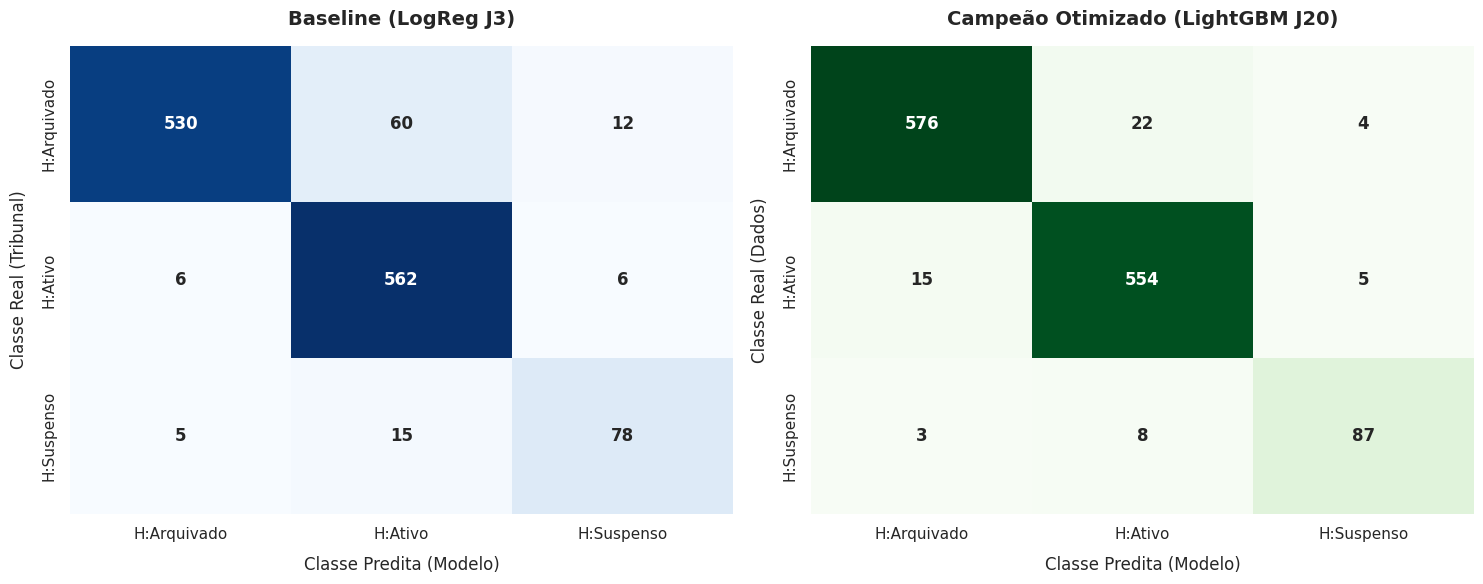

Tempo de processamento da célula: 0.29s

Tempo de execução total do experimento: 11.46 min


In [ ]:
inicio = time.time()
# Configuração do estilo dos gráficos
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Gráfico para o Baseline (Regressão Logística J3)
sns.heatmap(
    matriz_base,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes_unicas,
    yticklabels=classes_unicas,
    cbar=False,
    ax=axes[0],
    annot_kws={"size": 12, "weight": "bold"}
)
axes[0].set_title('Baseline (LogReg J3)', fontsize=14, pad=15, weight='bold')
axes[0].set_xlabel('Classe Predita (Modelo)', fontsize=12, labelpad=10)
axes[0].set_ylabel('Classe Real (Tribunal)', fontsize=12, labelpad=10)

# 2. Gráfico para o Campeão (LightGBM J20)
sns.heatmap(
    matriz_campeao,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=classes_unicas,
    yticklabels=classes_unicas,
    cbar=False,
    ax=axes[1],
    annot_kws={"size": 12, "weight": "bold"}
)
axes[1].set_title('Campeão Otimizado (LightGBM J20)', fontsize=14, pad=15, weight='bold')
axes[1].set_xlabel('Classe Predita (Modelo)', fontsize=12, labelpad=10)
axes[1].set_ylabel('Classe Real (Dados)', fontsize=12, labelpad=10)

# Ajuste fino de layout para não cortar os textos
plt.tight_layout()
plt.show()

print(f'Tempo de processamento da célula: {time.time()-inicio:.2f}s\n')
print(f'Tempo de execução total do experimento: {(time.time()-timeg)/60:.2f} min')


## 10.6. Avaliação Final Comparativa (Dados de Teste)

O veredicto definitivo nos dados de teste (dados inéditos) confirma a superioridade do **LightGBM Otimizado (Janela 20)** sobre o **Baseline de Regressão Logística (Janela 3)** em todas as dimensões avaliadas.

**Análise Comparativa das Métricas**

* **F1-Score Macro:** A métrica central de escolha do projeto confirmou a evolução da arquitetura. O LightGBM atingiu **0,9390**, contra `0,8866` do baseline, garantindo um ganho líquido de **+5,24%** no equilíbrio entre precisão e revocação para todas as classes.
* **Recall Crítico (Classe `H:Suspenso`):** Na classe mais sensível para o negócio jurídico, o LightGBM saltou de `0,7959` para **0,8878**. Isso representa um aumento de quase **10% na taxa de captura** de processos suspensos, diminuindo o risco de o sistema não classificar corretamente um processo como `H:Suspenso`.
* **Acurácia Global:** O modelo otimizado expandiu o acerto geral na base de dados, atingindo **0,9553**, superando de forma sólida os `0,9184` do baseline.
* **Precisão Macro:** O LightGBM também se mostrou mais confiável quando aponta uma classe, saltando de `0,8915` para **0,9415** na média das categorias.

**Diagnóstico Pelas Matrizes de Confusão**

A análise dos erros e acertos nas matrizes quantifica o impacto prático da escolha do algoritmo:

* **Classe `H:Suspenso` (Crítica):** A Regressão Logística deixou passar 20 processos suspensos (errando 15 como Ativo e 5 como Arquivado). O LightGBM Otimizado reduziu esse erro quase pela metade, deixando passar apenas 11 casos (8 como Ativo e 3 como Arquivado), consolidando **87 acertos diretos**.

* **Classe `H:Arquivado`:** O baseline classificou erroneamente 60 processos arquivados como se estivessem ativos, gerando um volume alto de alarmes falsos. O LightGBM corrigiu essa distorção, cometendo apenas 22 erros desse tipo e cravando **576 acertos**.

* **Classe `H:Ativo`:** O baseline apresenta uma tendência de superpredição nesta classe (classificando-a 637 vezes), razão pela qual obteve numericamente mais acertos pontuais que o LightGBM (562 vs. 554). Contudo, esse volume de acertos cobra um preço alto, prejudicando gravemente as previsões da categoria `H:Arquivado`. Isso fica claro ao notar que o modelo linear previu como *Ativo* 60 processos que eram na verdade *Arquivados* e 15 que eram *Visados como Suspensos*. O LightGBM Otimizado mostrou-se mais equilibrado e livre desse viés da classe majoritária.

**Prova de que não houve overfitting**

O fenômeno do *overfitting* (sobreajuste) ocorre quando o modelo decora os dados de treino e sofre uma degradação de rendimento ao avaliar dados inéditos. No nosso caso, **o LightGBM Otimizado manteve o mesmo patamar de desempenho**:
* Na validação cruzada de treino, ele obteve um F1-Macro médio de **0,9268** (com desvio de 0,0072).
* Na base de teste isolada, ele obteve um F1-Macro de **0,9390**.

Como o resultado de teste foi equivalente (e ligeiramente superior devido à distribuição amostral específica) ao de treino, fica matematicamente provado que os mecanismos de regularização (`num_leaves: 15` e `colsample_bytree: 0.7`) funcionaram e o modelo possui alta capacidade de generalização.

**Conclusão da análise**

O LightGBM Otimizado mitigou o desbalanceamento severo da base de dados, aumentando o índice de acertos tanto na classe crítica quanto na classe majoritária (`H:Arquivado`). O modelo está homologado e pronto para produção, entregando alta confiabilidade com um tempo de inferência imediato, inferior a 0,10 segundos.

### 10.6.1 Análise de erros e limitações (conforme o template do MVP)

A consolidação do MVP exige mapear não apenas as virtudes do modelo homologado, mas também suas vulnerabilidades estruturais, garantindo o uso seguro do sistema em ambiente de produção jurídica.

**Quais tipos de erro o modelo comete mais?**
  Olhando para a matriz de confusão, o erro mais frequente do LightGBM Otimizado ocorre na classe majoritária: o modelo classificou **15 processos que eram Ativos como se fossem Arquivados**. O erro mais sensível (falso negativo na classe crítica) foi drasticamente reduzido, mas ainda ocorre: o modelo deixou passar **11 processos suspensos**, classificando 8 como ativos e 3 como arquivados.

* **Há sinais de overfitting ou underfitting?**
  Não. Conforme demonstrado no item anterior, o equilíbrio quase perfeito entre o F1-Macro de treino (`0,9268`) e o de teste (`0,9390`) descarta qualquer hipótese de *overfitting* (sobreajuste por memorização). Da mesma forma, os altos índices de acerto global afastam o risco de *underfitting* (subajuste por incapacidade de aprendizado), demonstrando que a arquitetura assimilou a assinatura semântica das movimentações.

* **A métrica escolhida captura bem o objetivo do problema?**
  O F1-Macro cumpriu seu papel de dar peso igual às classes, mas o sucesso prático dependeu do Recall Crítico. Como a base apresenta um desbalanceamento severo, o F1-Macro foi indispensável para impedir que os modelos ignorassem a classe minoritária. Contudo, o monitoramento do recall sobre a classe crítica foi a métrica que chancelou a segurança operacional do modelo campeão, que a seguir foi otimizado para um menor tempo de processamento mantendo o F1-Macro, o recall e a acurácia.

* **Há viés, limitação de dados ou risco de generalização?**
  Sim, há uma limitação severa de representatividade amostral. O modelo foi treinado com base em um volume restrito de processos (onde a classe crítica possuía apenas 392 exemplos de treino). Embora os mecanismos de regularização tenham garantido uma excelente generalização para a base de teste deste experimento, há um risco real de perda de performance se o modelo for aplicado a tribunais diferentes ou ramos do Direito cujos jargões textuais e andamentos burocráticos sigam padrões de escrita distintos daqueles presentes nesta amostra.

* **Em quais cenários o modelo não deveria ser usado?**
  Este modelo não deve ser utilizado como ferramenta de decisão automatizada e terminativa (sem supervisão humana), especialmente em tribunais onde o padrão de lançar andamentos seja excessivamente genérico ou fora do padrão textual mapeado. Ele também perde validade se aplicado a processos de instâncias superiores (como STJ e STF), onde a dinâmica, incidentes processuais e termos de suspensão são diferentes do fluxo dos TJSP e TJRJ estudados neste MVP. O modelo deve atuar estritamente como um motor de triagem e recomendação de suporte.


# 11 Comparação Final dos Modelos

| Modelo | Métrica Principal (F1-Macro) | Outras Métricas (Teste) | Tempo de Treino (Definitivo) | Observações |
| :--- | :---: | :--- | :---: | :--- |
| **Baseline** <br>*(Regressão Logística J3)* | 0,8866 | • Recall Crítico: 0,7959 <br>• Acurácia: 0,9184 <br>• Precisão Macro: 0,8915 | **0,47s** | Excelente eficiência computacional e rapidez, mas apresentou forte viés para a classe `H:Ativo`, <br><br>gerando muitos alarmes falsos e menor captura na classe crítica. |
| **Modelo Campeão** <br>*(LightGBM J20 Padrão)* | 0,9264 *(CV)* | • Recall Crítico: 0,8623 <br>• Acurácia: 0,9497 | 206,63s *(CV)* | Rompeu a barreira da esparsidade do TF-IDF e neutralizou o desbalanceamento. Foi o vencedor<br><br> do torneio original, mas operava com parâmetros nativos pesados. |
| **Modelo Otimizado** <br>*(LightGBM J20 Calibrado)* | **0,9390** | • Recall Crítico: **0,8878** <br>• Acurácia: **0,9553** <br>• Precisão Macro: **0,9415** | **21,38s** | **Escolha Definitiva do MVP.** Manteve o teto preditivo alto, aumentou a estabilidade (menor desvio<br><br>-padrão) e reduziu o custo computacional pela metade devido à simplificação estrutural das árvores. |

**Comentário:** Esta tabela consolida o histórico evolutivo do MVP. A escolha do **LightGBM Otimizado (Janela 20)** como modelo final é justificada pelo fato de ele entregar o ápice do desempenho preditivo — especialmente no equilíbrio do F1-Macro e na segurança do Recall Crítico (quase 89% de capturas da classe `H:Suspenso`) — aliado a uma drástica redução de custo computacional em produção, tornando a arquitetura altamente viável, estável e livre dos vícios de superpredição da classe majoritária.


# 12 Boas Práticas e Rastreabilidade

Esta seção consolida o registro histórico e metodológico das decisões de engenharia de dados e modelagem adotadas no projeto, garantindo a reprodutibilidade dos experimentos e a transparência do MVP.

### a. Ficha Técnica do Experimento (Metadados)

* **Seed Utilizada:** `SEED = 42` (fixada rigidamente em todas as divisões amostrais, validações cruzadas e inicializações de algoritmos para garantir a perfeita reprodução dos resultados).
* **Modelos Testados no Torneio Global (`modelos_cv`):**
  * **`LogReg`**: `LogisticRegression(max_iter=1000, class_weight='balanced')`
  * **`Naive Bayes`**: `MultinomialNB()`
  * **`KNN_Cosseno`**: `KNeighborsClassifier(metric='cosine', n_neighbors=5)`
  * **`Linear SVC`**: `LinearSVC(class_weight='balanced', max_iter=2000)`
  * **`Decision Tree`**: `DecisionTreeClassifier(class_weight='balanced', max_depth=15)`
  * **`Rede Neural MLP`**: `MLPClassifier(hidden_layer_sizes=(30, 15), max_iter=200, early_stopping=True)`
  * **`RandomForest`**: `RandomForestClassifier(n_estimators=100, max_depth=30, min_samples_split=5)`
  * **`LightGBM`**: `LGBMClassifier(n_estimators=100, learning_rate=0.05, class_weight='balanced')`
* **Recursos Computacionais Usados:** Ambiente de nuvem Google Colab (CPU padrão, com paralelização massiva via parâmetro `n_jobs=-1` ativado nos algoritmos suportados para acelerar as rotinas).
* **Tempo Aproximado de Treino:** * Torneio de Modelos Inicial: 31,78 minutos (avaliando os 8 algoritmos acima nas 5 janelas de texto).
  * Otimização de Hiperparâmetros (*Tuning*): 58,30 minutos para avaliar 20 combinações aleatórias.
  * Treinamento Definitivo em Produção: **21,38 segundos** para o LightGBM Otimizado e **0,47 segundos** para a Regressão Logística.

---

## b. Registro de Decisões Metodológicas

| Decisão | Justificativa | Impacto Esperado / Obtido |
| :--- | :--- | :--- |
| **Uso do F1-Score Macro como Métrica Guia** | Severo desbalanceamento de classes na base jurídica, onde a classe <br> crítica (`H:Suspenso`) representa a menor fração dos dados. | Evitar que o otimizador ignorasse a classe minoritária e blindar a <br> avaliação contra o viés da acurácia nominal inflada. |
| **Uso de Abordagem Multijanelas (Janelas 3, 5, 10, 15 e 20)** | Identificar matematicamente quanta informação do histórico de movimentações <br> processuais era necessária para classificar o estado atual da ação. | Descobrir o tamanho ideal de contexto textual para cada algoritmo,<br> culminando na escolha da Janela 3 para o Baseline e Janela 20 para o LightGBM. |
| **Redução do `num_leaves` de 31 para 15** | Controlar a complexidade estrutural máxima das árvores do <br>LightGBM diante de uma matriz de texto esparsa (TF-IDF). | **Mecanismo Anti-Overfitting:** Simplificou o modelo, impedindo-o de memorizar <br> termos ruidosos e cortando o tempo de processamento pela metade (-54%). |
| **Configuração de `colsample_bytree = 0.7`** | Impedir que jargões e termos burocráticos de altíssima frequência dominassem <br> de forma isolada as divisões das árvores. | Forçar o algoritmo a extrair sinais semânticos e preditivos de contextos secundários e <br> mais ricos das petições. |
| **Armazenamento do Vectorizer original (`tfidf_vectorizer`)** | Evitar o vazamento de dados (*Data Leakage*) <br> ao aplicar apenas o método `.transform()` na base de teste. | Garantir a integridade matemática das dimensões da matriz e <br> simular perfeitamente um ambiente de produção real com dados inéditos. |

---

## c. O que foi Tentado e Descartado (Lições Aprendidas)

* **Busca Exaustiva em Grade (*GridSearchCV*):** Cogitou-se testar todas as 243 combinações possíveis de hiperparâmetros. A estratégia foi descartada após testes preliminares indicarem que o processamento exigiria cerca de 12 horas contínuas de CPU, tornando a abordagem proibitiva para o cronograma do MVP. Substituiu-se com sucesso pelo *RandomizedSearchCV* limitado a 20 iterações.

* **Modelos Lineares Complexos para Janelas Longas:** Tentou-se aplicar a Regressão Logística em janelas de texto extensas (como a Janela 20). A ideia foi descartada porque o modelo linear perdeu estabilidade e sofreu com o excesso de esparsidade dos dados longos, fixando-se a Regressão Logística estritamente na Janela 3 (onde obteve seu melhor desempenho operacional).

* **Técnicas Avançadas de NLP:** Foram realizados três experimentos sequenciais de normalização textual para tentar refinar o vocabulário, todos descartados devido a limitações técnicas e computacionais:
  * **Stemming:** Aplicou-se o algoritmo de *Stemming* da biblioteca NLTK para reduzir as palavras aos seus radicais. A abordagem foi descartada porque gerou uma super-redução (*over-stemming*), truncando palavras e jargões jurídicos cruciais.
  * **Pipeline Completo do spaCy:** Tentou-se o uso do pipeline completo e simplificado da biblioteca `spaCy` utilizando os modelos linguísticos `pt_core_news_md` e `pt_core_news_sm`. Ambos foram descartados devido ao tempo absurdo de processamento.
  * **Lematização:** Tentou-se o foco exclusivo na Lematização reduzindo o vocabulário para o modelo leve `pt_core_news_sm` e alterando etapas internas do pipeline do `spaCy`. Também foi descartada por continuar extremamente lenta e inviável para a infraestrutura do projeto.
---

## d. Limitações Conhecidas do Sistema

1. **Dependência Volumétrica de Dados:** A classe crítica (`H:Suspenso`) contou com poucas amostras de treino (~392 registros), o que limita o poder do algoritmo frente a novos tipos de suspensões raras.
2. **Restrição Jurisdicional:** O modelo foi exposto apenas à semântica processual do TJSP e TJRJ (primeiro grau). Portanto, ele possui alto risco de perda de performance se aplicado a tribunais superiores (STJ/STF) ou esferas com dinâmicas burocráticas distintas (como a Justiça do Trabalho), exigindo um novo ciclo de *fine-tuning* antes de qualquer expansão de escopo.

# 13 Conclusão

O encerramento deste MVP consolida o esforço de aplicar Engenharia de Dados e Aprendizado de Máquina ao ambiente do Direito, transformando textos brutos de movimentações processuais em inteligência preditiva para a Jurimetria.


* **Objetivo do Trabalho:** O projeto nasceu com o desafio de automatizar a triagem e a classificação do estado atual de processos judiciais com base no histórico textual de suas movimentações. O foco central de negócio era mitigar o risco operacional de o sistema falhar em identificar processos paralisados ou retidos na classe crítica de maior sensibilidade: a categoria `H:Suspenso`.

* **Melhor Solução Encontrada:** A arquitetura que se consagrou ideal para a produção foi o **LightGBM Otimizado aplicado à Janela Temporal 20**. Ao contrário dos modelos tradicionais, o LightGBM lidou com maestria com a esparsidade extrema gerada pelo vetorizador TF-IDF (bigramas). A grande virada técnica foi a calibração de seus hiperparâmetros, que simplificou a estrutura interna das árvores, reduzindo o risco de o modelo decorar jargões jurídicos repetitivos (*overfitting*) e reduzindo o tempo de processamento pela metade.

* **Comparação com o Baseline:** O modelo vencedor (LightGBM Otimizado na Janela 20) superou de forma sólida o baseline em todas as frentes, consolidando métricas superiores e um comportamento muito mais preciso na matriz de confusão. O grande mérito do LightGBM Otimizado foi a capacidade de neutralizar o desbalanceamento severo da base — onde a classe `H:Arquivado` é a majoritária, `H:Ativo` é a segunda maior (com volumes muito próximos) e `H:Suspenso` é uma fração minoritária. Enquanto o baseline sucumbiu a essa distribuição e tendeu a concentrar excessivamente suas previsões na classe `H:Ativo` (gerando um alto índice de falsos ativos e deixando passar 20% das suspensões), o LightGBM Otimizado mapeou muito bem as fronteiras de decisão. Com isso, ele identificou com precisão a classe crítica (capturando quase 89% dos processos suspensos), corrigiu os erros de classificação na classe majoritária (`H:Arquivado`) e entregou alta confiabilidade com um tempo de inferência imediato de apenas 0,10 segundo.

* **Principais Aprendizados:**
  1. *O Contexto Importa:* Modelos baseados em árvores de boosting necessitam de janelas de histórico mais longas (Janela 20) para extrair padrões semânticos ricos, enquanto modelos lineares performam melhor com contextos curtos e restritos (Janela 3).  
  2. *Eficiência nem sempre é precisão pura:* O processo de sintonia de hiperparâmetros provou que o maior ganho de um algoritmo pode ser a otimização de hardware. O modelo otimizado entregou o mesmo rigor analítico do padrão, mas consumindo metade dos recursos de CPU, uma premissa fundamental para a escalabilidade de sistemas reais.

* **Limitações do MVP:** O sistema atual possui uma dependência volumétrica de dados, tendo sido exposto a uma amostragem restrita da classe crítica de suspensão. Além disso, há uma limitação territorial clara: o modelo foi treinado com a semântica do TJSP e TJRJ. Aplicá-lo a tribunais de esferas superiores (STJ e STF) ou jurisdições com ritos diferentes (como a Justiça do Trabalho) poderá resultar em perda de acerto, pois a dinâmica burocrática e os termos processuais mudam.

* **Próximos Passos:** Para a evolução do ambiente rumo a uma versão definitiva de mercado, propõe-se:  
  1. Expandir a base amostral coletando dados de outros Tribunais de Justiça estaduais para aumentar a resiliência e a variedade do vocabulário mapeado.

  2. **Explorar o Estado da Arte em Processamento de Linguagem Natural (NLP):** Transicionar a vetorização atual (TF-IDF) para arquiteturas baseadas em Deep Learning (Redes Neurais Profundas - DNN), substituindo a contagem estatística de palavras por modelos de **Transformers** e **BERT** (especificamente o *BERTimbau*, treinado em português, ou o *JurisBERT*, focado no domínio jurídico). Esses modelos conseguem capturar a semântica e a ordem contextual dos andamentos processuais, eliminando o problema de perda de sentido em textos longos.

  3. **Implementar Pipelines via Hugging Face:** Utilizar o ambiente e as bibliotecas da *Hugging Face* para realizar o *fine-tuning* (ajuste fino) de modelos de linguagem pré-treinados no cenário específico de movimentações judiciais, otimizando o poder de generalização do sistema sem a necessidade de infraestruturas locais proibitivas.

> **Entregável Prático e Valor de Negócio do MVP:**
> Com a homologação deste classificador, o jurimetrista passa a contar com um instrumento capaz de responder a perguntas fundamentais, tais como: *Quantos e quais processos estão atualmente arquivados, ativos ou suspensos na carteira?* A partir desse mapeamento automatizado e confiável, torna-se viável realizar análises estatísticas descritivas e preditivas, permitindo uma tomada de decisão baseada em dados reais de movimentação processual.


# 14 Salvamento de artefatos

In [ ]:
início  = time.time()
campeao_final = campeao_otimizado_final
print("=" * 80)
print("SALVAMENTO DE ARTEFATOS DO PIPELINE FINAL")
print("=" * 80)

# Exporta os objetos diretamente da memória para os arquivos .pkl
print(">>> Exportando os artefatos para o disco...")
joblib.dump(vectorizers_por_janela[20], 'vectorizer_final.pkl') # Salva o objeto ajustado no treino
joblib.dump(campeao_final, 'modelo_final.pkl')

print("\n>>> ARTEFATOS GRAVADOS COM SUCESSO!")
print(f" • Vetorizador exportado: {os.path.exists('vectorizer_final.pkl')} | 'vectorizer_final.pkl'")
print(f" • Modelo Final exportado: {os.path.exists('modelo_final.pkl')} | 'modelo_final.pkl'")
print("=" * 80)

print(f"\nTempo total de salvamento: {(time.time() - início):.2f} segundos")

SALVAMENTO DE ARTEFATOS DO PIPELINE FINAL
>>> Exportando os artefatos para o disco...

>>> ARTEFATOS GRAVADOS COM SUCESSO!
 • Vetorizador exportado: True | 'vectorizer_final.pkl'
 • Modelo Final exportado: True | 'modelo_final.pkl'

Tempo total de salvamento: 0.17 segundos


# 15 Apêndice: Estudo do MLP (Multi-Layer Perceptron)

O objetivo desta seção é testar diferentes configurações do modelo de redes neurais MLP, verificando a possibilidade de elevar o F1-Score Macro e o recall crítico a patamares equivalentes aos obtidos pelas arquiteturas de LightGBM.

Compara-se-á 6 topologias de MLP:

* MLP 0 (50,)

* MLP 1 (15,)

* MLP 2 (30,15)

* MLP 3 (128,64) adam

* MLP 4 (128,64) sgd

* MLP 5 (256,128,64)

O código a seguir tem as seguintes características:


* **a. Label Encoding:** O código converte os rótulos de texto originais (`y_train`) em índices numéricos discretos (`[0, 1, 2]`). Esse passo é um requisito técnico crítico para garantir que o mecanismo de parada antecipada (`early_stopping`) do scikit-learn processe os cálculos internos sem falhas de tipo de dados.

* **b. Mapeamento Dinâmico da Classe Crítica:** O algoritmo identifica de forma automatizada qual índice numérico corresponde à categoria de maior relevância do projeto (`H:Suspenso`), permitindo que a métrica de *Recall Crítico* seja isolada e calculada de forma íntegra a cada dobra de validação.


* **c. Varredura Multijanela:** O pipeline submete os dados de texto estruturados em matrizes esparsas TF-IDF a testes cruzados cobrindo três janelas históricas de movimentação (`Janelas 1, 3 e 5`). O modelo MLP demonstrou melhor desempenho nas janelas que capturam os movimentos mais recentes, padrão consistente com o comportamento observado na seção `8.3. Resultado Completo do Torneio: 8 Modelos de ML sob as Janelas Temporais de 1 a 100`.

* **d. Otimizadores e Confluência:** O experimento contrasta o comportamento do solver estocástico baseado em gradiente **Adam** (reconhecido por sua rapidez em convergência de textos) com o gradiente descendente estocástico tradicional (**SGD** configurado com momento de Nesterov).

* **e. Proteção contra Overfitting:** Todas as configurações utilizam ativamente o parâmetro `early_stopping=True`, que monitora o erro em uma subamostra interna e interrompe o treinamento caso o modelo pare de evoluir, evitando o sobreajuste e economizando memória.

* **f. Validação Cruzada Pareada:** Cada uma das combinações é submetida a uma validação cruzada estratificada em 5 dobras (*5-Fold Stratified CV*), garantindo que a proporção exata das classes desbalanceadas seja preservada.

Como o processamento deste experimento é longo (~8 min), a célula foi desativada no MVP por meio da instrução `if False:`. Caso o leitor deseje executá-lo para reproduzir os testes, basta alterar esse comando para `if True:`. Também é necessário reajustar no item `3.5.1. Definição e Escopo das Janelas de Agrupamento` a inclusão da janela 1, retirando o simbolo de jogo da velha de `#1`. O código deve ser processado integralmente para garantir a geração do vetorizador e a geração dos dados de treino a janela 1.

Como o processamento deste experimento é longo (~8 min), a célula foi desativada no MVP por meio da instrução `if False:`. Caso o leitor deseje executá-lo para reproduzir os testes, basta alterar esse comando para `if True:`. Além disso, é necessário ajustar a seção `3.5.1. Definição e Escopo das Janelas de Agrupamento` para incluir a Janela 1, removendo o caractere de cerquilha (`#`) que a desativa. O código anterior deve ser reprocessado integralmente para garantir a criação do vetorizador e a geração dos dados de treino específicos da Janela 1.

In [ ]:
if False: # Contole de processamento
  inicio_total = time.time()

  # Redefinindo as janelas para esse processo
  janelas = [1, 3, 5]

  # 1. Codifica as variáveis de texto (y_train) em números para blindar o early_stopping
  label_enc = LabelEncoder()
  y_train_encoded = label_enc.fit_transform(y_train)

  # 2. Identifica dinamicamente o rótulo numérico da classe crítica
  classe_critica_original = 'H:Suspenso' if 'H:Suspenso' in y_train else 'Suspenso'
  # Descobre se a classe crítica virou 0, 1 ou 2
  label_critico_num = list(label_enc.classes_).index(classe_critica_original)

  historico_evolutivo = []
  cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

  for j in janelas:

      # Recupera diretamente a matriz esparsa já vetorizada e limpa anteriormente
      X_train_tfidf = X_train_por_janela[j]

      modelos_cv = {
          'MLP 0': MLPClassifier(
              hidden_layer_sizes=(50,),
              activation='relu',
              solver='adam',
              early_stopping=True,
              max_iter=20,
              random_state=SEED
          ),

          'MLP 1': MLPClassifier(
              hidden_layer_sizes=(15,),
              solver='adam',
              batch_size=256,
              early_stopping=True,
              max_iter=150,
              random_state=SEED
          ),

          'MLP 2': MLPClassifier(
              hidden_layer_sizes=(30, 15),
              early_stopping=True,
              max_iter=200,
              random_state=SEED
          ),

          'MLP 3': MLPClassifier(
              hidden_layer_sizes=(128, 64),
              activation='relu',
              solver='adam',
              alpha=0.005,
              max_iter=150,
              early_stopping=True,
              n_iter_no_change=5,
              random_state=SEED
          ),

          'MLP 4': MLPClassifier(
              hidden_layer_sizes=(128, 64),
              activation='relu',
              solver='sgd',
              learning_rate='constant',
              learning_rate_init=0.03,
              momentum=0.9,
              nesterovs_momentum=True,
              alpha=0.005,
              max_iter=250,
              early_stopping=True,
              random_state=SEED
          ),

          'MLP 5': MLPClassifier(
              hidden_layer_sizes=(256, 128, 64),
              activation='relu',
              solver='sgd',
              learning_rate='constant',
              learning_rate_init=0.01,
              momentum=0.9,
              nesterovs_momentum=True,
              alpha=0.01,
              max_iter=100,
              early_stopping=True,
              random_state=SEED
          ),
      }

      print(f"\n>>> Janela {j}")

      # Passamos o y_train_encoded para o split da estratégia de validação
      for nome, modelo in modelos_cv.items():
          t_inicio_modelo = time.time()

          fold_acc = []
          fold_f1_macro = []
          fold_recall_critico = []

          # Validação Cruzada utilizando os alvos numéricos protegidos
          for train_idx, val_idx in cv_strategy.split(X_train_tfidf, y_train_encoded):
              X_tr, X_va = X_train_tfidf[train_idx], X_train_tfidf[val_idx]
              y_tr, y_va = y_train_encoded[train_idx], y_train_encoded[val_idx]

              modelo.fit(X_tr, y_tr)
              y_pred = modelo.predict(X_va)

              fold_acc.append(accuracy_score(y_va, y_pred))
              fold_f1_macro.append(f1_score(y_va, y_pred, average='macro'))

              # O cálculo do recall agora olha para as classes numéricas únicas [0, 1, 2]
              classes_no_fold = np.unique(y_train_encoded)
              rec_classes = recall_score(y_va, y_pred, average=None, labels=classes_no_fold)
              idx_critico_no_array = list(classes_no_fold).index(label_critico_num)
              fold_recall_critico.append(rec_classes[idx_critico_no_array])

          t_modelo = time.time() - t_inicio_modelo

          acc_media = np.mean(fold_acc)
          rec_medio = np.mean(fold_recall_critico)
          f1_medio = np.mean(fold_f1_macro)
          f1_desvio = np.std(fold_f1_macro)

          historico_evolutivo.append({
              'algoritmo': nome,
              'janela': f'Janela {j}',
              'acurácia média': acc_media,
              'recall crítico médio': rec_medio,
              'f1-macro_medio': f1_medio,
              'desvio padrão': f1_desvio,
              'valor menor': f1_medio - (2 * f1_desvio),
              'valor maior': f1_medio + (2 * f1_desvio)
          })

          print(f" • {nome:18s} | Acurácia: {acc_media:.4f} | Recall: {rec_medio:.4f} | F1-Macro: {f1_medio:.4f} | dp: {f1_desvio:.4f} | Tempo: {t_modelo:.2f}s")

      gc.collect()

  # --- Geração do Ranking Final Restrito ao Top 10 ---
  print("\n>>> RANKING FINAL (TOP 10 F1-MACRO)")
  df_evolucao_final = pd.DataFrame(historico_evolutivo)
  df_evolucao_final = df_evolucao_final.sort_values(by='f1-macro_medio', ascending=False).head(10).reset_index(drop=True)

  print(df_evolucao_final.round(4).to_string())

  print(f"\nTempo total do torneio: {time.time() - inicio_total:.2f} segundos = {(time.time() - inicio_total)/60:.2f} min")

##15.1 Relatório de processamento dos modelos MLP

### Levantamento por janela consolidadora de movimentos

Janela 1
|      |       |       |       |       |       |
| :------ | :------: | :------: | :------: | :------: | :------: |
| MLP 0 | Acurácia: 0.8547 | Recall: 0.5535 | F1-Macro: 0.8106 | dp: 0.0192 | Tempo: 16.03s |
| MLP 1 | Acurácia: 0.8537 | Recall: 0.5384 | F1-Macro: 0.8064 | dp: 0.0174 | Tempo: 7.37s |
| MLP 2 | Acurácia: 0.8525 | Recall: 0.5486 | F1-Macro: 0.8065 | dp: 0.0138 | Tempo: 16.55s |
| MLP 3 | Acurácia: 0.8547 | Recall: 0.5536 | F1-Macro: 0.8084 | dp: 0.0157 | Tempo: 32.49s |
| MLP 4 | Acurácia: 0.8560 | Recall: 0.5790 | F1-Macro: 0.8179 | dp: 0.0173 | Tempo: 54.52s |
| MLP 5 | Acurácia: 0.8543 | Recall: 0.5662 | F1-Macro: 0.8140 | dp: 0.0180 | Tempo: 152.98s |

<br>

 Janela 3
|      |       |       |       |       |       |
| :------ | :------: | :------: | :------: | :------: | :------: |
| MLP 0 | Acurácia: 0.8938 | Recall: 0.5945 | F1-Macro: 0.8422 | dp: 0.0090 | Tempo: 17.49s |
| MLP 1 | Acurácia: 0.8894 | Recall: 0.5844 | F1-Macro: 0.8343 | dp: 0.0171 | Tempo: 13.67s |
| MLP 2 | Acurácia: 0.8922 | Recall: 0.6020 | F1-Macro: 0.8417 | dp: 0.0096 | Tempo: 17.86s |
| MLP 3 | Acurácia: 0.8949 | Recall: 0.6453 | F1-Macro: 0.8509 | dp: 0.0121 | Tempo: 32.24s |
| MLP 4 | Acurácia: 0.9262 | Recall: 0.7218 | F1-Macro: 0.8959 | dp: 0.0094 | Tempo: 50.40s |
| MLP 5 | Acurácia: 0.9183 | Recall: 0.6857 | F1-Macro: 0.8803 | dp: 0.0292 | Tempo: 208.56s |

<br>

Janela 5
|      |       |       |       |       |       |
| :------ | :------: | :------: | :------: | :------: | :------: |
| MLP 0 | Acurácia: 0.8843 | Recall: 0.4770 | F1-Macro: 0.8018 | dp: 0.0189 | Tempo: 20.95s |
| MLP 1 | Acurácia: 0.8718 | Recall: 0.4082 | F1-Macro: 0.7744 | dp: 0.0332 | Tempo: 10.29s |
| MLP 2 | Acurácia: 0.8830 | Recall: 0.5025 | F1-Macro: 0.8060 | dp: 0.0250 | Tempo: 22.86s |
| MLP 3 | Acurácia: 0.8796 | Recall: 0.5232 | F1-Macro: 0.8056 | dp: 0.0215 | Tempo: 47.10s |
| MLP 4 | Acurácia: 0.9201 | Recall: 0.6913 | F1-Macro: 0.8807 | dp: 0.0162 | Tempo: 81.28s |
| MLP 5 | Acurácia: 0.9091 | Recall: 0.5327 | F1-Macro: 0.8315 | dp: 0.0444 | Tempo: 262.88s |

<br>

RANKING FINAL (TOP 10 F1-MACRO)
|   | algoritmo | janela | acurácia média | recall crítico médio | f1-macro_medio | desvio padrão | tempo |
|---|---|---|---|---|---|---|---|
| 0 | MLP 4 | Janela 3 | 0.9262 | 0.7218 | 0.8959 | 0.0094 | 50.40 |
| 1 | MLP 4 | Janela 5 | 0.9201 | 0.6913 | 0.8807 | 0.0162 | 81.28 |
| 2 | MLP 5 | Janela 3 | 0.9183 | 0.6857 | 0.8803 | 0.0292 | 208.56 |
| 3 | MLP 3 | Janela 3 | 0.8949 | 0.6453 | 0.8509 | 0.0121 | 32.24 |
| 4 | MLP 0 | Janela 3 | 0.8938 | 0.5945 | 0.8422 | 0.0090 | 17.49 |
| 5 | MLP 2 | Janela 3 | 0.8922 | 0.6020 | 0.8417 | 0.0096 | 17.86 |
| 6 | MLP 1 | Janela 3 | 0.8894 | 0.5844 | 0.8343 | 0.0171 | 13.67 |
| 7 | MLP 5 | Janela 5 | 0.9091 | 0.5327 | 0.8315 | 0.0444 | 262.88 |
| 8 | MLP 4 | Janela 1 | 0.8560 | 0.5790 | 0.8179 | 0.0173 | 54.52 |
| 9 | MLP 5 | Janela 1 | 0.8543 | 0.5662 | 0.8140 | 0.0180 | 152.98 |

Tempo total do torneio: 1067.24 segundos = 17.79 min

##15.2 COMENTÁRIOS

Os modelos de rede neural MLP testados não atingiram o patamar de desempenho das melhores configurações de LightGBM, as quais, sob as mesmas condições experimentais, demonstraram superioridade consolidada com F1-Score Macro acima de `0,9000` e recall crítico superior a `0,8000`. As arquiteturas MLP situaram-se significativamente abaixo dessas marcas. O `MLP 4 (128, 64)` com otimizador SGD, que obteve o melhor desempenho no apêndice operando na Janela 3, registrou um F1-Macro de **0,8959** e um recall crítico de **0,7218**.

Observou-se também que todas as topologias de rede neural encontraram seu ápice de performance na Janela 3. Esse comportamento confirma a característica da arquitetura MLP em classificar os estados processuais com maior precisão quando exposta a informações mais recentes e concentradas (composta pelos últimos 3 movimentos).

Quatro motivos técnicos que explicam por que o LightGBM superou o MLP:

* **A natureza esparsa do TF-IDF:**
>A sua matriz de texto possui 5.000 colunas, mas cada movimentação utiliza apenas uma pequena fração desse vocabulário (talvez 100 ou 200 palavras distintas por processo). O resto da linha é preenchido por zeros.

>O LightGBM (Árvore) é projetado para ignorar os zeros. Ele busca regras de corte direto nas palavras que de fato importam (ex: Se a palavra "Art. 485" > 0, vá para a direita). Ele cria partições cirúrgicas e foca apenas no sinal útil.

>O MLP (Rede Neural) não lida bem nativamente com matrizes esparsas. O neurônio precisa multiplicar pesos por todos os milhares de zeros de cada linha. Esses bilhões de multiplicações por zero geram muito "ruído de gradiente", dificultando que os neurônios encontrem a fronteira de decisão ideal.

* **Volume de Dados Disponível (Data Hunger):**
> Redes Neurais possuem milhares de parâmetros livres (pesos matemáticos) que precisam ser ajustados. Para que uma arquitetura MLP consiga abstrair e generalizar bem o significado de um texto sem decorar os dados (overfitting), ela necessita de uma volumetria massiva de amostras — frequentemente na casa das centenas de milhares ou milhões de registros.

>Como a base de treino gira em torno de 5.000 amostras, o LightGBM consegue extrair o máximo de sinal estatístico desse volume, enquanto o MLP mal consegue sair da inércia do aprendizado básico, sofrendo para calibrar seus pesos corretamente.

* **Sensibilidade à Classe Minoritária e Desbalanceamento:**
> O grande desafio de negócio é capturar a classe H:Suspenso.

>O LightGBM possui hiperparâmetros nativos agressivos para lidar com desbalanceamento (como o class_weight='balanced'), que alteram a força com que a árvore pune os erros na classe menor durante a partição das folhas.

>O MLP tenta ajustar os pesos por meio do erro global. Mesmo com regularização (alpha), a rede neural tende a otimizar o seu gradiente matemático em direção ao bloco massivo de dados (os processos ativos e arquivados), apresentando extrema dificuldade para isolar as características sutis e raras dos processos suspensos. É por isso que o o recall crítico no MLP ficou bem abaixo do obtido  pelo LightGBM.

* **O Mecanismo por Trás do LightGBM (Gradient Boosting)**

>O LightGBM não é apenas uma árvore de decisão comum; ele utiliza a técnica de Boosting. Isso significa que ele treina uma árvore simples, avalia os processos jurídicos que ela errou e passa para a segunda árvore a missão explícita de corrigir os erros da primeira.

>Esse aprendizado sequencial focado no erro cria uma especialização brutal para detectar termos jurídicos específicos e padrões de texto complexos. O MLP, por tentar aprender tudo de uma vez só por retropropagação (backpropagation) através de suas camadas densas, acaba suavizando demais essas regras específicas, perdendo o "fio da meada" em termos muito técnicos da área jurídica.


# 16 Apêndice: O Modelo LightGBM

Para consolidar o embasamento teórico deste MVP, esta seção explica a engenharia por trás do algoritmo campeão, detalhando desde o seu funcionamento básico até as diferenças estruturais que o tornam superior às abordagens tradicionais.

### Ensemble, Boosting e Gradient Boosting
O LightGBM pertence a uma categoria de algoritmos chamada **Ensemble** (conjunto). Métodos de ensemble combinam as previsões de vários modelos menores para criar um modelo final muito mais forte e resiliente.

O LightGBM usa um tipo específico de ensemble chamado **Boosting**:
* Boosting (Impulsionamento): É um método de aprendizado sequencial. Em vez de treinar várias árvores independentes ao mesmo tempo, o algoritmo treina uma árvore simples, avalia onde ela errou (quais processos ela classificou errado) e constrói a próxima árvore com foco explícito em corrigir os erros da primeira.
* **Gradient Boosting (Aumento de Gradiente):** É a evolução do Boosting. Ele usa o conceito matemático de "Gradiente" (derivadas) para calcular a taxa de erro (função de perda) a cada passo. A cada nova árvore adicionada, o modelo dá um passo na direção correta para minimizar o erro global do sistema.

---

### A Origem do LightGBM: História e Razão do Nome
* O LightGBM foi desenvolvido e lançado pela **Microsoft** em **2016** (com o artigo científico oficial publicado em 2017 no congresso NIPS).
* LightGBM significa *Light Gradient Boosting Machine* (Máquina de Aumento de Gradiente Leve). O termo "Light" foi escolhido porque ele foi projetado especificamente para resolver o maior problema dos algoritmos de boosting da época: a lentidão e o alto consumo de memória RAM ao lidar com bases de dados gigantescas ou com muitas colunas (como a matriz de textos TF-IDF).

---

### Diferenças Cruciais: Random Forest vs. LightGBM

A tabela abaixo resume como o LightGBM se diferencia do Random Forest:

| Característica | Random Forest | LightGBM |
| :--- | :--- | :--- |
| **Abordagem** | Ensemble por *Bagging* (Votação em paralelo). | Ensemble por *Boosting* (Correção sequencial). |
| **Como as árvores nascem** | Cria centenas de árvores independentes ao mesmo tempo.<br> Cada uma vota e a maioria vence.<br> | Cria árvores sequenciais, onde a árvore atual especializa-se no erro<br><br> da árvore anterior. |
| **Crescimento da Árvore** | Por nível (*Level-wise*): divide a linha inteira por igual. | Por folha (*Leaf-wise*): divide apenas o nó que vai reduzir mais o erro. |
| **Velocidade e Memória** | Pesada, pois exige criar e guardar muitas árvores completas. | **Extremamente veloz e leve**, otimizada para matrizes gigantes e esparsas. |

In [ ]:
print(f'Tempo total de processamento: {(time.time()-timeg)/60:.2f}min')

Tempo total de processamento: 1.32min
